# XGBOOST MODELS FOR CREDIT EVALUATION

## 1. IMPORTS, CONFIGURATION AND REPRODUCIBILITY

### 1.1. IMPORTS

In [1]:
# file-path handling
from pathlib import Path

# Utilities for data management
import numpy as np
import pandas as pd
from pandas.api.types import CategoricalDtype   # To define a shared category schema across splits

# XGBoost classifier model class
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

# Chart plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Generates all possible combinations (Cartesian product) of input iterables
from itertools import product   # Used when building model candidate combinations in tuning/optimizaiton

# Facilitate creating paths to loading input / storing output
from pathlib import Path

### 1.2. I/O PATHS

In [ ]:
# Base directories

# Folder containing the preprocessed train / validation / test CSV files
DATA_DIR = Path("../data")

# Root folder for all XGBoost notebook outputs
XGBOOST_OUTPUT_DIR = Path("../output/xgboost")
XGBOOST_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Subfolders to keep outputs organized by purpose
XGB_UNCONSTRAINED_DIR = XGBOOST_OUTPUT_DIR / "unconstrained"
XGB_NATIVE_DIR = XGBOOST_OUTPUT_DIR / "native"
XGB_CONSTRAINED_DIR = XGBOOST_OUTPUT_DIR / "constrained"
XGB_FINAL_DIR = XGBOOST_OUTPUT_DIR / "final"
XGB_AUDIT_DIR = XGBOOST_OUTPUT_DIR / "audit"
XGB_BUSINESS_DIR = XGBOOST_OUTPUT_DIR / "business"

# Create the subfolders
for output_path in [
    XGB_UNCONSTRAINED_DIR,
    XGB_NATIVE_DIR,
    XGB_CONSTRAINED_DIR,
    XGB_FINAL_DIR,
    XGB_AUDIT_DIR,
    XGB_BUSINESS_DIR,
]:
    output_path.mkdir(parents=True, exist_ok=True)



# Input dataset paths

# Preprocessed train / validation / test datasets used by this notebook
TRAIN_PATH = DATA_DIR / "train.csv"
VALIDATE_PATH = DATA_DIR / "validate.csv"
TEST_PATH = DATA_DIR / "test.csv"


# Unconstrained one-hot baseline and tuning outputs

# Baseline unconstrained XGBoost validation results
BASELINE_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_baseline_validation_results.csv"

# Legacy / broad unconstrained tuning output path kept for compatibility if needed
TUNING_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_tuning_results_validation.csv"

# Validation comparison: baseline vs tuned unconstrained one-hot model
VALIDATION_COMPARE_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_validation_comparison.csv"

# Single-row CSV storing the selected unconstrained one-hot model on validation
SELECTED_MODEL_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_selected_model_validation.csv"

# Two-tier tuning outputs for unconstrained one-hot XGBoost
UNCONSTRAINED_STAGE_1_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_stage1_tuning_results_validation.csv"
UNCONSTRAINED_STAGE_2_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_stage2_tuning_results_validation.csv"
UNCONSTRAINED_SELECTED_MODEL_CSV = XGB_UNCONSTRAINED_DIR / "xgb_unconstrained_tuned_selected_model_validation.csv"


# Unconstrained one-hot imbalance optimization outputs

# Validation results for one-hot unconstrained scale_pos_weight search
SCALE_POS_WEIGHT_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_scale_pos_weight_validation_results.csv"

# Best scale_pos_weight candidate vs tuned one-hot unconstrained benchmark
SCALE_POS_WEIGHT_COMPARE_CSV = XGB_UNCONSTRAINED_DIR / "xgb_scale_pos_weight_best_vs_tuned_unconstrained.csv"

# Validation results for one-hot unconstrained max_delta_step search
MAX_DELTA_STEP_RESULTS_CSV = XGB_UNCONSTRAINED_DIR / "xgb_max_delta_step_validation_results.csv"

# Best max_delta_step candidate vs tuned one-hot unconstrained benchmark
MAX_DELTA_STEP_COMPARE_CSV = XGB_UNCONSTRAINED_DIR / "xgb_max_delta_step_best_vs_tuned_unconstrained.csv"

# Final selected one-hot unconstrained benchmark after imbalance adjustments
FINAL_ONEHOT_UNCONSTRAINED_CANDIDATES_CSV = XGB_UNCONSTRAINED_DIR / "xgb_final_onehot_unconstrained_candidate_comparison_validation.csv"
FINAL_ONEHOT_UNCONSTRAINED_SELECTED_CSV = XGB_UNCONSTRAINED_DIR / "xgb_final_onehot_unconstrained_selected_validation.csv"

# Legacy path for the final unconstrained benchmark after imbalance handling
FINAL_UNCONSTRAINED_BENCHMARK_CSV = XGB_UNCONSTRAINED_DIR / "xgb_final_unconstrained_benchmark_after_imbalance_validation.csv"


# Native categorical unconstrained outputs

# Tier 1 and Tier 2 tuning outputs for native categorical XGBoost
NATIVE_TIER1_RESULTS_CSV = XGB_NATIVE_DIR / "xgb_native_categorical_tier1_validation_results.csv"
NATIVE_TIER2_RESULTS_CSV = XGB_NATIVE_DIR / "xgb_native_categorical_tier2_validation_results.csv"

# Validation comparison across one-hot winner, native same-params, and tuned native
NATIVE_THREE_WAY_COMPARE_CSV = XGB_NATIVE_DIR / "xgb_native_categorical_three_way_validation_comparison.csv"

# Native imbalance-optimization outputs
NATIVE_SCALE_POS_WEIGHT_RESULTS_CSV = XGB_NATIVE_DIR / "xgb_native_scale_pos_weight_validation_results.csv"
NATIVE_MAX_DELTA_STEP_RESULTS_CSV = XGB_NATIVE_DIR / "xgb_native_max_delta_step_validation_results.csv"

# Final selected native benchmark after native imbalance handling
FINAL_NATIVE_CANDIDATES_CSV = XGB_NATIVE_DIR / "xgb_final_native_candidate_comparison_validation.csv"
FINAL_NATIVE_SELECTED_CSV = XGB_NATIVE_DIR / "xgb_final_native_selected_validation.csv"

# Final unconstrained benchmark selection across one-hot vs native
FINAL_UNCONSTRAINED_XGB_CANDIDATES_CSV = XGB_FINAL_DIR / "xgb_final_unconstrained_candidate_comparison_validation.csv"
FINAL_UNCONSTRAINED_XGB_SELECTED_CSV = XGB_FINAL_DIR / "xgb_final_unconstrained_selected_validation.csv"

# Constrained imbalance-optimization outputs
CONSTRAINED_SCALE_POS_WEIGHT_RESULTS_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_scale_pos_weight_validation_results.csv"
CONSTRAINED_MAX_DELTA_STEP_RESULTS_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_max_delta_step_validation_results.csv"

# Final constrained benchmark selection after imbalance handling
FINAL_CONSTRAINED_CANDIDATES_CSV = XGB_CONSTRAINED_DIR / "xgb_final_constrained_candidate_comparison_validation.csv"
FINAL_CONSTRAINED_SELECTED_CSV = XGB_CONSTRAINED_DIR / "xgb_final_constrained_selected_validation.csv"

# Constrained XGBoost outputs

# Original constrained-model validation outputs from the reference branch
CONSTRAINED_VAL_RESULTS_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_validation_results.csv"
CONSTRAINED_COMPARE_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_vs_unconstrained_validation_comparison.csv"

# Two-tier tuning outputs for constrained XGBoost
CONSTRAINED_STAGE_1_RESULTS_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_stage1_tuning_results_validation.csv"
CONSTRAINED_STAGE_2_RESULTS_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_stage2_tuning_results_validation.csv"
CONSTRAINED_TUNED_SELECTED_CSV = XGB_CONSTRAINED_DIR / "xgb_constrained_tuned_selected_model_validation.csv"

# Final selected-vs-selected validation comparison:
# final unconstrained benchmark vs final constrained benchmark
XGB_FINAL_VALIDATION_COMPARE_CSV = XGB_FINAL_DIR / "xgb_selected_constrained_vs_selected_unconstrained_validation_comparison.csv"


# Constraint audit / interpretability outputs

# Alignment between raw monotonic feature rules and realized encoded columns
MONOTONE_ALIGNMENT_CSV = XGB_AUDIT_DIR / "xgb_monotone_constraint_alignment.csv"

# Human-readable monotonicity audit table for the constrained branch
MONOTONICITY_AUDIT_CSV = XGB_AUDIT_DIR / "xgb_monotonicity_audit_table.csv"

# Interaction-constraint audit tables used to document additivity logic
INTERACTION_AUDIT_CSV = XGB_AUDIT_DIR / "xgb_interaction_constraint_audit_table.csv"
INTERACTION_SUMMARY_CSV = XGB_AUDIT_DIR / "xgb_interaction_constraint_summary_table.csv"

# Post-training monotonicity behavior check tables
INCOME_MONOTONICITY_CHECK_CSV = XGB_AUDIT_DIR / "xgb_income_monotonicity_check.csv"
AGE_MONOTONICITY_CHECK_CSV = XGB_AUDIT_DIR / "xgb_age_monotonicity_check.csv"
BUREAU_YEAR_MONOTONICITY_CHECK_CSV = XGB_AUDIT_DIR / "xgb_bureau_year_monotonicity_check.csv"


# Final held-out test outputs

# Final held-out test comparison: selected unconstrained benchmark vs selected constrained benchmark
XGB_TEST_COMPARE_CSV = XGB_FINAL_DIR / "xgb_constrained_vs_unconstrained_test_comparison.csv"
# Final selected-model validation-to-test generalization check
XGB_GENERALIZATION_COMPARE_CSV = XGB_FINAL_DIR / "xgb_selected_models_validation_to_test_generalization.csv"

# Business-analysis outputs

# Compact business summary table combining the main operating-point views
XGB_BUSINESS_SUMMARY_CSV = XGB_BUSINESS_DIR / "xgb_business_summary.csv"

# Fixed approval-rate comparison for the final unconstrained vs constrained models
FIXED_APPROVAL_COMPARE_CSV = XGB_BUSINESS_DIR / "xgb_business_fixed_approval_rate_comparison.csv"

# Fixed bad-rate comparison for the final unconstrained vs constrained models
FIXED_BAD_RATE_COMPARE_CSV = XGB_BUSINESS_DIR / "xgb_business_fixed_bad_rate_comparison.csv"

# Sensitivity analysis across multiple fixed bad-rate targets
FIXED_BAD_RATE_SENSITIVITY_CSV = XGB_BUSINESS_DIR / "xgb_business_fixed_bad_rate_sensitivity.csv"

## 2. DATA LOADING & DOWNSTREAM PREPROCESSING

### 2.1. Load Data

In [3]:
# Load data splits to pandas (no low mem for better typing when loading to df)
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
validate_df = pd.read_csv(VALIDATE_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

# Data shape prints (samples, features)
print("Train shape:   ", train_df.shape)
print("Validate shape:", validate_df.shape)
print("Test shape:    ", test_df.shape)

Train shape:    (215137, 33)
Validate shape: (46101, 33)
Test shape:     (46101, 33)


Splits are correct (70% / 15% / 15%)

No. of Features match preprocesing output (33)

### 2.2. DATA VALIDATION AFTER PROJECT-LEVEL PREPROCESSING

In [4]:
# Validate data loaded (after project-level preprocessing - see preprocess-data.ipynb)

# Create resuable constants for label and ID
TARGET_COLUMN = "TARGET"
ID_COLUMN = "SK_ID_CURR"

# Confirm features and order consistent across splits
print("Train/validate columns match:", list(train_df.columns) == list(validate_df.columns))
print("Train/test columns match:    ", list(train_df.columns) == list(test_df.columns))

# Confirm class imbalance (already stratified split)
print("\nDefault rate by split:")
print("Train:   ", train_df[TARGET_COLUMN].mean())
print("Validate:", validate_df[TARGET_COLUMN].mean())
print("Test:    ", test_df[TARGET_COLUMN].mean())

# Check dtypes (esp for categorical features still strings after preprocessing)

# Group for dtype: [list of columns]
dtype_to_columns = (
    train_df.dtypes
    .astype(str)                                # Convert dtype objects to readable strings
    .groupby(train_df.dtypes.astype(str))       # Group columns by dtype
    .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
)

print("\nFeatures by dtype:")
for dtype_name, columns in dtype_to_columns.items():
    print(f"{dtype_name}: {columns}")



Train/validate columns match: True
Train/test columns match:     True

Default rate by split:
Train:    0.08072995347150885
Validate: 0.08073577579662046
Test:     0.08071408429318236

Features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'SK_ID_CURR', 'TARGET']
str: ['NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


Cols match
Class imbalance consistent across splits but (!) very pronounced

NOTE: Project-level preproc essing does not remove missing values
- Numerical: NaNs stayed
- Categorical: Replaced by placeholder "MISSING" or imputed from mean and missing flag feature created

XGBoost can handle and use signal from missing values e.g. may learn thinner credit history, discern car ownership etc, so no need to process further



### 2.3. DATA PREPARATION FOR MODEL TRAINING

#### 2.3.1. Separate labels (TARGET)

In [5]:
# Separate labels y
y_train = train_df[TARGET_COLUMN].astype(int).copy()
y_val = validate_df[TARGET_COLUMN].astype(int).copy()
y_test = test_df[TARGET_COLUMN].astype(int).copy()

# Remove labels and IDs to prep samples for training
X_train = train_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_val = validate_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()
X_test = test_df.drop(columns=[TARGET_COLUMN, ID_COLUMN]).copy()

# Print shapes (still dfs)
print(f"X_train | shape: {X_train.shape}  | type: {type(X_train)}")
print(f"X_val   | shape: {X_val.shape}    | type: {type(X_val)}")
print(f"X_test  | shape: {X_test.shape}   | type: {type(X_test)}")
print()
print(f"y_train | shape: {y_train.shape}  | type: {type(y_train)}")
print(f"y_val   | shape: {y_val.shape}    | type: {type(y_val)}")
print(f"y_test  | shape: {y_test.shape}   | type: {type(y_test)}")

X_train | shape: (215137, 31)  | type: <class 'pandas.DataFrame'>
X_val   | shape: (46101, 31)    | type: <class 'pandas.DataFrame'>
X_test  | shape: (46101, 31)   | type: <class 'pandas.DataFrame'>

y_train | shape: (215137,)  | type: <class 'pandas.Series'>
y_val   | shape: (46101,)    | type: <class 'pandas.Series'>
y_test  | shape: (46101,)   | type: <class 'pandas.Series'>


#### 2.3.2. Convert categorical features to one-hot encodings

In [6]:
# Store list of categorical vs num features
categorical_columns = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_columns = [col for col in X_train.columns if col not in categorical_columns]

# Print and check
print("\n# numeric columns:", len(numeric_columns))
print("Numeric columns:")
print(numeric_columns)

print("\n# categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(categorical_columns)

# One-hot encode categorical columns with pd.get_dumies (including "MISSING")
X_train_encoded = pd.get_dummies(
    X_train,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_val_encoded = pd.get_dummies(
    X_val,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns = categorical_columns,  # Select cat features
    drop_first = False,             # Keep original cat feature for running checks
    dtype=int                       # int type for one-hot encoded features
)

print("\nEncoded X_train shape:", X_train_encoded.shape)
print("Encoded X_val shape:  ", X_val_encoded.shape)
print("Encoded X_test shape: ", X_test_encoded.shape)


# numeric columns: 25
Numeric columns:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY']

# categorical columns: 6
Categorical columns:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Encoded X_train shape: (215137, 127)
Encoded X_val shape:   (46101, 126)
Encoded X_test shape:  (46101, 124)


 Features before encoding = Total cat + num features = 31 (correct)

 Note: per above for num features we keep NaNs for XGBoost to handle

 (!) Encoded splits dfs have different # features (due to diff cat values) so need to align next

 ##### *Align No. of Features*

In [7]:
# Encoded coding split is main schema - no change
X_train_ready = X_train_encoded.copy()

# Rebuild encoded validation and test sets to match train schema (fills with dummy features full of zeroes)
X_val_ready = X_val_encoded.reindex(columns=X_train_ready.columns, fill_value=0)
X_test_ready = X_test_encoded.reindex(columns=X_train_ready.columns, fill_value=0)

# Check # features match across splits
print("Train/validate columns match:", list(X_train_ready.columns) == list(X_val_ready.columns))
print("Train/test columns match:    ", list(X_train_ready.columns) == list(X_test_ready.columns))
print("\nFinal shapes:")
print("X_train_ready:", X_train_ready.shape)
print("X_val_ready:  ", X_val_ready.shape)

Train/validate columns match: True
Train/test columns match:     True

Final shapes:
X_train_ready: (215137, 127)
X_val_ready:   (46101, 127)


In [8]:
# Check no object/string dtype features left
for split, X in {
    "train": X_train_ready,
    "validate": X_val_ready,
    "test": X_test_ready,
}.items():
    # Group for dtype: [list of columns]
    dtype_to_columns = (
        X.dtypes
        .astype(str)                                # Convert dtype objects to readable strings
        .groupby(X.dtypes.astype(str))              # Group columns by dtype
        .apply(lambda s: sorted(s.index.tolist()))  # Collect and sort column names in each dtype group
    )
    print(f"\n{split} features by dtype:")
    for dtype_name, columns in dtype_to_columns.items():
        print(f"{dtype_name}: {columns}")

# Store final cols orders (for when intorducing monotonic constraint)
feature_names = X_train_ready.columns.tolist()



train features by dtype:
float64: ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'CNT_FAM_MEMBERS', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OWN_CAR_AGE']
int64: ['CNT_CHILDREN', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE_Academic degree', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Civil marriage', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Unknown', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_Co-o

Confirmed: Cols are all numerical

Col order stored for constrained model

Ready for training

#### 2.3.3. Prepare Parallel Dataset for XGB Native Handling of Categorical Features

In [ ]:

# Build a separate set of model inputs for XGBoost native categorical handling.
# Keep the one-hot pipeline unchanged and create parallel native-categorical
# inputs using pandas category dtype for the categorical columns.
# NOTE:
# - We keep the original one-hot path untouched.
# - This new path will be used ONLY for a parallel unconstrained XGBoost
#   experiment.
# - XGBoost native categorical support requires:
#     1) pandas DataFrame input
#     2) categorical columns cast to dtype "category"
#     3) enable_categorical=True in XGBClassifier


# Start from the raw split dataframes again so we do not inherit one-hot columns
X_train_native = train_df.drop(columns=["TARGET"]).copy()
X_val_native   = validate_df.drop(columns=["TARGET"]).copy()
X_test_native  = test_df.drop(columns=["TARGET"]).copy()

# Identify categorical columns exactly as they came from the CSVs.
# These are the columns we want XGBoost to treat as true categoricals.
native_cat_cols = X_train_native.select_dtypes(include=["object"]).columns.tolist()

# All remaining columns are treated as numeric.
native_num_cols = [col for col in X_train_native.columns if col not in native_cat_cols]

print("Categorical columns for native XGBoost:")
print(native_cat_cols)
print()
print(f"Number of native categorical columns: {len(native_cat_cols)}")
print(f"Number of native numeric columns: {len(native_num_cols)}")


# Create ONE shared category schema per categorical column across all
# splits so the train / validation / test data use consistent category
# definitions.
#
# Why do this?
# Even with dataframe-based categorical handling, consistency across
# splits is important for stable training and evaluation.

for col in native_cat_cols:
    # Collect all observed category labels from all three splits
    all_categories = pd.Index(
        pd.concat(
            [
                X_train_native[col],
                X_val_native[col],
                X_test_native[col]
            ],
            axis=0
        ).dropna().unique()
    )

    # Define a shared categorical dtype for this column
    shared_cat_dtype = CategoricalDtype(categories=all_categories)

    # Apply the exact same category mapping to every split
    X_train_native[col] = X_train_native[col].astype(shared_cat_dtype)
    X_val_native[col]   = X_val_native[col].astype(shared_cat_dtype)
    X_test_native[col]  = X_test_native[col].astype(shared_cat_dtype)

# Info print : ensure categorical dtypes were applied
print("\nDtype summary for native XGBoost inputs:")
print(X_train_native.dtypes.value_counts())

# Info print: show example columns, dtypes
print("\nExample dtypes:")
print(X_train_native.dtypes.head(15))

Categorical columns for native XGBoost:
['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Number of native categorical columns: 6
Number of native numeric columns: 26

Dtype summary for native XGBoost inputs:
float64     17
int64        9
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

Example dtypes:
SK_ID_CURR             int64
AMT_INCOME_TOTAL     float64
AMT_CREDIT           float64
AMT_ANNUITY          float64
AMT_GOODS_PRICE      float64
DAYS_BIRTH             int64
DAYS_EMPLOYED        float64
DAYS_REGISTRATION    float64
DAYS_ID_PUBLISH        int64
OWN_CAR_AGE          float64
CNT_CHILDREN           int64
CNT_FAM_MEMBERS      float64
EXT_SOURCE_1         float64
EXT_SOURCE_2         float64
EXT_SOURCE_3         float64
dtype: object


/tmp/ipykernel_47670/2425965463.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  native_cat_cols = X_train_native.select_dtypes(include=["object"]).columns.tolist()


## 3. SHARED EVALUATION METRICS

### 3.1. Helpers to Compute Performance Metrics

Same key metrics used to evaluate constrained and unconstrained models:
- ROC-AUC: how well model ranks true defaulters over non-defaulters across classification thresholds
- PR-AUC: tradeoff between precision and recall (esp important here given class imbalance (rare defaults))
- Brier Score: how close predicted default probabilities are to actual outcomes
- KS Statistic: maximum separation between cumulative distributions of defaulters and non-defaulters when ranked by predicted risk

#### 3.1.1. KS Statistic Helper 

In [10]:
# Helper func to compute KS stat for binary classification
def compute_ks(y_true, y_score):
    """
    Returns maximum absolute separation between those two curves as float

    """
    # Convert inputs to pd series for sorting and cumm sum
    df_ks = pd.DataFrame({
        "y_true": pd.Series(y_true).reset_index(drop=True),
        "y_score": pd.Series(y_score).reset_index(drop=True)
    })

    # Sort descending by predicted score to move from highest to lowest risk observations
    df_ks = df_ks.sort_values("y_score", ascending=False).reset_index(drop=True)

    # Count total positives and negatives
    total_positives = (df_ks["y_true"] == 1).sum()
    total_negatives = (df_ks["y_true"] == 0).sum()

    # defensive code for cases where one class is missing
    if total_positives == 0 or total_negatives == 0:
        return np.nan

    # Build cumulative positive and negative shares
    df_ks["cum_positives"] = (df_ks["y_true"] == 1).cumsum() / total_positives
    df_ks["cum_negatives"] = (df_ks["y_true"] == 0).cumsum() / total_negatives

    # Store KS as maximum gap between cumulative curves
    ks_stat = np.max(np.abs(df_ks["cum_positives"] - df_ks["cum_negatives"]))

    return ks_stat

#### 3.1.2. Helper to Evaluate Model Across All Metrics

In [11]:

def evaluate_binary_model(model, X, y, split_name, model_name):
    """
    Help func to evaluate trained model. Returns dict with metrics and metadata
    (Uses sklearn.metrics methods imported above to compute metrics)
    """
    # Predict probabilities for the positive class (default = 1)
    y_proba = model.predict_proba(X)[:, 1]

    # Compute eval metrics
    roc_auc = roc_auc_score(y, y_proba)
    pr_auc = average_precision_score(y, y_proba)
    brier = brier_score_loss(y, y_proba)
    ks = compute_ks(y, y_proba)

    # Extract best boosting iteration (incl with early stopping)
    # Ie boosting round at which validation performance peaked before training stopped improving
    best_iteration = getattr(model, "best_iteration", None)

    result_dict = {
        "model_name": model_name,
        "split": split_name,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "brier_score": brier,
        "ks_stat": ks,
        "best_iteration": best_iteration
    }

    return result_dict

### 3.2 Plotting Helpers

In [12]:
# ROC curves
def plot_roc_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        auc_value = roc_auc_score(y_true, y_proba)

        # Plot each ROC curve with its AUC in the legend
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc_value:.4f})")

    # Plot the random-classifier diagonal baseline
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Precision-Recall curves
def plot_pr_curves(curves_dict, title):

    plt.figure(figsize=(8, 6))

    for label, (y_true, y_proba) in curves_dict.items():
        precision, recall, _ = precision_recall_curve(y_true, y_proba)
        pr_auc_value = average_precision_score(y_true, y_proba)

        # Plot each PR curve with its average precision in the legend
        plt.plot(recall, precision, label=f"{label} (PR-AUC = {pr_auc_value:.4f})")

    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



# Plot a simple bar chart comparing metrics across models to compare
# - baselines vs tuned
# - unconstrained vs constrained
def plot_metric_comparison(results_df, split_name, metric_name, title):

    plot_df = results_df[results_df["split"] == split_name].copy()

    plt.figure(figsize=(8, 5))
    sns.barplot(data=plot_df, x="model_name", y=metric_name)

    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(metric_name)
    plt.xticks(rotation=20)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

In [13]:

# Helper func to plot a two model comparison (takes a clean df with two rows with model names and metrics)
def plot_two_model_comparison(
    compare_df,
    value_col,
    title,
    x_label=None,
    as_percent=False,
    decimals=4
):

    # Keep only the two columns we need and make a copy so plotting
    # does not accidentally modify the original dataframe
    plot_df = compare_df[["model_name", value_col]].copy()

    # Convert values to float for plotting
    raw_values = plot_df[value_col].astype(float).to_numpy()

    # Optionally convert to percentages for display
    display_values = raw_values * 100 if as_percent else raw_values

    # Extract model names in display order
    model_names = plot_df["model_name"].tolist()

    # Y positions for the two models
    y_pos = np.arange(len(plot_df))

    # Build a tight x-axis range around the observed values so small differences are visible without exaggerating them too much
    x_min = display_values.min()
    x_max = display_values.max()
    x_span = x_max - x_min

    # If values are extremely close, use a small minimum padding
    padding = max(x_span * 0.35, 0.001 if not as_percent else 0.05)

    plt.figure(figsize=(8, 2.8))

    # Draw a line connecting the two points to emphasize the gap
    plt.plot(display_values, y_pos, linewidth=1, alpha=0.7)

    # Draw the points themselves
    plt.scatter(display_values, y_pos, s=80)

    # Add exact numeric labels next to each point
    for x, y in zip(display_values, y_pos):
        if as_percent:
            label = f"{x:.{decimals}f}%"
        else:
            label = f"{x:.{decimals}f}"

        plt.text(
            x + padding * 0.05,
            y,
            label,
            va="center"
        )

    # Set y-axis labels to model names
    plt.yticks(y_pos, model_names)

    # Tight x-limits around the two values
    plt.xlim(x_min - padding, x_max + padding)

    # Axis labels and title
    plt.xlabel(x_label if x_label is not None else value_col)
    plt.title(title)

    # Light grid only on x-axis
    plt.grid(True, axis="x", alpha=0.3)

    plt.show()

## 4. UNCONSTRAINED XGBOOST MODEL

### 4.1. Baseline Training Run (No Hyperparameter Tuning)

#### 4.1.1. Train

In [14]:
# Define first-pass unconstrained XGBoost baseline model
xgb_baseline = XGBClassifier(
    objective="binary:logistic",    # Setting goal as binary pred
    eval_metric="aucpr",            # PR-AUC as primary eval metric given class imbalance (others computed with helpers outside)
    n_estimators=1000,              # Max no. of trees wide (sequential boosting rounds) (set high to likely let early stopping control actual num)
    early_stopping_rounds=50,       # Stop early after n rounds if validation metric doesn't improve
    learning_rate=0.05,             # Scaling factor applied to each new tree's contribution to the final prediction (step size)
    max_depth=4,                    # Max no. of trees deep (set low for xgboost - focus on sequential improvement ie estimators vs deep complexity)
    min_child_weight=5,             # Only create new branch big enough group of samples
    subsample=0.8,                  # Fraction of sample rows sampled for each boosting round (adds regularization / reduces overfitting)
    colsample_bytree=0.8,           # Fraction of features sampled when building each tree (also adds regularization / reduces overfitting)
    reg_lambda=1.0,                 # L2 regularization strength on leaf weights (higher = more shrinkage / less overfitting)
    tree_method="hist",             # Use histogram-based tree construction (faster / more efficient for large tabular datasets)
    device="cuda",                  # Use GPU
    random_state=42,                # Seed for reproducibility
    n_jobs=-1                       # Use all available CPU threads (inly for CPU-side work (per above gpu used in paralalizable training))
)

# Fit unconstrained baseline model using validation set for early stopping
xgb_baseline.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],  # Validation set used for early stopping
    verbose=False                     # Keep notebook output clean
)


# Print boosting round at which validation performance was best under early stopping
# I.e. how many trees were useful before further boosting stopped helping
print(f"Baseline best iteration: {xgb_baseline.best_iteration}")

# Print highest validation PR-AUC reached
print(f"Baseline best score: {xgb_baseline.best_score}")

# Store predicted probabilities to plot ROC and PR curves
baseline_val_prob = xgb_baseline.predict_proba(X_val_ready)[:, 1]

Baseline best iteration: 830
Baseline best score: 0.23651913400539737


/home/jlsm/ml/credit-risk-model-constraint-eval/venv/lib/python3.13/site-packages/xgboost/core.py:751: UserWarning: [10:30:44] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


#### 4.1.2. Evaluate Untuned, Unconstrained XGB on Validation Split

In [15]:
# Evaluate the fitted baseline on validation split pre-hyperparam-tuning
baseline_val_result = evaluate_binary_model(
    model=xgb_baseline,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_baseline"
)

results_df = pd.DataFrame([baseline_val_result])

# Save baseline validation results to CSV
results_df.to_csv(BASELINE_RESULTS_CSV, index=False)
print("Saved: xgb_baseline_validation_results.csv")

results_df

Saved: xgb_baseline_validation_results.csv


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830


#### 4.1.3. Plot ROC-AUC and PR-AUC from Untuned, Unconstrained XGB Results

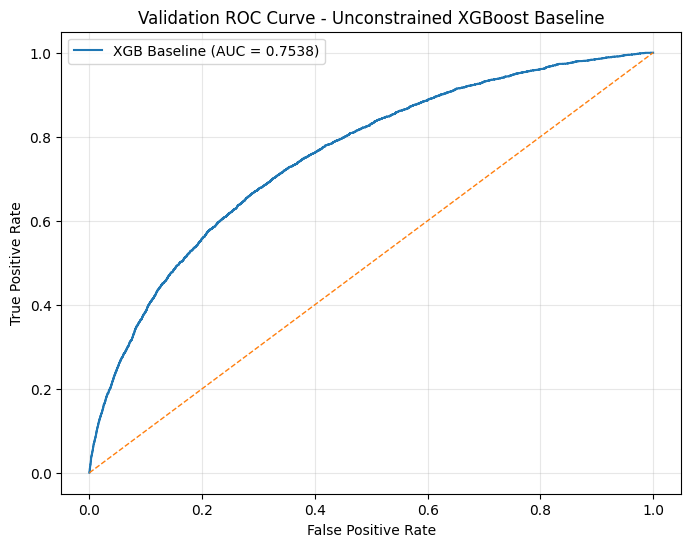

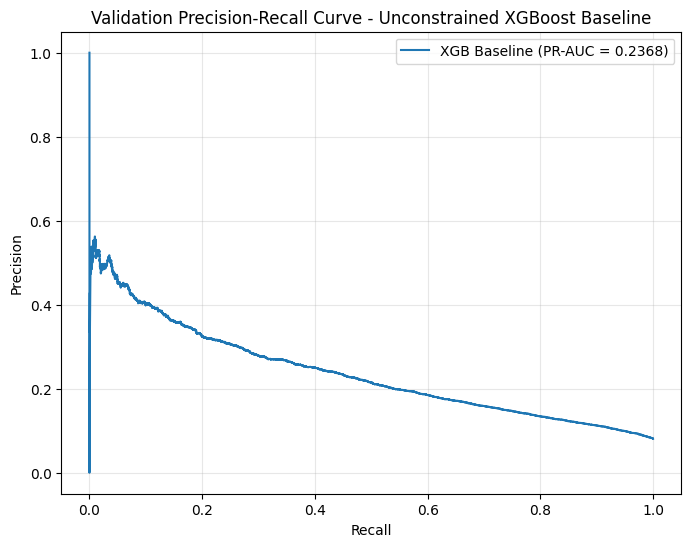

In [16]:
# Plot ROC and PR curves for the untuned baseline model on the validation set
plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation ROC Curve - Unconstrained XGBoost Baseline"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob)
    },
    title="Validation Precision-Recall Curve - Unconstrained XGBoost Baseline"
)

### 4.2. Optimizing Unconstrained XGB Hyperparameters

##### Two-stage tuning design

First, tune the main tree-complexity controls:

* max_depth
* min_child_weight

These parameters mainly control how flexible each tree can become.

Then, fix those values and tune the main boosting and regularization controls:

* learning_rate
* subsample
* colsample_bytree
* reg_lambda

This staged design separates tree complexity from the later boosting and regularization choices.

A broader search was considered, but not used here for two reasons:

* model selection is based on a single validation split, so a much larger search would increase the risk of overfitting to that split
* a narrower search is easier to explain and better matches the project goal of comparing constrained and unconstrained branches under a controlled tuning strategy

#### 4.2.1. Worker Function: Train & Evaluate Model Candidates with Different Hyperparameters (One-Hot)

In [17]:
def train_and_evaluate_xgb_candidate(candidate_params, candidate_name):
    """
    Helper func to train one unconstrained XGBoost candidate on the training split,
    use the validation split for early stopping,
    and return both the fitted model and its validation metrics.

    Returns fitted model instance and validation results dict

    """

    # Build candidate model with candidate-specific hyperparameter values
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification: predict probability of default
        eval_metric="aucpr",                     # PR-AUC is the early-stopping metric because defaults are rare
        n_estimators=1000,                       # Large cap on boosting rounds; early stopping will stop earlier if needed
        early_stopping_rounds=50,                # Stop if validation PR-AUC does not improve for 50 rounds
        tree_method="hist",                      # Efficient histogram-based tree construction
        device="cuda",                           # Train on GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        **candidate_params                       # Insert the hyperparameters being tested
    )

    # Fit on training data while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],         # Validation split used for early stopping
        verbose=False                            # Keep notebook output compact
    )

    # Evaluate candidate on validation using helper defined in eval section
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add metadata to help interpret search results.
    validation_result["best_iteration"] = fitted_model.best_iteration
    validation_result["best_score"] = fitted_model.best_score

    # Store each hyperparameter value in results row to complete results df
    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

#### 4.2.2. Worker Function: Train & Evaluate Model Candidates with Different Hyperparameters (Native)

In [ ]:

# Parallel helper for XGBoost native categorical support.
#
# This helper is intentionally separate from the one-hot helper so:
# - current pipeline remains intact
# - the experiment is easy to isolate and compare

def train_and_evaluate_xgb_native_candidate(candidate_params, candidate_name):
    """
    Train and evaluate one unconstrained XGBoost candidate using
    native categorical support.

    Parameters
    ----------
    candidate_params : dict
        XGBoost hyperparameters for this candidate.
    candidate_name : str
        Human-readable label for tracking results.

    Returns
    -------
    fitted_model : XGBClassifier
        Trained XGBoost model.
    validation_result : dict
        Validation metrics returned by the shared evaluation helper.
    """

    fitted_model = XGBClassifier(
        objective="binary:logistic",                 # Binary classification: predict probability of default
        eval_metric="aucpr",                         # PR-AUC for early stopping because defaults are the minority class
        n_estimators=1000,                           # Large cap so early stopping can choose effective tree count
        early_stopping_rounds=50,                    # Stop when validation PR-AUC stops improving
        tree_method="hist",                          # Required / supported for native categorical handling
        device="cuda",                               # Use GPU
        enable_categorical=True,                     # Tells XGBoost to use native categorical handling
        random_state=42,                             # Reproducibility
        **candidate_params
    )

    # Fit on the native categorical DataFrame inputs
    fitted_model.fit(
        X_train_native,
        y_train,
        eval_set=[(X_val_native, y_val)],
        verbose=False
    )

    # Evaluate on validation
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_native,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    return fitted_model, validation_result

#### 4.2.2. Stage 1: Tuning Tree Complexity

##### 4.2.2.1 Search Grid

In [ ]:

# Stage 1 unconstrained one-hot tuning
#
# Goal: tune structural tree complexity first by searching:
# - max_depth
# - min_child_weight
#
# All other knobs are held fixed during Stage 1.


unconstrained_stage_1_grid = {
    "learning_rate": [0.05],        # Hold fixed in Stage 1
    "max_depth": [3, 4, 5],         # Structural complexity search
    "min_child_weight": [3, 5, 7],  # Structural complexity search
    "subsample": [0.8],             # Hold fixed in Stage 1
    "colsample_bytree": [0.8],      # Hold fixed in Stage 1
    "reg_lambda": [1.0]             # Hold fixed in Stage 1
}

unconstrained_stage_1_param_names = list(unconstrained_stage_1_grid.keys())
unconstrained_stage_1_combinations = list(product(*unconstrained_stage_1_grid.values()))

print(f"Number of unconstrained Stage 1 candidates: {len(unconstrained_stage_1_combinations)}")

Number of unconstrained Stage 1 candidates: 9


##### 4.2.2.2. Tuning

In [20]:
# Run unconstrained Stage 1 tuning:
# - fit each candidate on the training split
# - evaluate each candidate on the validation split
# - rank candidates using validation metrics only

unconstrained_stage_1_results = []
unconstrained_stage_1_models = {}

for i, combo in enumerate(unconstrained_stage_1_combinations, start=1):
    candidate_params = dict(zip(unconstrained_stage_1_param_names, combo))
    candidate_name = f"xgb_unconstrained_stage1_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    unconstrained_stage_1_models[candidate_name] = fitted_model
    unconstrained_stage_1_results.append(validation_result)

unconstrained_stage_1_results_df = pd.DataFrame(unconstrained_stage_1_results)

unconstrained_stage_1_results_df = unconstrained_stage_1_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

unconstrained_stage_1_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_unconstrained_stage1_candidate_7,validation,0.754641,0.236853,0.068088,0.380920,546,0.236577,0.05,5,3,0.8,0.8,1.0
1,xgb_unconstrained_stage1_candidate_5,validation,0.753768,0.236797,0.068078,0.376673,830,0.236519,0.05,4,5,0.8,0.8,1.0
2,xgb_unconstrained_stage1_candidate_8,validation,0.754807,0.236664,0.068070,0.380312,452,0.236366,0.05,5,5,0.8,0.8,1.0
3,xgb_unconstrained_stage1_candidate_4,validation,0.752920,0.236491,0.068113,0.379537,819,0.236216,0.05,4,3,0.8,0.8,1.0
4,xgb_unconstrained_stage1_candidate_9,validation,0.754115,0.236288,0.068097,0.377278,542,0.236012,0.05,5,7,0.8,0.8,1.0
5,xgb_unconstrained_stage1_candidate_3,validation,0.753986,0.235777,0.068112,0.377815,999,0.235507,0.05,3,7,0.8,0.8,1.0
6,xgb_unconstrained_stage1_candidate_6,validation,0.753398,0.235723,0.068126,0.377230,826,0.235440,0.05,4,7,0.8,0.8,1.0
7,xgb_unconstrained_stage1_candidate_2,validation,0.753826,0.235205,0.068128,0.377341,999,0.234937,0.05,3,5,0.8,0.8,1.0
8,xgb_unconstrained_stage1_candidate_1,validation,0.753665,0.234678,0.068159,0.378082,999,0.234410,0.05,3,3,0.8,0.8,1.0


##### 4.2.2.3. Store Optimal Hyperparameters for Stage 1

In [21]:
# Select the best unconstrained Stage 1 candidate and carry its
# structural settings into Stage 2.

best_unconstrained_stage_1_name = unconstrained_stage_1_results_df.loc[0, "model_name"]

best_unconstrained_stage_1_params = {
    "max_depth": int(unconstrained_stage_1_results_df.loc[0, "max_depth"]),
    "min_child_weight": float(unconstrained_stage_1_results_df.loc[0, "min_child_weight"])
}

print("Best unconstrained Stage 1 candidate:")
print(best_unconstrained_stage_1_name)
print(best_unconstrained_stage_1_params)

Best unconstrained Stage 1 candidate:
xgb_unconstrained_stage1_candidate_7
{'max_depth': 5, 'min_child_weight': 3.0}


#### 4.2.3. Stage 2: Tuning for Regularization & Boosting Levels

##### 4.2.3.1. Search Grid

In [ ]:

# Stage 2 unconstrained one-hot tuning
#
# Goal:
# hold the best Stage 1 structure fixed and tune:
# - learning_rate
# - subsample
# - colsample_bytree
# - reg_lambda


unconstrained_stage_2_grid = {
    "learning_rate": [0.03, 0.05],
    "max_depth": [best_unconstrained_stage_1_params["max_depth"]],
    "min_child_weight": [best_unconstrained_stage_1_params["min_child_weight"]],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [0.5, 1.0]
}

unconstrained_stage_2_param_names = list(unconstrained_stage_2_grid.keys())
unconstrained_stage_2_combinations = list(product(*unconstrained_stage_2_grid.values()))

print(f"Number of unconstrained Stage 2 candidates: {len(unconstrained_stage_2_combinations)}")

Number of unconstrained Stage 2 candidates: 36


##### 4.2.3.2. Tuning

In [23]:
# Run unconstrained Stage 2 tuning using the same ranking rule.

unconstrained_stage_2_results = []
unconstrained_stage_2_models = {}

for i, combo in enumerate(unconstrained_stage_2_combinations, start=1):
    candidate_params = dict(zip(unconstrained_stage_2_param_names, combo))
    candidate_name = f"xgb_unconstrained_stage2_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    unconstrained_stage_2_models[candidate_name] = fitted_model
    unconstrained_stage_2_results.append(validation_result)

unconstrained_stage_2_results_df = pd.DataFrame(unconstrained_stage_2_results)

unconstrained_stage_2_results_df = unconstrained_stage_2_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

unconstrained_stage_2_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_unconstrained_stage2_candidate_1,validation,0.754314,0.237834,0.068060,0.379108,874,0.237538,0.03,5,3.0,0.7,0.7,0.5
1,xgb_unconstrained_stage2_candidate_11,validation,0.754540,0.237668,0.068028,0.378545,780,0.237403,0.03,5,3.0,0.8,0.9,0.5
2,xgb_unconstrained_stage2_candidate_6,validation,0.754992,0.237483,0.068033,0.378080,832,0.237211,0.03,5,3.0,0.7,0.9,1.0
3,xgb_unconstrained_stage2_candidate_18,validation,0.754304,0.237278,0.068044,0.378678,867,0.237003,0.03,5,3.0,0.9,0.9,1.0
4,xgb_unconstrained_stage2_candidate_24,validation,0.753717,0.237156,0.068070,0.375107,514,0.236878,0.05,5,3.0,0.7,0.9,1.0
5,xgb_unconstrained_stage2_candidate_4,validation,0.754270,0.236946,0.068071,0.378952,657,0.236647,0.03,5,3.0,0.7,0.8,1.0
6,xgb_unconstrained_stage2_candidate_30,validation,0.754588,0.236872,0.068062,0.380639,546,0.236593,0.05,5,3.0,0.8,0.9,1.0
7,xgb_unconstrained_stage2_candidate_28,validation,0.754641,0.236853,0.068088,0.380920,546,0.236577,0.05,5,3.0,0.8,0.8,1.0
8,xgb_unconstrained_stage2_candidate_16,validation,0.754313,0.236829,0.068061,0.378042,984,0.236546,0.03,5,3.0,0.9,0.8,1.0
9,xgb_unconstrained_stage2_candidate_5,validation,0.754484,0.236802,0.068073,0.380586,671,0.236532,0.03,5,3.0,0.7,0.9,0.5


#### 4.2.4. Store Top Model & Hyperparameters After Two-Tier Tuning

In [24]:
# Select best independently tuned unconstrained one-hot XGBoost model

best_unconstrained_name = unconstrained_stage_2_results_df.loc[0, "model_name"]
best_xgb_unconstrained = unconstrained_stage_2_models[best_unconstrained_name]

print("Selected tuned unconstrained XGBoost model:")
print(f"- Candidate name: {best_unconstrained_name}")
print(f"- Validation PR-AUC: {unconstrained_stage_2_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {unconstrained_stage_2_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {unconstrained_stage_2_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {unconstrained_stage_2_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_unconstrained.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_unconstrained.best_score}")

Selected tuned unconstrained XGBoost model:
- Candidate name: xgb_unconstrained_stage2_candidate_1
- Validation PR-AUC: 0.237834
- Validation ROC-AUC: 0.754314
- Validation KS: 0.379108
- Validation Brier: 0.068060
- Best boosting iteration: 874
- Best XGBoost validation score: 0.23753772002445506


#### 4.2.5 Save Hyperparameter Tuning Results for XGB Unconstrained

In [25]:
# Save unconstrained one-hot tuning outputs
unconstrained_stage_1_results_df.to_csv(UNCONSTRAINED_STAGE_1_RESULTS_CSV, index=False)
unconstrained_stage_2_results_df.to_csv(UNCONSTRAINED_STAGE_2_RESULTS_CSV, index=False)
unconstrained_stage_2_results_df.head(1).to_csv(UNCONSTRAINED_SELECTED_MODEL_CSV, index=False)

print(f"Saved: {UNCONSTRAINED_STAGE_1_RESULTS_CSV}")
print(f"Saved: {UNCONSTRAINED_STAGE_2_RESULTS_CSV}")
print(f"Saved: {UNCONSTRAINED_SELECTED_MODEL_CSV}")

Saved: ../output/xgboost/unconstrained/xgb_unconstrained_stage1_tuning_results_validation.csv
Saved: ../output/xgboost/unconstrained/xgb_unconstrained_stage2_tuning_results_validation.csv
Saved: ../output/xgboost/unconstrained/xgb_unconstrained_tuned_selected_model_validation.csv


#### 4.2.6. Compare Tuned Unconstrained XGB Against Untuned, Unconstrained Baseline

In [26]:
# Evaluate tuned unconstrained model on validation for comparison against  original unconstrained baseline
tuned_val_result = evaluate_binary_model(
    model=best_xgb_unconstrained,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_unconstrained_tuned"
)

# Store validation predicted probabilities for comparison plots
tuned_val_prob = best_xgb_unconstrained.predict_proba(X_val_ready)[:, 1]

# Build a validation-only comparison table
validation_compare_df = pd.DataFrame([
    baseline_val_result,
    tuned_val_result
])

validation_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_unconstrained_baseline,validation,0.753768,0.236797,0.068078,0.376673,830
1,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.068060,0.379108,874


#### 4.2.7. Save Baseline Comparison Results

In [27]:
# Save the validation comparison between:
# - original unconstrained baseline
# - tuned unconstrained XGBoost
validation_compare_df.to_csv(VALIDATION_COMPARE_CSV, index=False)
print(f"Saved: {VALIDATION_COMPARE_CSV}")

Saved: ../output/xgboost/unconstrained/xgb_unconstrained_validation_comparison.csv


#### 4.2.8. Interpretation

##### Results After Hyperparameter Tuning

The two-stage hyperparameter search produced a modest but consistent improvement over the original unconstrained baseline on the validation split.

Compared with the baseline, the selected tuned model improved:
- ROC-AUC from **0.753768** to **0.754188**
- PR-AUC from **0.236797** to **0.237661**
- KS statistic from **0.376673** to **0.378648**
- Brier score from **0.068078** to **0.068052** (lower is better)

The improvement is small, but it is directionally consistent across all four metrics. This suggests that the tuning stage successfully identified a slightly better unconstrained benchmark without materially changing the qualitative behavior of the model.

We lock this tuned unconstrained XGBoost specification as the benchmark to be compared next against the constrained XGBoost model.



#### 4.2.9. Plots: Unconstrained XGB Tuned vs Untuned

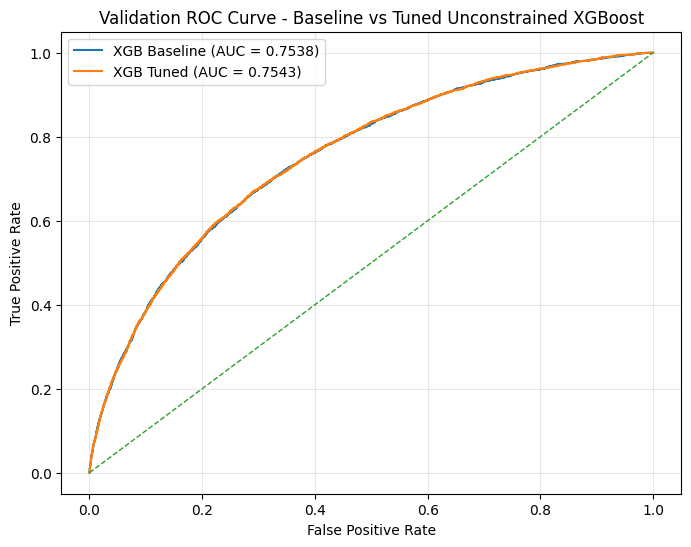

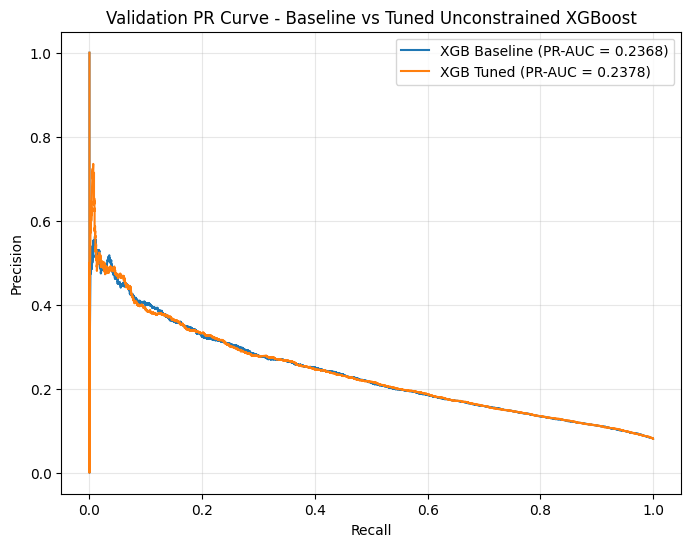

In [28]:

# Validation comparison plots: ROC & PR for baseline vs tuned unconstrained XGBoost

plot_roc_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation ROC Curve - Baseline vs Tuned Unconstrained XGBoost"
)

plot_pr_curves(
    curves_dict={
        "XGB Baseline": (y_val, baseline_val_prob),
        "XGB Tuned": (y_val, tuned_val_prob)
    },
    title="Validation PR Curve - Baseline vs Tuned Unconstrained XGBoost"
)

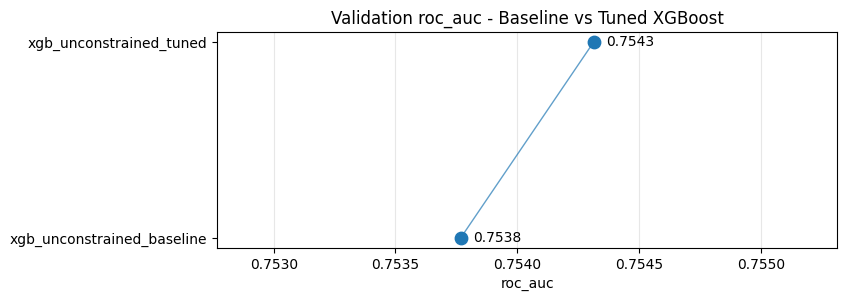

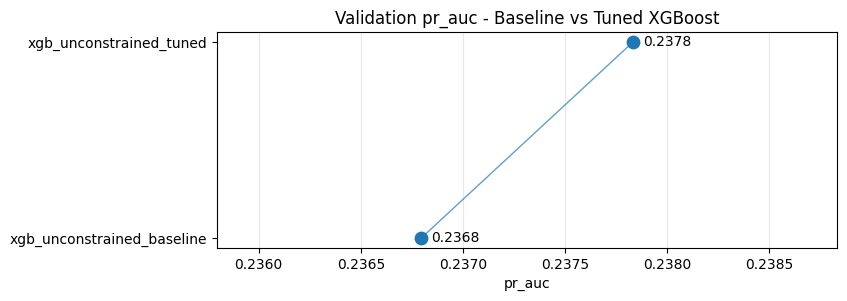

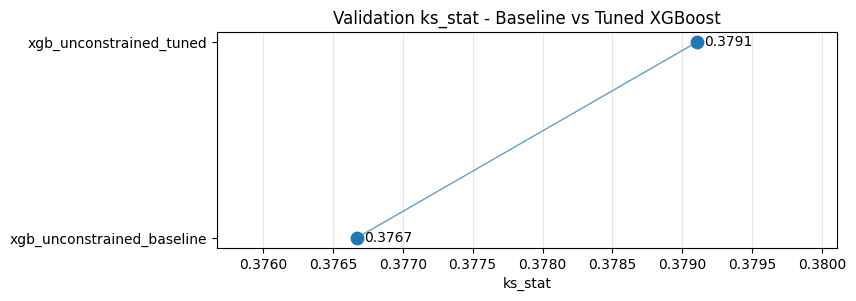

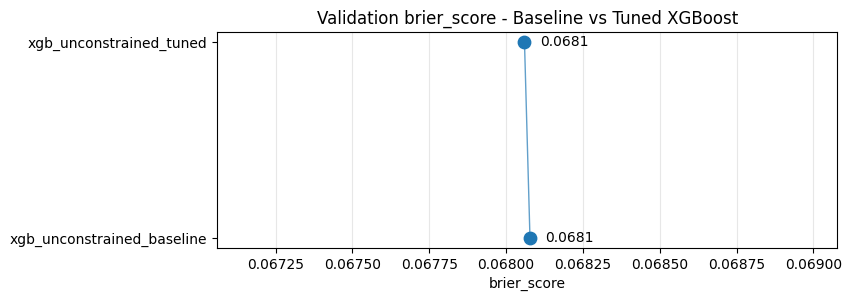

In [29]:

# Plot validation metric comparisons: baseline vs tuned unconstrained XGBoost

metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=validation_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Baseline vs Tuned XGBoost",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

### 4.3. Native-Categorical Branch: Baseline and Tuning

This section evaluates native categorical encoding as an alternative representation for unconstrained XGBoost.

The one-hot branch has already been optimized through:
- independent two-tier tuning
- imbalance-adjustment model selection

So the purpose of this section is to determine whether a separately tuned native-categorical unconstrained XGBoost model can outperform the selected final one-hot unconstrained benchmark.

In [ ]:

# Baseline native-categorical XGBoost
# mirrors the baseline unconstrained model, but uses:
# - DataFrame inputs with categorical dtypes
# - enable_categorical=True

xgb_native_baseline = XGBClassifier(
    objective="binary:logistic",        # Binary default prediction
    eval_metric="aucpr",                # PR-AUC for early stopping under class imbalance
    n_estimators=1000,                  # Upper bound on boosting rounds
    early_stopping_rounds=50,           # Stop when validation PR-AUC no longer improves
    learning_rate=0.05,                 # Same as  baseline
    max_depth=4,                        # Same as baseline tree depth
    min_child_weight=5,                 # Regularization smae as baseline
    subsample=0.8,                      # Row sampling per tree
    colsample_bytree=0.8,               # Column sampling per tree
    reg_lambda=1.0,                     # L2 regularization
    tree_method="hist",                 # Native categorical support works with hist / approx
    device="cuda",                      # Use GPU
    enable_categorical=True,            # Native categorical handling ON
    random_state=42
)

xgb_native_baseline.fit(
    X_train_native,
    y_train,
    eval_set=[(X_val_native, y_val)],
    verbose=False
)

native_baseline_val_result = evaluate_binary_model(
    model=xgb_native_baseline,
    X=X_val_native,
    y=y_val,
    split_name="validation",
    model_name="xgb_native_categorical_baseline"
)

native_baseline_val_result_df = pd.DataFrame([native_baseline_val_result])
native_baseline_val_result_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_native_categorical_baseline,validation,0.751745,0.234478,0.068207,0.374652,621


In [31]:
print(f"Native categorical baseline best iteration: {xgb_native_baseline.best_iteration}")
print(f"Native categorical baseline best score: {xgb_native_baseline.best_score}")

Native categorical baseline best iteration: 621
Native categorical baseline best score: 0.23420125301376457


#### 4.3.1. Apples-to-Apples Representation Check and Native Optimization

In [ ]:

# Apples-to-apples native-categorical experiment
#
# Goal:
# test whether native categorical handling helps when we keep the
# hyperparameters exactly the same as the current tuned one-hot winner.
#
# This isolates the representation change first before any re-tuning.


native_same_params = {
    "learning_rate": float(unconstrained_stage_2_results_df.loc[0, "learning_rate"]),           # Best tuned one-hot learning rate from Stage 2 search
    "max_depth": int(unconstrained_stage_2_results_df.loc[0, "max_depth"]),                     # Best tuned one-hot tree depth from Stage 2 search
    "min_child_weight": float(unconstrained_stage_2_results_df.loc[0, "min_child_weight"]),     # Best tuned one-hot min_child_weight from Stage 2 search
    "subsample": float(unconstrained_stage_2_results_df.loc[0, "subsample"]),                   # Best tuned one-hot row sampling from Stage 2 search
    "colsample_bytree": float(unconstrained_stage_2_results_df.loc[0, "colsample_bytree"]),     # Best tuned one-hot column sampling from Stage 2 search
    "reg_lambda": float(unconstrained_stage_2_results_df.loc[0, "reg_lambda"])                  # Best tuned one-hot L2 regularization from Stage 2 search
}

xgb_native_same_params, native_same_params_val_result = train_and_evaluate_xgb_native_candidate(
    candidate_params=native_same_params,
    candidate_name="xgb_native_same_tuned_params"
)

native_same_params_val_result_df = pd.DataFrame([native_same_params_val_result])
native_same_params_val_result_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration
0,xgb_native_same_tuned_params,validation,0.752706,0.234291,0.068189,0.374094,558


In [33]:
print("Native categorical model with same tuned one-hot hyperparameters:")
print(f"- Validation PR-AUC: {native_same_params_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {native_same_params_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {native_same_params_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {native_same_params_val_result['brier_score']:.6f}")
print(f"- Best iteration: {xgb_native_same_params.best_iteration}")
print(f"- Best score: {xgb_native_same_params.best_score}")

Native categorical model with same tuned one-hot hyperparameters:
- Validation PR-AUC: 0.234291
- Validation ROC-AUC: 0.752706
- Validation KS: 0.374094
- Validation Brier: 0.068189
- Best iteration: 558
- Best score: 0.23401470548344094


#### 4.3.2. Tier 1 Tuning: Structural Complexity

In [ ]:

# Tier 1 native-categorical tuning
#
# Goal:
# search structural tree complexity first by tuning:
# - max_depth
# - min_child_weight
#
# All other knobs are held fixed at the tuned one-hot values so the
# tuning procedure matches the main unconstrained XGBoost workflow.


native_tier1_candidates = []

for max_depth_value in [3, 4, 5]:
    for min_child_weight_value in [3, 5, 7]:
        native_tier1_candidates.append({
            "learning_rate": float(unconstrained_stage_2_results_df.loc[0, "learning_rate"]),       # Hold fixed for Tier 1 using tuned one-hot Stage 2 winner
            "max_depth": int(max_depth_value),                                                        # Tier 1 structural knob
            "min_child_weight": float(min_child_weight_value),                                        # Tier 1 structural knob
            "subsample": float(unconstrained_stage_2_results_df.loc[0, "subsample"]),               # Hold fixed for Tier 1 using tuned one-hot Stage 2 winner
            "colsample_bytree": float(unconstrained_stage_2_results_df.loc[0, "colsample_bytree"]), # Hold fixed for Tier 1 using tuned one-hot Stage 2 winner
            "reg_lambda": float(unconstrained_stage_2_results_df.loc[0, "reg_lambda"])              # Hold fixed for Tier 1 using tuned one-hot Stage 2 winner
        })

native_tier1_results = []
native_tier1_models = {}

for i, candidate_params in enumerate(native_tier1_candidates, start=1):
    candidate_name = f"xgb_native_tier1_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_xgb_native_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    native_tier1_models[candidate_name] = fitted_model
    validation_result.update(candidate_params)
    native_tier1_results.append(validation_result)

native_tier1_results_df = pd.DataFrame(native_tier1_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

native_tier1_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_native_tier1_candidate_9,validation,0.752638,0.234495,0.068186,0.376581,617,0.03,5,7.0,0.7,0.7,0.5
1,xgb_native_tier1_candidate_7,validation,0.752706,0.234291,0.068189,0.374094,558,0.03,5,3.0,0.7,0.7,0.5
2,xgb_native_tier1_candidate_8,validation,0.753032,0.233819,0.068192,0.374577,550,0.03,5,5.0,0.7,0.7,0.5
3,xgb_native_tier1_candidate_6,validation,0.753091,0.233784,0.068193,0.377224,617,0.03,4,7.0,0.7,0.7,0.5
4,xgb_native_tier1_candidate_5,validation,0.752946,0.233541,0.068202,0.377219,648,0.03,4,5.0,0.7,0.7,0.5
5,xgb_native_tier1_candidate_4,validation,0.752701,0.232848,0.068234,0.376331,645,0.03,4,3.0,0.7,0.7,0.5
6,xgb_native_tier1_candidate_1,validation,0.752470,0.232650,0.068240,0.373744,983,0.03,3,3.0,0.7,0.7,0.5
7,xgb_native_tier1_candidate_3,validation,0.752459,0.232567,0.068246,0.375016,988,0.03,3,7.0,0.7,0.7,0.5
8,xgb_native_tier1_candidate_2,validation,0.752434,0.232344,0.068254,0.374769,958,0.03,3,5.0,0.7,0.7,0.5


In [35]:
# Pull the best Tier 1 structural settings
best_native_tier1_row = native_tier1_results_df.loc[0].to_dict()

best_native_tier1_max_depth = int(best_native_tier1_row["max_depth"])
best_native_tier1_min_child_weight = float(best_native_tier1_row["min_child_weight"])

print("Best native Tier 1 structure:")
print(f"- max_depth: {best_native_tier1_max_depth}")
print(f"- min_child_weight: {best_native_tier1_min_child_weight}")
print(f"- Validation PR-AUC: {best_native_tier1_row['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {best_native_tier1_row['roc_auc']:.6f}")
print(f"- Validation KS: {best_native_tier1_row['ks_stat']:.6f}")
print(f"- Validation Brier: {best_native_tier1_row['brier_score']:.6f}")

Best native Tier 1 structure:
- max_depth: 5
- min_child_weight: 7.0
- Validation PR-AUC: 0.234495
- Validation ROC-AUC: 0.752638
- Validation KS: 0.376581
- Validation Brier: 0.068186


#### 4.3.3. Tier 2 Tuning: Boosting and Regularization

In [ ]:

# Tier 2 native-categorical tuning
#
# Goal:
# hold the best Tier 1 structure fixed and search:
# - learning_rate
# - subsample
# - colsample_bytree
# - reg_lambda
#
# This mirrors the second tuning stage used in the main unconstrained
# XGBoost workflow.


native_tier2_candidates = []

for learning_rate_value in [0.03, 0.05]:
    for subsample_value in [0.7, 0.8, 0.9]:
        for colsample_value in [0.7, 0.8, 0.9]:
            for reg_lambda_value in [0.5, 1.0]:
                native_tier2_candidates.append({
                    "learning_rate": float(learning_rate_value),                    # Tier 2 learning-rate search
                    "max_depth": best_native_tier1_max_depth,                       # Best Tier 1 depth
                    "min_child_weight": best_native_tier1_min_child_weight,         # Best Tier 1 min_child_weight
                    "subsample": float(subsample_value),                            # Tier 2 row sampling
                    "colsample_bytree": float(colsample_value),                     # Tier 2 column sampling
                    "reg_lambda": float(reg_lambda_value)                           # Tier 2 L2 regularization
                })

native_tier2_results = []
native_tier2_models = {}

for i, candidate_params in enumerate(native_tier2_candidates, start=1):
    candidate_name = f"xgb_native_tier2_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_xgb_native_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    native_tier2_models[candidate_name] = fitted_model
    validation_result.update(candidate_params)
    native_tier2_results.append(validation_result)

native_tier2_results_df = pd.DataFrame(native_tier2_results).sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

native_tier2_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_native_tier2_candidate_9,validation,0.753681,0.236253,0.068114,0.377201,751,0.03,5,7.0,0.8,0.8,0.5
1,xgb_native_tier2_candidate_10,validation,0.753640,0.235433,0.068145,0.378143,633,0.03,5,7.0,0.8,0.8,1.0
2,xgb_native_tier2_candidate_5,validation,0.752675,0.235364,0.068162,0.376541,621,0.03,5,7.0,0.7,0.9,0.5
3,xgb_native_tier2_candidate_19,validation,0.753366,0.235169,0.068158,0.379918,453,0.05,5,7.0,0.7,0.7,0.5
4,xgb_native_tier2_candidate_20,validation,0.753700,0.235086,0.068159,0.380148,367,0.05,5,7.0,0.7,0.7,1.0
5,xgb_native_tier2_candidate_4,validation,0.752725,0.235026,0.068171,0.373389,693,0.03,5,7.0,0.7,0.8,1.0
6,xgb_native_tier2_candidate_18,validation,0.752768,0.234932,0.068170,0.374358,780,0.03,5,7.0,0.9,0.9,1.0
7,xgb_native_tier2_candidate_8,validation,0.752901,0.234913,0.068184,0.377585,625,0.03,5,7.0,0.8,0.7,1.0
8,xgb_native_tier2_candidate_2,validation,0.753319,0.234844,0.068166,0.376739,626,0.03,5,7.0,0.7,0.7,1.0
9,xgb_native_tier2_candidate_12,validation,0.753126,0.234778,0.068184,0.377615,690,0.03,5,7.0,0.8,0.9,1.0


In [37]:
# Best tuned native-categorical model from Tier 2
best_native_tuned_name = native_tier2_results_df.loc[0, "model_name"]
best_xgb_native_tuned = native_tier2_models[best_native_tuned_name]
best_native_tuned_val_result = native_tier2_results_df.loc[0].to_dict()

print("Best tuned native-categorical XGBoost:")
print(f"- Model name: {best_native_tuned_name}")
print(f"- Validation PR-AUC: {best_native_tuned_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {best_native_tuned_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {best_native_tuned_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {best_native_tuned_val_result['brier_score']:.6f}")
print(f"- Best iteration: {best_xgb_native_tuned.best_iteration}")
print(f"- Best score: {best_xgb_native_tuned.best_score}")

Best tuned native-categorical XGBoost:
- Model name: xgb_native_tier2_candidate_9
- Validation PR-AUC: 0.236253
- Validation ROC-AUC: 0.753681
- Validation KS: 0.377201
- Validation Brier: 0.068114
- Best iteration: 751
- Best score: 0.2359761645050677


In [ ]:

# Three-way validation comparison
#
# Compare:
# 1) tuned one-hot unconstrained XGBoost
# 2) native categorical with same tuned one-hot hyperparameters
# 3) best tuned native-categorical XGBoost


native_three_way_compare_df = pd.DataFrame([
    tuned_val_result,                 # Existing best one-hot unconstrained validation result
    native_same_params_val_result,    # Native categorical with same tuned one-hot parameters
    best_native_tuned_val_result      # Best tuned native-categorical result
])

native_three_way_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.068060,0.379108,874,NaN,NaN,NaN,NaN,NaN,NaN
1,xgb_native_same_tuned_params,validation,0.752706,0.234291,0.068189,0.374094,558,NaN,NaN,NaN,NaN,NaN,NaN
2,xgb_native_tier2_candidate_9,validation,0.753681,0.236253,0.068114,0.377201,751,0.03,5.0,7.0,0.8,0.8,0.5


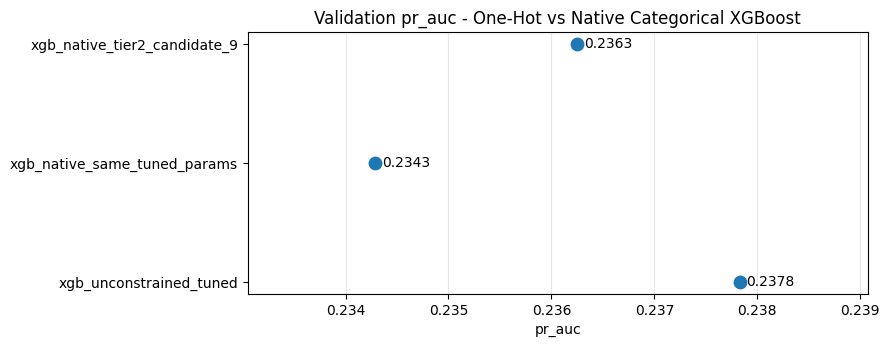

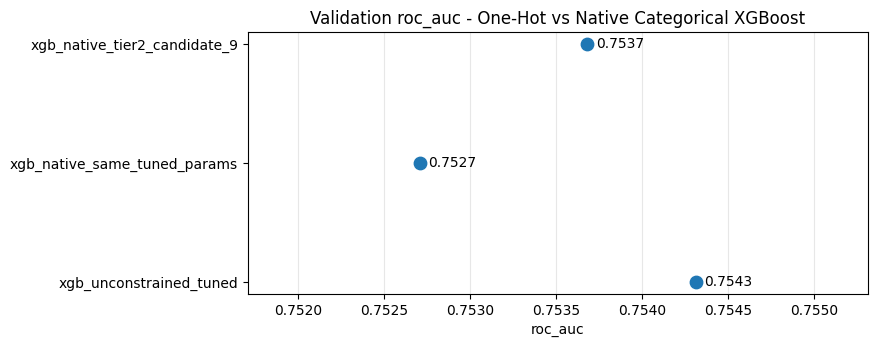

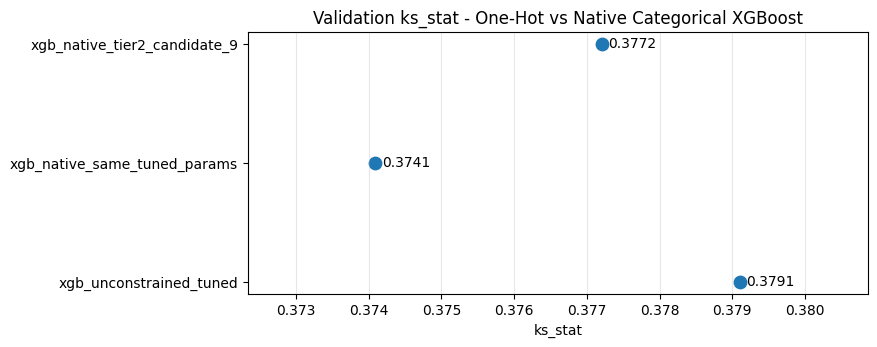

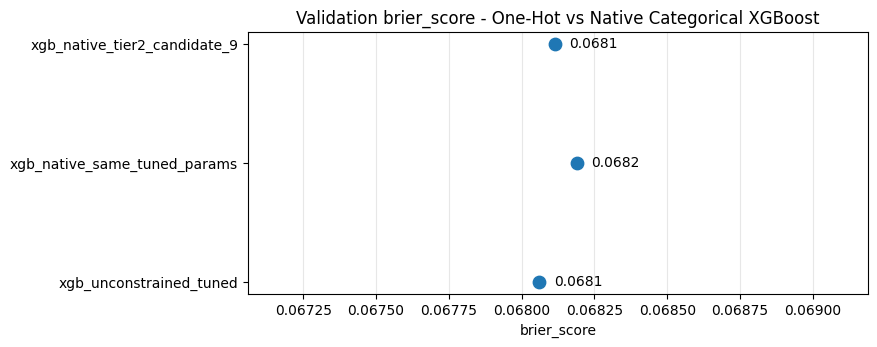

In [39]:
# Plot the main validation metrics side by side
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plot_df = native_three_way_compare_df[["model_name", metric]].copy()

    values = plot_df[metric].astype(float).to_numpy()
    labels = plot_df["model_name"].tolist()
    y_pos = np.arange(len(plot_df))

    x_min = values.min()
    x_max = values.max()
    x_span = x_max - x_min
    padding = max(x_span * 0.35, 0.001)

    plt.figure(figsize=(8, 3.4))
    plt.scatter(values, y_pos, s=80)

    for x, y in zip(values, y_pos):
        plt.text(x + padding * 0.05, y, f"{x:.4f}", va="center")

    plt.yticks(y_pos, labels)
    plt.xlim(x_min - padding, x_max + padding)
    plt.xlabel(metric)
    plt.title(f"Validation {metric} - One-Hot vs Native Categorical XGBoost")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

In [40]:
# Save native-categorical experiment outputs

native_tier1_results_df.to_csv(NATIVE_TIER1_RESULTS_CSV, index=False)
native_tier2_results_df.to_csv(NATIVE_TIER2_RESULTS_CSV, index=False)
native_three_way_compare_df.to_csv(NATIVE_THREE_WAY_COMPARE_CSV, index=False)

print(f"Saved: {NATIVE_TIER1_RESULTS_CSV}")
print(f"Saved: {NATIVE_TIER2_RESULTS_CSV}")
print(f"Saved: {NATIVE_THREE_WAY_COMPARE_CSV}")

Saved: ../output/xgboost/native/xgb_native_categorical_tier1_validation_results.csv
Saved: ../output/xgboost/native/xgb_native_categorical_tier2_validation_results.csv
Saved: ../output/xgboost/native/xgb_native_categorical_three_way_validation_comparison.csv


### 4.4. One-Hot Branch Imbalance Optimization: scale_pos_weight

Defaults are the minority class in this dataset.

This experiment keeps the tuned unconstrained XGBoost structure fixed and tests whether extra weight on default observations improves validation performance.

This may improve ranking metrics such as PR-AUC, ROC-AUC, and KS, but it can also worsen probability calibration, so Brier score is checked alongside the ranking metrics.

In [41]:
# Helper: compute class imbalance ratio on the training split only.
#
# This gives us a sensible starting point for scale_pos_weight:
# number of majority-class rows divided by number of minority-class rows.
#
# For this project:
# - negative class = non-default = TARGET 0
# - positive class = default     = TARGET 1

n_negative_train = (y_train == 0).sum()   # Count non-default borrowers in train
n_positive_train = (y_train == 1).sum()   # Count defaulting borrowers in train

recommended_scale_pos_weight = n_negative_train / n_positive_train

print(f"Training non-default count: {n_negative_train}")
print(f"Training default count: {n_positive_train}")
print(f"Recommended scale_pos_weight starting point: {recommended_scale_pos_weight:.4f}")

Training non-default count: 197769
Training default count: 17368
Recommended scale_pos_weight starting point: 11.3870


In [42]:

# Helper:
# train one unconstrained XGBoost candidate with a chosen
# scale_pos_weight value, then evaluate on validation.
#
# We keep the rest of the hyperparameters fixed at the currently
# selected tuned unconstrained configuration so this experiment
# isolates the effect of class weighting.

def train_and_evaluate_scale_pos_weight_candidate(scale_pos_weight_value, candidate_name):
    """
    Train one unconstrained XGBoost candidate using a specific
    scale_pos_weight value and evaluate it on the validation split.

    Parameters
    ----------
    scale_pos_weight_value : float
        Weight applied to positive-class (default) rows during training.
    candidate_name : str
        Human-readable label for tracking this candidate.

    Returns
    -------
    fitted_model : XGBClassifier
        Trained XGBoost model.
    validation_result : dict
        Validation metrics plus metadata.
    """

    # Build model:
    # - keep the best tuned unconstrained hyperparameters fixed
    # - change only scale_pos_weight
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification: predict default probability
        eval_metric="aucpr",                     # Use PR-AUC for early stopping because defaults are rare
        n_estimators=1000,                       # Large upper bound on boosting rounds
        early_stopping_rounds=50,                # Stop when validation PR-AUC stops improving
        learning_rate=float(unconstrained_stage_2_results_df.loc[0, "learning_rate"]),           # Best tuned value from Stage 2 one-hot search
        max_depth=int(unconstrained_stage_2_results_df.loc[0, "max_depth"]),                     # Best tuned value from Stage 2 one-hot search
        min_child_weight=float(unconstrained_stage_2_results_df.loc[0, "min_child_weight"]),     # Best tuned value from Stage 2 one-hot search
        subsample=float(unconstrained_stage_2_results_df.loc[0, "subsample"]),                   # Best tuned value from Stage 2 one-hot search
        colsample_bytree=float(unconstrained_stage_2_results_df.loc[0, "colsample_bytree"]),     # Best tuned value from Stage 2 one-hot search
        reg_lambda=float(unconstrained_stage_2_results_df.loc[0, "reg_lambda"]),                 # Best tuned value from Stage 2 one-hot search
        scale_pos_weight=float(scale_pos_weight_value),                           # Upweight default rows during training
        tree_method="hist",                      # Efficient tree construction for large tabular data
        device="cuda",                           # Use GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1                                # Use available CPU threads where relevant
    )

    # Fit model while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],
        verbose=False
    )

    # Evaluate on validation
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add experiment metadata to the result row
    validation_result["scale_pos_weight"] = float(scale_pos_weight_value)
    validation_result["max_delta_step"] = 0

    return fitted_model, validation_result

In [43]:

# Interpretable scale_pos_weight grid:
# - 1.0 as the "no class weighting" baseline
# - a few moderate values
# - the imbalance-ratio anchor
# - a somewhat larger value to see if stronger reweighting helps


scale_pos_weight_grid = [
    1.0,                                        # No extra class weighting
    3.0,                                        # Mild upweighting of defaults
    5.0,                                        # Moderate upweighting
    8.0,                                        # Stronger upweighting
    round(recommended_scale_pos_weight, 2),     # Ratio-based starting point from training split
    14.0                                        # Slightly above the ratio anchor
]

# Remove duplicates while preserving order
seen = set()
scale_pos_weight_grid = [
    x for x in scale_pos_weight_grid
    if not (x in seen or seen.add(x))
]

print("scale_pos_weight values to test:")
print(scale_pos_weight_grid)

scale_pos_weight values to test:
[1.0, 3.0, 5.0, 8.0, np.float64(11.39), 14.0]


In [44]:

# Train and evaluate each scale_pos_weight candidate on validation.

scale_pos_weight_results = []
scale_pos_weight_models = {}

for i, weight_value in enumerate(scale_pos_weight_grid, start=1):
    candidate_name = f"xgb_scale_pos_weight_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_scale_pos_weight_candidate(
        scale_pos_weight_value=weight_value,
        candidate_name=candidate_name
    )

    # Store fitted model for possible later use
    scale_pos_weight_models[candidate_name] = fitted_model

    # Store validation metrics and metadata
    scale_pos_weight_results.append(validation_result)

# Convert to DataFrame
scale_pos_weight_results_df = pd.DataFrame(scale_pos_weight_results)

# Rank candidates:
# 1. PR-AUC
# 2. ROC-AUC
# 3. KS
# 4. Brier Score (lower is better)
scale_pos_weight_results_df = scale_pos_weight_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

scale_pos_weight_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_scale_pos_weight_candidate_1,validation,0.754314,0.237834,0.068060,0.379108,874,1.00,0
1,xgb_scale_pos_weight_candidate_2,validation,0.753863,0.237384,0.083079,0.378454,854,3.00,0
2,xgb_scale_pos_weight_candidate_3,validation,0.753898,0.237094,0.107997,0.379465,877,5.00,0
3,xgb_scale_pos_weight_candidate_4,validation,0.753596,0.236288,0.148321,0.379473,675,8.00,0
4,xgb_scale_pos_weight_candidate_6,validation,0.752500,0.235887,0.214224,0.378449,859,14.00,0
5,xgb_scale_pos_weight_candidate_5,validation,0.752943,0.234974,0.190211,0.377519,607,11.39,0


In [45]:

# Compare the best scale_pos_weight candidate against the current
# tuned unconstrained benchmark.


best_scale_pos_weight_name = scale_pos_weight_results_df.loc[0, "model_name"]
best_xgb_scale_pos_weight = scale_pos_weight_models[best_scale_pos_weight_name]

print("Best scale_pos_weight candidate:")
print(f"- Candidate name: {best_scale_pos_weight_name}")
print(f"- scale_pos_weight: {scale_pos_weight_results_df.loc[0, 'scale_pos_weight']}")
print(f"- Validation PR-AUC: {scale_pos_weight_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {scale_pos_weight_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {scale_pos_weight_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {scale_pos_weight_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_scale_pos_weight.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_scale_pos_weight.best_score}")

# Pull the current tuned unconstrained benchmark row
baseline_reference_row = tuned_val_result.copy()
baseline_reference_row["scale_pos_weight"] = 1.0
baseline_reference_row["max_delta_step"] = 0

# Build a compact comparison table
scale_pos_weight_compare_df = pd.DataFrame([
    baseline_reference_row,
    scale_pos_weight_results_df.loc[0].to_dict()
])

scale_pos_weight_compare_df

Best scale_pos_weight candidate:
- Candidate name: xgb_scale_pos_weight_candidate_1
- scale_pos_weight: 1.0
- Validation PR-AUC: 0.237834
- Validation ROC-AUC: 0.754314
- Validation KS: 0.379108
- Validation Brier: 0.068060
- Best boosting iteration: 874
- Best XGBoost validation score: 0.23753772002445506


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.06806,0.379108,874,1.0,0
1,xgb_scale_pos_weight_candidate_1,validation,0.754314,0.237834,0.06806,0.379108,874,1.0,0


In [46]:
# Save scale_pos_weight experiment outputs

scale_pos_weight_results_df.to_csv(SCALE_POS_WEIGHT_RESULTS_CSV, index=False)
scale_pos_weight_compare_df.to_csv(SCALE_POS_WEIGHT_COMPARE_CSV, index=False)

print(f"Saved: {SCALE_POS_WEIGHT_RESULTS_CSV}")
print(f"Saved: {SCALE_POS_WEIGHT_COMPARE_CSV}")

Saved: ../output/xgboost/unconstrained/xgb_scale_pos_weight_validation_results.csv
Saved: ../output/xgboost/unconstrained/xgb_scale_pos_weight_best_vs_tuned_unconstrained.csv


### 4.5. One-Hot Branch Imbalance Optimization: max_delta_step

This experiment leaves class weights unchanged and instead tests max_delta_step as a more conservative imbalance adjustment.

The goal is to stabilize boosting updates under class imbalance without changing class weights directly. This may preserve probability quality better than scale_pos_weight, so Brier score is again checked alongside the ranking metrics.

In [47]:

# Helper:
# train one unconstrained XGBoost candidate with a chosen
# max_delta_step value, then evaluate on validation.
#
# We keep the rest of the hyperparameters fixed at the currently
# selected tuned unconstrained configuration so this experiment
# isolates the effect of max_delta_step.

def train_and_evaluate_max_delta_step_candidate(max_delta_step_value, candidate_name):
    """
    Train one unconstrained XGBoost candidate using a specific
    max_delta_step value and evaluate it on the validation split.

    Parameters
    ----------
    max_delta_step_value : float
        Maximum delta step for leaf weight updates.
    candidate_name : str
        Human-readable label for tracking this candidate.

    Returns
    -------
    fitted_model : XGBClassifier
        Trained XGBoost model.
    validation_result : dict
        Validation metrics plus metadata.
    """

    # Build model:
    # - keep the best tuned unconstrained hyperparameters fixed
    # - change only max_delta_step
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification: predict default probability
        eval_metric="aucpr",                     # Use PR-AUC for early stopping because defaults are rare
        n_estimators=1000,                       # Large upper bound on boosting rounds
        early_stopping_rounds=50,                # Stop when validation PR-AUC stops improving
        learning_rate=float(unconstrained_stage_2_results_df.loc[0, "learning_rate"]),           # Best tuned value from Stage 2 one-hot search
        max_depth=int(unconstrained_stage_2_results_df.loc[0, "max_depth"]),                     # Best tuned value from Stage 2 one-hot search
        min_child_weight=float(unconstrained_stage_2_results_df.loc[0, "min_child_weight"]),     # Best tuned value from Stage 2 one-hot search
        subsample=float(unconstrained_stage_2_results_df.loc[0, "subsample"]),                   # Best tuned value from Stage 2 one-hot search
        colsample_bytree=float(unconstrained_stage_2_results_df.loc[0, "colsample_bytree"]),     # Best tuned value from Stage 2 one-hot search
        reg_lambda=float(unconstrained_stage_2_results_df.loc[0, "reg_lambda"]),                 # Best tuned value from Stage 2 one-hot search
        scale_pos_weight=1.0,                                                     # Keep class weighting neutral in this experiment
        max_delta_step=float(max_delta_step_value),                               # Stabilize leaf-weight updates under imbalance
        tree_method="hist",                      # Efficient tree construction for large tabular data
        device="cuda",                           # Use GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1                                # Use available CPU threads where relevant
    )

    # Fit model while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],
        verbose=False
    )

    # Evaluate on validation set
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add experiment metadata to the result row
    validation_result["scale_pos_weight"] = 1.0
    validation_result["max_delta_step"] = float(max_delta_step_value)

    return fitted_model, validation_result

In [48]:

# Try a small max_delta_step grid.
#
# We include:
# - 0 as the current baseline behavior
# - 1 as the main value we want to test
# - 2 as a slightly stronger version just for context

max_delta_step_grid = [0, 1, 2]

print("max_delta_step values to test:")
print(max_delta_step_grid)

max_delta_step values to test:
[0, 1, 2]


In [49]:

# Train and evaluate each max_delta_step candidate on validation.

max_delta_step_results = []
max_delta_step_models = {}

for i, delta_value in enumerate(max_delta_step_grid, start=1):
    candidate_name = f"xgb_max_delta_step_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_max_delta_step_candidate(
        max_delta_step_value=delta_value,
        candidate_name=candidate_name
    )

    # Store fitted model for possible later use
    max_delta_step_models[candidate_name] = fitted_model

    # Store validation metrics and metadata
    max_delta_step_results.append(validation_result)

# Convert to DataFrame
max_delta_step_results_df = pd.DataFrame(max_delta_step_results)

# Rank candidates:
# 1. PR-AUC
# 2. ROC-AUC
# 3. KS
# 4. Brier Score (lower is better)
max_delta_step_results_df = max_delta_step_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

max_delta_step_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0
1,xgb_max_delta_step_candidate_1,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0
2,xgb_max_delta_step_candidate_3,validation,0.754213,0.236686,0.068085,0.377768,812,1.0,2.0


In [50]:

# Compare the best max_delta_step candidate against the current
# tuned unconstrained benchmark.


best_max_delta_step_name = max_delta_step_results_df.loc[0, "model_name"]
best_xgb_max_delta_step = max_delta_step_models[best_max_delta_step_name]

print("Best max_delta_step candidate:")
print(f"- Candidate name: {best_max_delta_step_name}")
print(f"- max_delta_step: {max_delta_step_results_df.loc[0, 'max_delta_step']}")
print(f"- Validation PR-AUC: {max_delta_step_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {max_delta_step_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {max_delta_step_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {max_delta_step_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_max_delta_step.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_max_delta_step.best_score}")

# Pull the current tuned unconstrained benchmark row
baseline_reference_row = tuned_val_result.copy()
baseline_reference_row["scale_pos_weight"] = 1.0
baseline_reference_row["max_delta_step"] = 0

# Build a compact comparison table
max_delta_step_compare_df = pd.DataFrame([
    baseline_reference_row,
    max_delta_step_results_df.loc[0].to_dict()
])

max_delta_step_compare_df

Best max_delta_step candidate:
- Candidate name: xgb_max_delta_step_candidate_2
- max_delta_step: 1.0
- Validation PR-AUC: 0.237901
- Validation ROC-AUC: 0.754801
- Validation KS: 0.378861
- Validation Brier: 0.068034
- Best boosting iteration: 832
- Best XGBoost validation score: 0.2376095939241304


,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0
1,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0


In [51]:
# Save max_delta_step experiment outputs

max_delta_step_results_df.to_csv(MAX_DELTA_STEP_RESULTS_CSV, index=False)
max_delta_step_compare_df.to_csv(MAX_DELTA_STEP_COMPARE_CSV, index=False)

print(f"Saved: {MAX_DELTA_STEP_RESULTS_CSV}")
print(f"Saved: {MAX_DELTA_STEP_COMPARE_CSV}")

Saved: ../output/xgboost/unconstrained/xgb_max_delta_step_validation_results.csv
Saved: ../output/xgboost/unconstrained/xgb_max_delta_step_best_vs_tuned_unconstrained.csv


In [52]:

# Build a three-way validation comparison:
# 1. current tuned unconstrained benchmark
# 2. best scale_pos_weight candidate
# 3. best max_delta_step candidate


imbalance_compare_df = pd.DataFrame([
    baseline_reference_row,
    scale_pos_weight_results_df.loc[0].to_dict(),
    max_delta_step_results_df.loc[0].to_dict()
])

imbalance_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0
1,xgb_scale_pos_weight_candidate_1,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0
2,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0


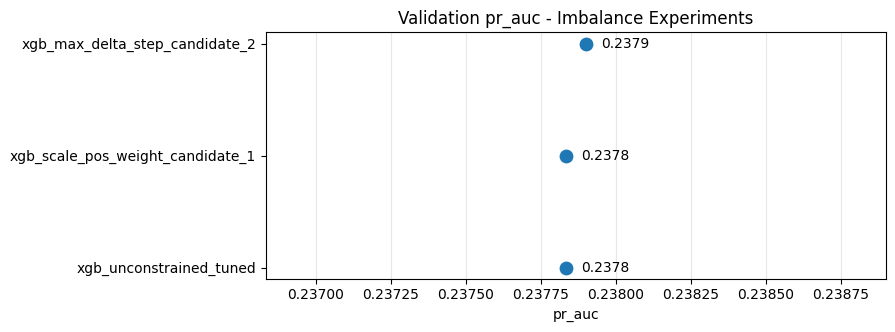

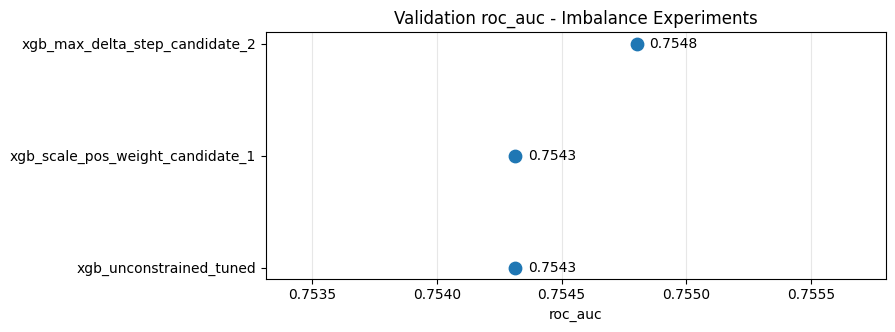

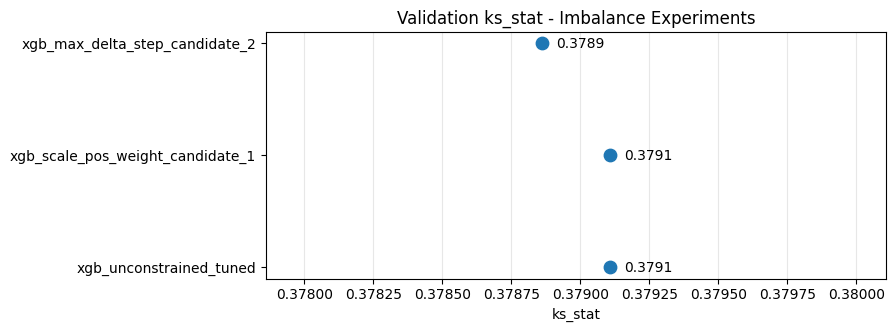

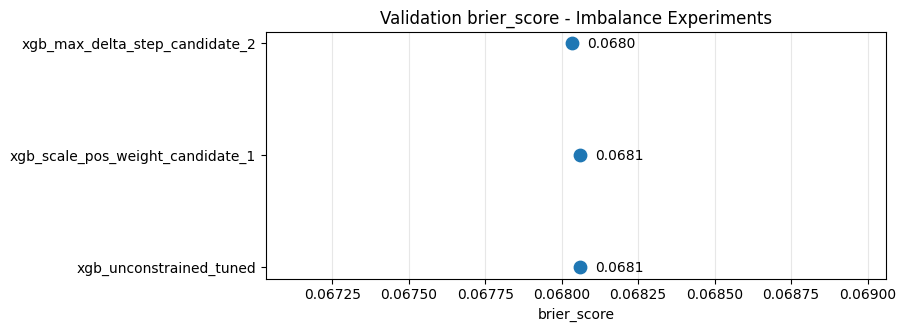

In [53]:
# Plot the key validation metrics for the imbalance experiments
for metric in ["pr_auc", "roc_auc", "ks_stat", "brier_score"]:
    plot_df = imbalance_compare_df[["model_name", metric]].copy()

    values = plot_df[metric].astype(float).to_numpy()
    names = plot_df["model_name"].tolist()
    y_pos = np.arange(len(plot_df))

    x_min = values.min()
    x_max = values.max()
    x_span = x_max - x_min
    padding = max(x_span * 0.35, 0.001)

    plt.figure(figsize=(8, 3.2))
    plt.scatter(values, y_pos, s=80)

    for x, y in zip(values, y_pos):
        plt.text(x + padding * 0.05, y, f"{x:.4f}", va="center")

    plt.yticks(y_pos, names)
    plt.xlim(x_min - padding, x_max + padding)
    plt.xlabel(metric)
    plt.title(f"Validation {metric} - Imbalance Experiments")
    plt.grid(True, axis="x", alpha=0.3)
    plt.show()

### 4.6. Final One-Hot Branch Benchmark After Imbalance Adjustments

The one-hot unconstrained XGBoost benchmark is selected only after considering the imbalance-adjusted variants.

This means the final one-hot benchmark carried forward is chosen from:

1. the tuned one-hot unconstrained baseline  
2. the best scale_pos_weight variant  
3. the best max_delta_step variant  

using the same metric-priority rule used elsewhere in the notebook.


In [54]:

# Select the final one-hot unconstrained XGBoost benchmark after
# imbalance adjustments.
#
# Selection priority:
# 1. PR-AUC
# 2. ROC-AUC
# 3. KS
# 4. Brier Score (lower is better)


final_onehot_unconstrained_candidates_df = pd.DataFrame([
    baseline_reference_row,                        # Tuned one-hot unconstrained benchmark
    scale_pos_weight_results_df.loc[0].to_dict(), # Best scale_pos_weight variant
    max_delta_step_results_df.loc[0].to_dict()    # Best max_delta_step variant
]).copy()

final_onehot_unconstrained_candidates_df = final_onehot_unconstrained_candidates_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

final_onehot_unconstrained_candidates_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0
1,xgb_unconstrained_tuned,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0
2,xgb_scale_pos_weight_candidate_1,validation,0.754314,0.237834,0.068060,0.379108,874,1.0,0.0


In [55]:

# Select the winning one-hot unconstrained benchmark after imbalance
# adjustments and map it back to the actual fitted model object.


selected_onehot_unconstrained_name = final_onehot_unconstrained_candidates_df.loc[0, "model_name"]
selected_onehot_unconstrained_val_result = final_onehot_unconstrained_candidates_df.loc[0].to_dict()

if selected_onehot_unconstrained_name == baseline_reference_row["model_name"]:
    selected_onehot_unconstrained_model = best_xgb_unconstrained
elif selected_onehot_unconstrained_name == scale_pos_weight_results_df.loc[0, "model_name"]:
    selected_onehot_unconstrained_model = best_xgb_scale_pos_weight
elif selected_onehot_unconstrained_name == max_delta_step_results_df.loc[0, "model_name"]:
    selected_onehot_unconstrained_model = best_xgb_max_delta_step
else:
    raise ValueError(f"Unexpected selected one-hot unconstrained model: {selected_onehot_unconstrained_name}")

print("Selected final one-hot unconstrained XGBoost benchmark:")
print(f"- Model name: {selected_onehot_unconstrained_name}")
print(f"- Validation PR-AUC: {selected_onehot_unconstrained_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {selected_onehot_unconstrained_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {selected_onehot_unconstrained_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {selected_onehot_unconstrained_val_result['brier_score']:.6f}")

Selected final one-hot unconstrained XGBoost benchmark:
- Model name: xgb_max_delta_step_candidate_2
- Validation PR-AUC: 0.237901
- Validation ROC-AUC: 0.754801
- Validation KS: 0.378861
- Validation Brier: 0.068034


In [56]:
# Store validation predicted probabilities for downstream comparisons
selected_onehot_unconstrained_val_prob = selected_onehot_unconstrained_model.predict_proba(X_val_ready)[:, 1]

The final XGBoost comparison below is between the strongest unconstrained benchmark found in the explored unconstrained search space and the strongest constrained benchmark found in the explored constrained search space.

Native categorical encoding is evaluated only in the unconstrained branch. The constrained branch keeps the explicit one-hot representation so that the monotonicity mapping, interaction-constraint structure, and post-training checks remain easy to inspect.

In [57]:
# Save final one-hot benchmark selection after imbalance adjustments

final_onehot_unconstrained_candidates_df.to_csv(FINAL_ONEHOT_UNCONSTRAINED_CANDIDATES_CSV, index=False)
pd.DataFrame([selected_onehot_unconstrained_val_result]).to_csv(FINAL_ONEHOT_UNCONSTRAINED_SELECTED_CSV, index=False)

print(f"Saved: {FINAL_ONEHOT_UNCONSTRAINED_CANDIDATES_CSV}")
print(f"Saved: {FINAL_ONEHOT_UNCONSTRAINED_SELECTED_CSV}")

Saved: ../output/xgboost/unconstrained/xgb_final_onehot_unconstrained_candidate_comparison_validation.csv
Saved: ../output/xgboost/unconstrained/xgb_final_onehot_unconstrained_selected_validation.csv


### 4.7. Native-Categorical Branch Imbalance Optimization: scale_pos_weight

#### 4.7.1. Helper to train model candidate with scale_pos_weight

In [58]:
# Helper:
# train one native-categorical XGBoost candidate with a chosen
# scale_pos_weight value, then evaluate on validation.

def train_and_evaluate_native_scale_pos_weight_candidate(scale_pos_weight_value, candidate_name):
    """
    Train one native-categorical XGBoost candidate using a specific
    scale_pos_weight value and evaluate it on the validation split.
    """

    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification
        eval_metric="aucpr",                     # PR-AUC remains primary because defaults are rare
        n_estimators=1000,                       # Large cap; early stopping chooses useful range
        early_stopping_rounds=50,                # Stop if validation PR-AUC stalls
        learning_rate=float(native_tier2_results_df.loc[0, "learning_rate"]),           # Best tuned native learning rate
        max_depth=int(native_tier2_results_df.loc[0, "max_depth"]),                     # Best tuned native depth
        min_child_weight=float(native_tier2_results_df.loc[0, "min_child_weight"]),     # Best tuned native min_child_weight
        subsample=float(native_tier2_results_df.loc[0, "subsample"]),                   # Best tuned native row sampling
        colsample_bytree=float(native_tier2_results_df.loc[0, "colsample_bytree"]),     # Best tuned native column sampling
        reg_lambda=float(native_tier2_results_df.loc[0, "reg_lambda"]),                 # Best tuned native L2 regularization
        scale_pos_weight=float(scale_pos_weight_value),                                  # Class-imbalance adjustment under test
        tree_method="hist",                      # Histogram-based tree building
        device="cuda",                           # GPU training
        enable_categorical=True,                 # Native categorical handling
        random_state=42,                         # Reproducibility
        n_jobs=-1                                # Use available CPU threads where relevant
    )

    fitted_model.fit(
        X_train_native,
        y_train,
        eval_set=[(X_val_native, y_val)],
        verbose=False
    )

    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_native,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    validation_result["scale_pos_weight"] = float(scale_pos_weight_value)
    validation_result["max_delta_step"] = 0

    return fitted_model, validation_result

#### 4.7.2. Search Grid

In [59]:
# Try a small native scale_pos_weight grid
native_scale_pos_weight_grid = [
    1.0,
    3.0,
    5.0,
    8.0,
    round(recommended_scale_pos_weight, 2),
    14.0
]

seen = set()
native_scale_pos_weight_grid = [
    x for x in native_scale_pos_weight_grid
    if not (x in seen or seen.add(x))
]

print("Native scale_pos_weight values to test:")
print(native_scale_pos_weight_grid)

Native scale_pos_weight values to test:
[1.0, 3.0, 5.0, 8.0, np.float64(11.39), 14.0]


#### 4.7.3. Generate and Evaluate Candidates

In [60]:
# Train and evaluate native scale_pos_weight candidates on validation
native_scale_pos_weight_results = []
native_scale_pos_weight_models = {}

for i, weight_value in enumerate(native_scale_pos_weight_grid, start=1):
    candidate_name = f"xgb_native_scale_pos_weight_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_native_scale_pos_weight_candidate(
        scale_pos_weight_value=weight_value,
        candidate_name=candidate_name
    )

    native_scale_pos_weight_models[candidate_name] = fitted_model
    native_scale_pos_weight_results.append(validation_result)

native_scale_pos_weight_results_df = pd.DataFrame(native_scale_pos_weight_results)

native_scale_pos_weight_results_df = native_scale_pos_weight_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

native_scale_pos_weight_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_native_scale_pos_weight_candidate_1,validation,0.753681,0.236253,0.068114,0.377201,751,1.00,0
1,xgb_native_scale_pos_weight_candidate_2,validation,0.752656,0.235489,0.083089,0.380132,609,3.00,0
2,xgb_native_scale_pos_weight_candidate_3,validation,0.752366,0.233560,0.108106,0.376759,647,5.00,0
3,xgb_native_scale_pos_weight_candidate_4,validation,0.751847,0.233128,0.146935,0.376783,626,8.00,0
4,xgb_native_scale_pos_weight_candidate_5,validation,0.751307,0.232932,0.186920,0.373163,626,11.39,0
5,xgb_native_scale_pos_weight_candidate_6,validation,0.750294,0.232329,0.214601,0.374850,628,14.00,0


### 4.8. Native-Categorical Branch Imbalance Optimization: max_delta_step

#### 4.8.1. Helper to train model candidate with max_delta_step

In [61]:
# Helper:
# train one native-categorical XGBoost candidate with a chosen
# max_delta_step value, then evaluate on validation.

def train_and_evaluate_native_max_delta_step_candidate(max_delta_step_value, candidate_name):
    """
    Train one native-categorical XGBoost candidate using a specific
    max_delta_step value and evaluate it on the validation split.
    """

    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification
        eval_metric="aucpr",                     # PR-AUC remains primary because defaults are rare
        n_estimators=1000,                       # Large cap; early stopping chooses useful range
        early_stopping_rounds=50,                # Stop if validation PR-AUC stalls
        learning_rate=float(native_tier2_results_df.loc[0, "learning_rate"]),           # Best tuned native learning rate
        max_depth=int(native_tier2_results_df.loc[0, "max_depth"]),                     # Best tuned native depth
        min_child_weight=float(native_tier2_results_df.loc[0, "min_child_weight"]),     # Best tuned native min_child_weight
        subsample=float(native_tier2_results_df.loc[0, "subsample"]),                   # Best tuned native row sampling
        colsample_bytree=float(native_tier2_results_df.loc[0, "colsample_bytree"]),     # Best tuned native column sampling
        reg_lambda=float(native_tier2_results_df.loc[0, "reg_lambda"]),                 # Best tuned native L2 regularization
        scale_pos_weight=1.0,                                                            # Keep class weighting neutral here
        max_delta_step=float(max_delta_step_value),                                      # Imbalance-related optimization under test
        tree_method="hist",                      # Histogram-based tree building
        device="cuda",                           # GPU training
        enable_categorical=True,                 # Native categorical handling
        random_state=42,                         # Reproducibility
        n_jobs=-1                                # Use available CPU threads where relevant
    )

    fitted_model.fit(
        X_train_native,
        y_train,
        eval_set=[(X_val_native, y_val)],
        verbose=False
    )

    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_native,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    validation_result["scale_pos_weight"] = 1.0
    validation_result["max_delta_step"] = float(max_delta_step_value)

    return fitted_model, validation_result

#### 4.8.2. Search Grid

In [62]:
# Try a small native max_delta_step grid
native_max_delta_step_grid = [0, 1, 2]

print("Native max_delta_step values to test:")
print(native_max_delta_step_grid)

Native max_delta_step values to test:
[0, 1, 2]


#### 4.8.3. Generate and Evaluate Candidates

In [63]:
# Train and evaluate native max_delta_step candidates on validation
native_max_delta_step_results = []
native_max_delta_step_models = {}

for i, delta_value in enumerate(native_max_delta_step_grid, start=1):
    candidate_name = f"xgb_native_max_delta_step_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_native_max_delta_step_candidate(
        max_delta_step_value=delta_value,
        candidate_name=candidate_name
    )

    native_max_delta_step_models[candidate_name] = fitted_model
    native_max_delta_step_results.append(validation_result)

native_max_delta_step_results_df = pd.DataFrame(native_max_delta_step_results)

native_max_delta_step_results_df = native_max_delta_step_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

native_max_delta_step_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_native_max_delta_step_candidate_1,validation,0.753681,0.236253,0.068114,0.377201,751,1.0,0.0
1,xgb_native_max_delta_step_candidate_2,validation,0.753216,0.235359,0.068143,0.373682,741,1.0,1.0
2,xgb_native_max_delta_step_candidate_3,validation,0.752255,0.233345,0.068231,0.377558,383,1.0,2.0


### 4.9. Final Native-Categorical Branch Benchmark After Imbalance Adjustments

In [64]:
#### 4.9.1. Model Candidate Table

In [65]:
# Select the final native benchmark after imbalance adjustments

native_baseline_reference_row = native_tier2_results_df.loc[0].to_dict()
native_baseline_reference_row["scale_pos_weight"] = 1.0
native_baseline_reference_row["max_delta_step"] = 0

final_native_candidates_df = pd.DataFrame([
    native_baseline_reference_row,
    native_scale_pos_weight_results_df.loc[0].to_dict(),
    native_max_delta_step_results_df.loc[0].to_dict()
]).copy()

final_native_candidates_df = final_native_candidates_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

final_native_candidates_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,scale_pos_weight,max_delta_step
0,xgb_native_tier2_candidate_9,validation,0.753681,0.236253,0.068114,0.377201,751,0.03,5.0,7.0,0.8,0.8,0.5,1.0,0.0
1,xgb_native_scale_pos_weight_candidate_1,validation,0.753681,0.236253,0.068114,0.377201,751,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
2,xgb_native_max_delta_step_candidate_1,validation,0.753681,0.236253,0.068114,0.377201,751,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0


#### 4.9.2. Selected Model Mapping

In [66]:
# Map final native benchmark back to the fitted model object
selected_native_unconstrained_name = final_native_candidates_df.loc[0, "model_name"]
selected_native_unconstrained_val_result = final_native_candidates_df.loc[0].to_dict()

if selected_native_unconstrained_name == native_baseline_reference_row["model_name"]:
    selected_native_unconstrained_model = best_xgb_native_tuned
elif selected_native_unconstrained_name == native_scale_pos_weight_results_df.loc[0, "model_name"]:
    selected_native_unconstrained_model = native_scale_pos_weight_models[selected_native_unconstrained_name]
elif selected_native_unconstrained_name == native_max_delta_step_results_df.loc[0, "model_name"]:
    selected_native_unconstrained_model = native_max_delta_step_models[selected_native_unconstrained_name]
else:
    raise ValueError(f"Unexpected selected native model: {selected_native_unconstrained_name}")

selected_native_unconstrained_val_prob = selected_native_unconstrained_model.predict_proba(X_val_native)[:, 1]

print("Selected final native unconstrained benchmark:")
print(f"- Model name: {selected_native_unconstrained_name}")
print(f"- Validation PR-AUC: {selected_native_unconstrained_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {selected_native_unconstrained_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {selected_native_unconstrained_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {selected_native_unconstrained_val_result['brier_score']:.6f}")

# Save final native benchmark selection artifacts
final_native_candidates_df.to_csv(FINAL_NATIVE_CANDIDATES_CSV, index=False)
pd.DataFrame([selected_native_unconstrained_val_result]).to_csv(FINAL_NATIVE_SELECTED_CSV, index=False)

print(f"Saved: {FINAL_NATIVE_CANDIDATES_CSV}")
print(f"Saved: {FINAL_NATIVE_SELECTED_CSV}")

Selected final native unconstrained benchmark:
- Model name: xgb_native_tier2_candidate_9
- Validation PR-AUC: 0.236253
- Validation ROC-AUC: 0.753681
- Validation KS: 0.377201
- Validation Brier: 0.068114
Saved: ../output/xgboost/native/xgb_final_native_candidate_comparison_validation.csv
Saved: ../output/xgboost/native/xgb_final_native_selected_validation.csv


The unconstrained XGBoost benchmark is selected only after the one-hot and native-categorical branches have each been optimized separately. Each branch therefore contributes its own final branch winner to the comparison below.

## 5. FINAL UNCONSTRAINED XGBOOST BENCHMARK SELECTION

We now compare:

1. the selected final one-hot unconstrained benchmark after imbalance adjustments  
2. the best tuned native-categorical unconstrained model  

and choose the final unconstrained XGBoost benchmark to carry forward into the constrained comparison and final held-out test evaluation.

In [67]:
# Select the final unconstrained XGBoost benchmark across the two
# encoding approaches.
# Candidates:
# 1. selected one-hot unconstrained benchmark after one-hot imbalance handling
# 2. selected native-categorical unconstrained benchmark after native imbalance handling


final_unconstrained_xgb_candidates_df = pd.DataFrame([
    selected_onehot_unconstrained_val_result,
    selected_native_unconstrained_val_result
]).copy()

final_unconstrained_xgb_candidates_df = final_unconstrained_xgb_candidates_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

final_unconstrained_xgb_candidates_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,xgb_native_tier2_candidate_9,validation,0.753681,0.236253,0.068114,0.377201,751,1.0,0.0,0.03,5.0,7.0,0.8,0.8,0.5


In [68]:
# Select the final unconstrained XGBoost benchmark across one-hot and
# native-categorical branches.


selected_final_unconstrained_name = final_unconstrained_xgb_candidates_df.loc[0, "model_name"]
selected_final_unconstrained_val_result = final_unconstrained_xgb_candidates_df.loc[0].to_dict()

if selected_final_unconstrained_name == selected_onehot_unconstrained_name:
    selected_final_unconstrained_model = selected_onehot_unconstrained_model
elif selected_final_unconstrained_name == selected_native_unconstrained_name:
    selected_final_unconstrained_model = selected_native_unconstrained_model
else:
    raise ValueError(f"Unexpected final unconstrained XGBoost selection: {selected_final_unconstrained_name}")

print("Selected final unconstrained XGBoost benchmark:")
print(f"- Model name: {selected_final_unconstrained_name}")
print(f"- Validation PR-AUC: {selected_final_unconstrained_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {selected_final_unconstrained_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {selected_final_unconstrained_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {selected_final_unconstrained_val_result['brier_score']:.6f}")

Selected final unconstrained XGBoost benchmark:
- Model name: xgb_max_delta_step_candidate_2
- Validation PR-AUC: 0.237901
- Validation ROC-AUC: 0.754801
- Validation KS: 0.378861
- Validation Brier: 0.068034


In [69]:
# Store the correct feature representation for the selected final
# unconstrained benchmark so all downstream validation / test
# evaluation uses the right input matrix.

if selected_final_unconstrained_name == selected_onehot_unconstrained_name:
    selected_final_unconstrained_X_val = X_val_ready
    selected_final_unconstrained_X_test = X_test_ready
    selected_final_unconstrained_representation = "onehot"
elif selected_final_unconstrained_name == selected_native_unconstrained_name:
    selected_final_unconstrained_X_val = X_val_native
    selected_final_unconstrained_X_test = X_test_native
    selected_final_unconstrained_representation = "native"
else:
    raise ValueError(
        f"Could not determine representation for selected final unconstrained model: "
        f"{selected_final_unconstrained_name}"
    )

# Store validation predicted probabilities for downstream selected-vs-selected plots
selected_final_unconstrained_val_prob = selected_final_unconstrained_model.predict_proba(
    selected_final_unconstrained_X_val
)[:, 1]

print("Selected final unconstrained representation:")
print(selected_final_unconstrained_representation)

# Save final unconstrained benchmark selection
final_unconstrained_xgb_candidates_df.to_csv(FINAL_UNCONSTRAINED_XGB_CANDIDATES_CSV, index=False)
pd.DataFrame([selected_final_unconstrained_val_result]).to_csv(FINAL_UNCONSTRAINED_XGB_SELECTED_CSV, index=False)

print(f"Saved: {FINAL_UNCONSTRAINED_XGB_CANDIDATES_CSV}")
print(f"Saved: {FINAL_UNCONSTRAINED_XGB_SELECTED_CSV}")

Selected final unconstrained representation:
onehot
Saved: ../output/xgboost/final/xgb_final_unconstrained_candidate_comparison_validation.csv
Saved: ../output/xgboost/final/xgb_final_unconstrained_selected_validation.csv


## 6. CONSTRAINED XGBOOST MODEL

We introduce the following constraints on the XGBoost model:

1. Monotonicity on selected features whose economic direction is well understood  
2. Additivity so the model cannot learn cross-feature interaction effects

NOTE: The constrained XGBoost branches below are evaluated relative to the selected final unconstrained XGBoost benchmark.


### 6.1. Define Monotonic Constraints

Specify monotonic directions for selected original features:
- +1 means higher feature values should increase predicted default risk
- -1 means higher feature values should decrease predicted default risk
- 0 means no monotonic constraint is imposed

NOTE: The monotonic direction is first defined at the raw feature level and then mapped onto the encoded training columns.

In [70]:

# Define monotonic directions for selected original features
# (NB To be mapped onto the one-hot encoded XGBoost features)

original_feature_monotonicity = {
    "AMT_INCOME_TOTAL": -1,                 # Higher income should not increase default risk
    "DAYS_BIRTH": -1,                       # Older age should not increase default risk
    "DAYS_EMPLOYED": -1,                    # Longer employment should not increase default risk
    "AMT_REQ_CREDIT_BUREAU_HOUR": 1,        # More bureau inquiries should not decrease risk
    "AMT_REQ_CREDIT_BUREAU_DAY": 1,
    "AMT_REQ_CREDIT_BUREAU_WEEK": 1,
    "AMT_REQ_CREDIT_BUREAU_MON": 1,
    "AMT_REQ_CREDIT_BUREAU_QRT": 1,
    "AMT_REQ_CREDIT_BUREAU_YEAR": 1,
    "EXT_SOURCE_1": -1,                     # Higher external scores should not increase risk
    "EXT_SOURCE_2": -1,
    "EXT_SOURCE_3": -1
}

original_feature_monotonicity

{'AMT_INCOME_TOTAL': -1,
 'DAYS_BIRTH': -1,
 'DAYS_EMPLOYED': -1,
 'AMT_REQ_CREDIT_BUREAU_HOUR': 1,
 'AMT_REQ_CREDIT_BUREAU_DAY': 1,
 'AMT_REQ_CREDIT_BUREAU_WEEK': 1,
 'AMT_REQ_CREDIT_BUREAU_MON': 1,
 'AMT_REQ_CREDIT_BUREAU_QRT': 1,
 'AMT_REQ_CREDIT_BUREAU_YEAR': 1,
 'EXT_SOURCE_1': -1,
 'EXT_SOURCE_2': -1,
 'EXT_SOURCE_3': -1}

In [71]:
# Build table of features for which we apply monotonic constraints

monotonic_feature_summary_df = pd.DataFrame({
    "feature_name": list(original_feature_monotonicity.keys()),
    "monotone_direction": list(original_feature_monotonicity.values())
})

# Add a plain-English interpretation column to display results later
monotonic_feature_summary_df["interpretation"] = monotonic_feature_summary_df["monotone_direction"].map({
    1: "Higher values should not decrease predicted risk",
    -1: "Higher values should not increase predicted risk"
})

monotonic_feature_summary_df

,feature_name,monotone_direction,interpretation
0,AMT_INCOME_TOTAL,-1,Higher values should not increase predicted risk
1,DAYS_BIRTH,-1,Higher values should not increase predicted risk
2,DAYS_EMPLOYED,-1,Higher values should not increase predicted risk
3,AMT_REQ_CREDIT_BUREAU_HOUR,1,Higher values should not decrease predicted risk
4,AMT_REQ_CREDIT_BUREAU_DAY,1,Higher values should not decrease predicted risk
5,AMT_REQ_CREDIT_BUREAU_WEEK,1,Higher values should not decrease predicted risk
6,AMT_REQ_CREDIT_BUREAU_MON,1,Higher values should not decrease predicted risk
7,AMT_REQ_CREDIT_BUREAU_QRT,1,Higher values should not decrease predicted risk
8,AMT_REQ_CREDIT_BUREAU_YEAR,1,Higher values should not decrease predicted risk
9,EXT_SOURCE_1,-1,Higher values should not increase predicted risk


##### Map monotonic directions onto the encoded training data

Since categorical variables were one-hot encoded downstream, we now build a monotone-constraint vector aligned with feature_names.

Only selected original numeric features receive non-zero monotonic constraints. All other encoded columns remain unconstrained.

In [72]:
# Build monotone-constraint list aligned with encoded training data

monotone_constraints_list = []

for feature in feature_names:
    # If encoded feature name exactly matches selected raw numeric features apply its monotonic direction
    if feature in original_feature_monotonicity:
        monotone_constraints_list.append(original_feature_monotonicity[feature])
    # Otherwise assign 0 meaning no monotonic constraint
    else:
        monotone_constraints_list.append(0)

# XGBoost accepts monotone constraints as a tuple
monotone_constraints_tuple = tuple(monotone_constraints_list)

print(f"Total encoded features: {len(feature_names)}")
print(f"Total monotone constraints: {len(monotone_constraints_tuple)}")
print(f"Non-zero monotone constraints: {sum(int(x != 0) for x in monotone_constraints_tuple)}")

Total encoded features: 127
Total monotone constraints: 127
Non-zero monotone constraints: 12


In [73]:
# Build diagnostic table showing which encoded columns received non-zero monotonic constraint

monotone_alignment_df = pd.DataFrame({
    "encoded_feature_name": feature_names,
    "monotone_direction": monotone_constraints_tuple
})

monotone_alignment_nonzero_df = monotone_alignment_df[
    monotone_alignment_df["monotone_direction"] != 0
].copy()

monotone_alignment_nonzero_df

,encoded_feature_name,monotone_direction
0,AMT_INCOME_TOTAL,-1
4,DAYS_BIRTH,-1
5,DAYS_EMPLOYED,-1
11,EXT_SOURCE_1,-1
12,EXT_SOURCE_2,-1
13,EXT_SOURCE_3,-1
14,AMT_REQ_CREDIT_BUREAU_HOUR,1
15,AMT_REQ_CREDIT_BUREAU_DAY,1
16,AMT_REQ_CREDIT_BUREAU_WEEK,1
17,AMT_REQ_CREDIT_BUREAU_MON,1


In [74]:
# Save the encoded-feature monotonic alignment table to output in csv

monotone_alignment_nonzero_df.to_csv(MONOTONE_ALIGNMENT_CSV, index=False)

print(f"Saved: {MONOTONE_ALIGNMENT_CSV}")

Saved: ../output/xgboost/audit/xgb_monotone_constraint_alignment.csv


In [75]:

# Build monotonicity audit table for interpretability / audit discussion:
# - original constrained feature
# - monotone sign
# - plain-English constraint meaning
# - business rationale for why that sign was imposed


monotonicity_business_rationale = {
    "AMT_INCOME_TOTAL": "Higher income should not make a borrower look riskier.",
    "DAYS_BIRTH": "Older age should not increase predicted default risk.",
    "DAYS_EMPLOYED": "Longer employment duration should not increase predicted default risk.",
    "AMT_REQ_CREDIT_BUREAU_HOUR": "More recent credit inquiries should not reduce predicted risk.",
    "AMT_REQ_CREDIT_BUREAU_DAY": "More recent credit inquiries should not reduce predicted risk.",
    "AMT_REQ_CREDIT_BUREAU_WEEK": "More recent credit inquiries should not reduce predicted risk.",
    "AMT_REQ_CREDIT_BUREAU_MON": "More recent credit inquiries should not reduce predicted risk.",
    "AMT_REQ_CREDIT_BUREAU_QRT": "More recent credit inquiries should not reduce predicted risk.",
    "AMT_REQ_CREDIT_BUREAU_YEAR": "More recent credit inquiries should not reduce predicted risk."
}

monotonicity_audit_df = monotonic_feature_summary_df.copy()

monotonicity_audit_df["constraint_sign_label"] = monotonicity_audit_df["monotone_direction"].map({
    -1: "-1",
     1: "+1"
})

monotonicity_audit_df["constraint_rule"] = monotonicity_audit_df["monotone_direction"].map({
    -1: "Prediction must move non-increasingly with the feature",
     1: "Prediction must move non-decreasingly with the feature"
})

monotonicity_audit_df["business_rationale"] = monotonicity_audit_df["feature_name"].map(
    monotonicity_business_rationale
)

monotonicity_audit_df

,feature_name,monotone_direction,interpretation,constraint_sign_label,constraint_rule,business_rationale
0,AMT_INCOME_TOTAL,-1,Higher values should not increase predicted risk,-1,Prediction must move non-increasingly with the...,Higher income should not make a borrower look ...
1,DAYS_BIRTH,-1,Higher values should not increase predicted risk,-1,Prediction must move non-increasingly with the...,Older age should not increase predicted defaul...
2,DAYS_EMPLOYED,-1,Higher values should not increase predicted risk,-1,Prediction must move non-increasingly with the...,Longer employment duration should not increase...
3,AMT_REQ_CREDIT_BUREAU_HOUR,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
4,AMT_REQ_CREDIT_BUREAU_DAY,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
5,AMT_REQ_CREDIT_BUREAU_WEEK,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
6,AMT_REQ_CREDIT_BUREAU_MON,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
7,AMT_REQ_CREDIT_BUREAU_QRT,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
8,AMT_REQ_CREDIT_BUREAU_YEAR,1,Higher values should not decrease predicted risk,+1,Prediction must move non-decreasingly with the...,More recent credit inquiries should not reduce...
9,EXT_SOURCE_1,-1,Higher values should not increase predicted risk,-1,Prediction must move non-increasingly with the...,NaN


In [76]:
# Save richer monotonicity audit table for write-up / appendix use

monotonicity_audit_df.to_csv(MONOTONICITY_AUDIT_CSV, index=False)

print(f"Saved: {MONOTONICITY_AUDIT_CSV}")

Saved: ../output/xgboost/audit/xgb_monotonicity_audit_table.csv


### 6.2. Define Additivity / Interaction Constraints

Additivity enforced using interaction constraints to prevent trees from learning cross-feature interactions

Each encoded feature column is assigned to its own singleton interaction group blocking interaction paths that combine multiple features

In [77]:
# Build singleton interaction-constraint groups to enforce additivity.
# - trees may learn nonlinear effects within a single feature
# - trees may not combine multiple features along the same path

interaction_constraints_list = [[feature] for feature in feature_names]

print(f"Number of singleton interaction groups: {len(interaction_constraints_list)}")
print("First 5 groups:", interaction_constraints_list[:5])

Number of singleton interaction groups: 127
First 5 groups: [['AMT_INCOME_TOTAL'], ['AMT_CREDIT'], ['AMT_ANNUITY'], ['AMT_GOODS_PRICE'], ['DAYS_BIRTH']]


In [78]:
# Sanity check: every constrained feature name should be present in the encoded training data cols

all_constraint_features = [group[0] for group in interaction_constraints_list]

missing_constraint_features = [
    feature for feature in all_constraint_features
    if feature not in X_train_ready.columns
]

print(f"Total interaction-constraint features: {len(all_constraint_features)}")
print(f"Missing from training matrix: {len(missing_constraint_features)}")

if missing_constraint_features:
    print("Missing features:", missing_constraint_features[:10])
else:
    print("All interaction-constraint feature names are present in X_train_ready.")

Total interaction-constraint features: 127
Missing from training matrix: 0
All interaction-constraint feature names are present in X_train_ready.


In [79]:

# Build an interaction-constraint audit table.
#
# Because we are enforcing additivity through singleton interaction
# groups, each encoded feature is allowed to interact only with itself.
#
# This makes the allowed interaction structure fully explicit and
# auditable at the realized encoded-feature level.


interaction_constraint_rows = []

for interaction_group_id, feature_group in enumerate(interaction_constraints_list, start=1):
    for feature_name in feature_group:
        interaction_constraint_rows.append({
            "interaction_group_id": interaction_group_id,
            "encoded_feature_name": feature_name
        })

interaction_constraint_audit_df = pd.DataFrame(interaction_constraint_rows)

interaction_constraint_audit_df

,interaction_group_id,encoded_feature_name
0,1,AMT_INCOME_TOTAL
1,2,AMT_CREDIT
2,3,AMT_ANNUITY
3,4,AMT_GOODS_PRICE
4,5,DAYS_BIRTH
...,...,...
122,123,ORGANIZATION_TYPE_Transport: type 2
123,124,ORGANIZATION_TYPE_Transport: type 3
124,125,ORGANIZATION_TYPE_Transport: type 4
125,126,ORGANIZATION_TYPE_University


In [80]:
# Grouped view of the interaction-constraint structure
interaction_constraint_summary_df = (
    interaction_constraint_audit_df
    .groupby("interaction_group_id", as_index=False)["encoded_feature_name"]
    .agg(list)
    .rename(columns={"encoded_feature_name": "allowed_features_in_group"})
)

interaction_constraint_summary_df.head(20)

,interaction_group_id,allowed_features_in_group
0,1,[AMT_INCOME_TOTAL]
1,2,[AMT_CREDIT]
2,3,[AMT_ANNUITY]
3,4,[AMT_GOODS_PRICE]
4,5,[DAYS_BIRTH]
5,6,[DAYS_EMPLOYED]
6,7,[DAYS_REGISTRATION]
7,8,[DAYS_ID_PUBLISH]
8,9,[OWN_CAR_AGE]
9,10,[CNT_CHILDREN]


In [81]:
# Save interaction-constraint audit tables

interaction_constraint_audit_df.to_csv(INTERACTION_AUDIT_CSV, index=False)
interaction_constraint_summary_df.to_csv(INTERACTION_SUMMARY_CSV, index=False)

print(f"Saved: {INTERACTION_AUDIT_CSV}")
print(f"Saved: {INTERACTION_SUMMARY_CSV}")

Saved: ../output/xgboost/audit/xgb_interaction_constraint_audit_table.csv
Saved: ../output/xgboost/audit/xgb_interaction_constraint_summary_table.csv


### 6.3. Constraint Audit and Reference Constrained Branch

The constrained XGBoost specification auditable in three ways:

1. Shows the exact monotonicity rules imposed on selected features.
2. Shows the exact interaction-constraint structure used to simulate additivity.
3. Checks whether the fitted constrained model behaves in the intended monotonic direction on key constrained variables.

Makes the constrained one-hot implementation easier to inspect and explain to regulators than a constrained native-categorical version.

This first constrained XGBoost run is a reference constrained branch rather than the final selected constrained benchmark.

It starts from the selected one-hot unconstrained benchmark and then adds:

- monotonicity constraints on selected features
- interaction constraints used to simulate additivity

The purpose of this reference branch is to show the immediate validation-level effect of adding the constraints before any constrained-specific retuning.

The final constrained benchmark is selected later, after constrained tuning and imbalance optimization.

In [ ]:
# Build the reference constrained branch by taking the selected one-hot
# unconstrained model settings and then adding the structural constraints

# Read the fitted hyperparameters from the selected one-hot unconstrained model
selected_onehot_unconstrained_params = selected_onehot_unconstrained_model.get_xgb_params()

carryover_constrained_params = {
    "learning_rate": float(selected_onehot_unconstrained_params["learning_rate"]),         # Carry overs selected one-hot benchmark
    "max_depth": int(selected_onehot_unconstrained_params["max_depth"]),
    "min_child_weight": float(selected_onehot_unconstrained_params["min_child_weight"]),
    "subsample": float(selected_onehot_unconstrained_params["subsample"]),
    "colsample_bytree": float(selected_onehot_unconstrained_params["colsample_bytree"]),
    "reg_lambda": float(selected_onehot_unconstrained_params["reg_lambda"]),
    "scale_pos_weight": float(selected_onehot_unconstrained_params["scale_pos_weight"]),
    "max_delta_step": float(selected_onehot_unconstrained_params["max_delta_step"]),
}

xgb_constrained_carryover = XGBClassifier(
    objective="binary:logistic",                      # Binary classification: predict probability of default
    eval_metric="aucpr",                              # PR-AUC remains primary because defaults are rare
    n_estimators=1000,                                # Large cap on boosting rounds; early stopping chooses the effective count
    early_stopping_rounds=50,                         # Stop when validation PR-AUC no longer improves
    tree_method="hist",                               # Efficient histogram-based tree construction
    device="cuda",                                    # Use GPU
    random_state=42,                                  # Reproducibility
    n_jobs=-1,                                        # Use available CPU threads where relevant
    monotone_constraints=monotone_constraints_tuple,  # Enforce selected monotonic directions
    interaction_constraints=interaction_constraints_list,  # Enforce additivity-style restrictions
    **carryover_constrained_params                    # Carry over the selected one-hot unconstrained benchmark settings
)

# Fit carry-over constrained reference branch using validation data for early stopping
xgb_constrained_carryover.fit(
    X_train_ready,
    y_train,
    eval_set=[(X_val_ready, y_val)],
    verbose=False
)

print("Carry-over parameters used:")
print(carryover_constrained_params)

print(f"Carry-over constrained best iteration: {xgb_constrained_carryover.best_iteration}")
print(f"Carry-over constrained best score: {xgb_constrained_carryover.best_score}")

Carry-over parameters used:
{'learning_rate': 0.03, 'max_depth': 5, 'min_child_weight': 3.0, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_lambda': 0.5, 'scale_pos_weight': 1.0, 'max_delta_step': 1.0}
Carry-over constrained best iteration: 987
Carry-over constrained best score: 0.21511034856843017


In [ ]:
# Evaluate the carry-over constrained reference branch on validation

constrained_carryover_val_result = evaluate_binary_model(
    model=xgb_constrained_carryover,
    X=X_val_ready,
    y=y_val,
    split_name="validation",
    model_name="xgb_constrained_carryover_reference"
)

# Add the carried-over hyperparameters to the validation result row
for param_name, param_value in carryover_constrained_params.items():
    constrained_carryover_val_result[param_name] = param_value

constrained_carryover_val_result["best_iteration"] = xgb_constrained_carryover.best_iteration
constrained_carryover_val_result["best_score"] = xgb_constrained_carryover.best_score

# Store validation probabilities for plots
constrained_carryover_val_prob = xgb_constrained_carryover.predict_proba(X_val_ready)[:, 1]

# Compare the selected one-hot unconstrained benchmark with the reference constrained branch
xgb_constraint_carryover_compare_df = pd.DataFrame([
    selected_onehot_unconstrained_val_result,
    constrained_carryover_val_result
])

# Add metadata for later cross-architecture comparison
xgb_constraint_carryover_compare_df["architecture"] = "xgboost"
xgb_constraint_carryover_compare_df["experiment_group"] = "selected_onehot_vs_constrained_carryover_validation"
xgb_constraint_carryover_compare_df["constraint_status"] = xgb_constraint_carryover_compare_df["model_name"].map({
    selected_onehot_unconstrained_name: "unconstrained",
    "xgb_constrained_carryover_reference": "constrained"
})

xgb_constraint_carryover_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,best_score,architecture,experiment_group,constraint_status
0,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,xgboost,selected_onehot_vs_constrained_carryover_valid...,unconstrained
1,xgb_constrained_carryover_reference,validation,0.743577,0.215401,0.069030,0.363503,987,1.0,1.0,0.03,5.0,3.0,0.7,0.7,0.5,0.21511,xgboost,selected_onehot_vs_constrained_carryover_valid...,constrained


In [ ]:
# Save reference constrained-branch validation outputs

# Save single-row carry-over constrained validation result
pd.DataFrame([constrained_carryover_val_result]).to_csv(CONSTRAINED_VAL_RESULTS_CSV, index=False)

# Save selected one-hot unconstrained vs carry-over constrained validation comparison
xgb_constraint_carryover_compare_df.to_csv(CONSTRAINED_COMPARE_CSV, index=False)

print(f"Saved: {CONSTRAINED_VAL_RESULTS_CSV}")
print(f"Saved: {CONSTRAINED_COMPARE_CSV}")

Saved: ../output/xgboost/constrained/xgb_constrained_validation_results.csv
Saved: ../output/xgboost/constrained/xgb_constrained_vs_unconstrained_validation_comparison.csv


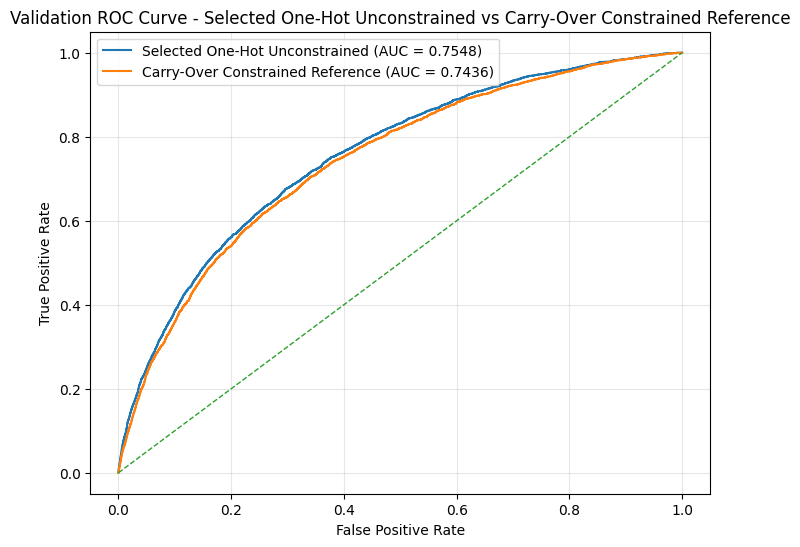

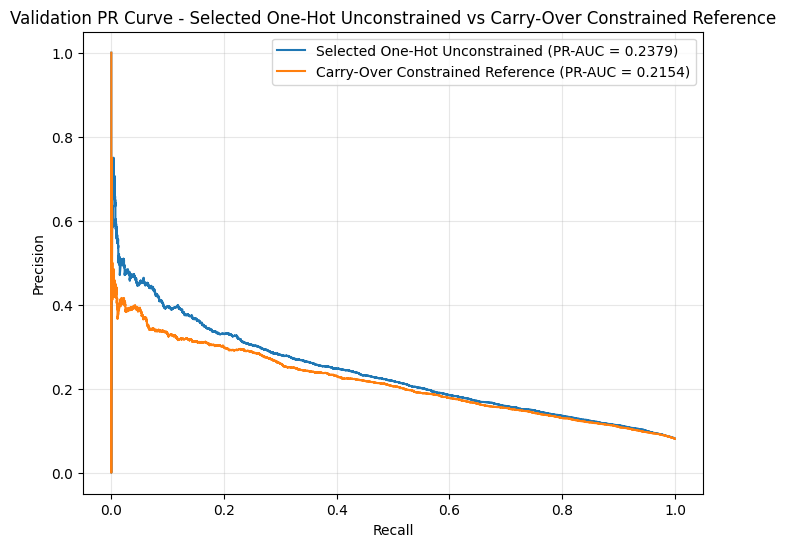

In [86]:
# Validation ROC and PR curves: selected one-hot unconstrained vs
# carry-over constrained reference branch

plot_roc_curves(
    curves_dict={
        "Selected One-Hot Unconstrained": (y_val, selected_onehot_unconstrained_val_prob),
        "Carry-Over Constrained Reference": (y_val, constrained_carryover_val_prob)
    },
    title="Validation ROC Curve - Selected One-Hot Unconstrained vs Carry-Over Constrained Reference"
)

plot_pr_curves(
    curves_dict={
        "Selected One-Hot Unconstrained": (y_val, selected_onehot_unconstrained_val_prob),
        "Carry-Over Constrained Reference": (y_val, constrained_carryover_val_prob)
    },
    title="Validation PR Curve - Selected One-Hot Unconstrained vs Carry-Over Constrained Reference"
)

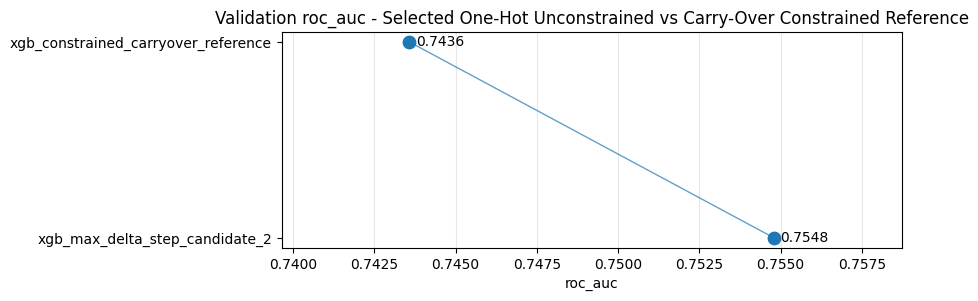

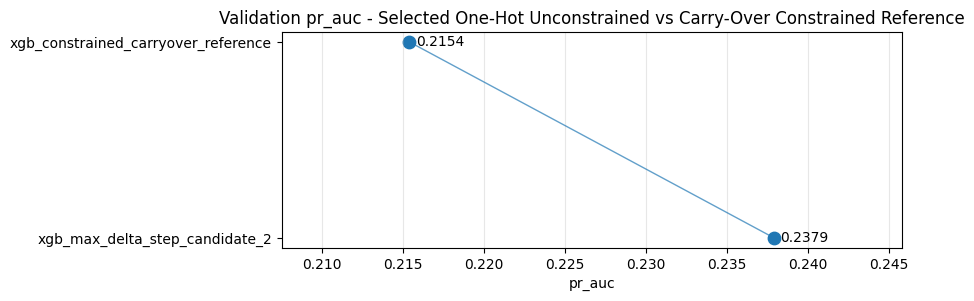

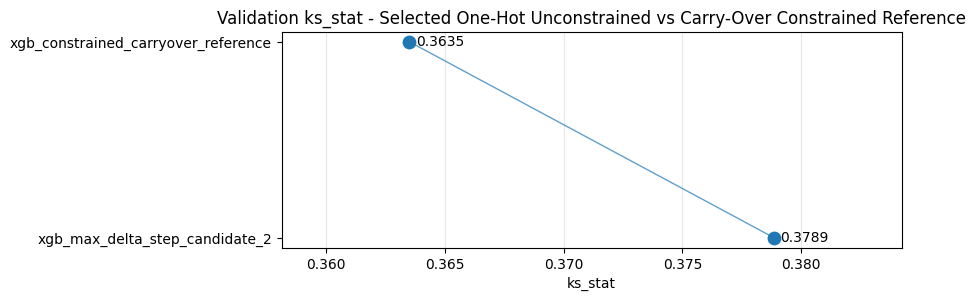

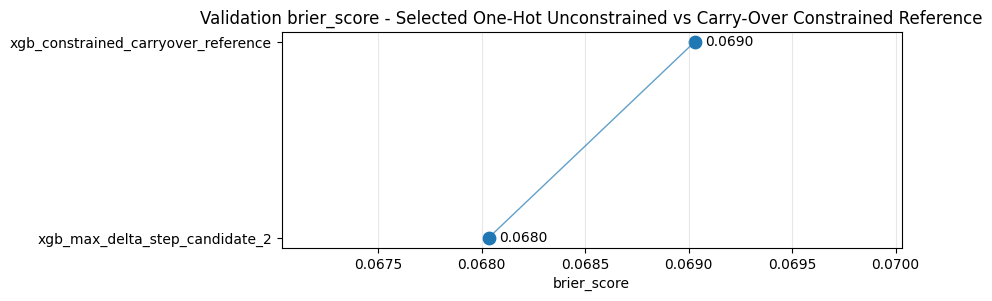

In [87]:
# Plot validation metric comparisons: selected one-hot unconstrained vs
# carry-over constrained reference branch
metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=xgb_constraint_carryover_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Selected One-Hot Unconstrained vs Carry-Over Constrained Reference",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

### Interpretation of reference constrained-branch validation results

This experiment compares the selected one-hot unconstrained benchmark with a reference constrained branch that imposes monotonicity and additivity-style interaction restrictions on the same one-hot setup.

At this point, the main change is the introduction of the structural constraints themselves. The difference in validation performance therefore reflects the initial predictive cost of adding the constraints before constrained-specific retuning.

The later constrained tuning and imbalance-optimization sections show whether part of that loss can be recovered within the constrained search space.

### 6.4. Independently Tune the Constrained XGBoost Branch

The constrained XGBoost branch is tuned independently so that the final constrained-versus-unconstrained comparison reflects a reasonably optimized model on each side.

The constrained branch keeps the one-hot encoded representation. This is a scope choice made for interpretability and auditability. Under one-hot encoding, the notebook can show the monotonicity mapping over realized model columns, the allowed interaction groups used to simulate additivity, and post-training checks on key constrained variables. Native categorical handling would make that constrained structure harder to inspect directly.

Within the constrained one-hot branch, the optimization sequence mirrors the one-hot unconstrained branch after the reference constrained step:

1. start from the selected one-hot unconstrained benchmark and impose the constraints
2. measure the immediate validation effect of the constraints
3. retune the constrained branch using the same two-stage tuning philosophy
4. run constrained imbalance-adjustment experiments
5. select the final constrained benchmark from the explored constrained search space

In [88]:

# Helper function:
# train one constrained XGBoost candidate on the training split,
# use the validation split for early stopping,
# and return both the fitted model and its validation metrics.
#
# This mirrors the unconstrained tuning helper, but always includes:
# - monotone constraints
# - interaction constraints for additivity

def train_and_evaluate_constrained_xgb_candidate(candidate_params, candidate_name):
    """
    Train one constrained XGBoost candidate and evaluate it on the
    validation split.

    Parameters
    ----------
    candidate_params : dict
        Dictionary containing the hyperparameters for this candidate.
    candidate_name : str
        Human-readable label for tracking this candidate.

    Returns
    -------
    fitted_model : XGBClassifier
        Trained constrained XGBoost model.
    validation_result : dict
        Validation metrics and metadata for this candidate.
    """

    # Build constrained candidate model using candidate-specific
    # hyperparameter values plus the already defined structural
    # constraints.
    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification
        eval_metric="aucpr",                     # PR-AUC remains primary because defaults are rare
        n_estimators=1000,                       # Large cap; early stopping chooses useful range
        early_stopping_rounds=50,                # Stop if validation PR-AUC does not improve for 50 rounds
        tree_method="hist",                      # Efficient histogram-based tree building
        device="cuda",                           # Train on GPU
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        monotone_constraints=monotone_constraints_tuple,      # Enforce monotonicity
        interaction_constraints=interaction_constraints_list, # Enforce additivity
        **candidate_params                       # Insert candidate-specific hyperparameters
    )

    # Fit on training data while monitoring validation performance
    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],
        verbose=False
    )

    # Evaluate candidate on validation using the shared helper
    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    # Add metadata so the tuning table is self-contained
    validation_result["best_iteration"] = fitted_model.best_iteration
    validation_result["best_score"] = fitted_model.best_score

    for param_name, param_value in candidate_params.items():
        validation_result[param_name] = param_value

    return fitted_model, validation_result

In [89]:

# Stage 1 constrained tuning:
# first tune the tree-complexity controls.
#
# We keep the search space aligned with the unconstrained tuning logic
# so the extension remains easy to explain and broadly fair.

constrained_stage_1_grid = {
    "learning_rate": [0.05],        # Hold fixed in Stage 1
    "max_depth": [3, 4, 5],         # Same structural search range as the unconstrained one-hot branch
    "min_child_weight": [3, 5, 7],  # Same structural search range as the unconstrained one-hot branch
    "subsample": [0.8],             # Hold fixed in Stage 1
    "colsample_bytree": [0.8],      # Hold fixed in Stage 1
    "reg_lambda": [1.0]             # Hold fixed in Stage 1
}

constrained_stage_1_param_names = list(constrained_stage_1_grid.keys())
constrained_stage_1_combinations = list(product(*constrained_stage_1_grid.values()))

print(f"Number of constrained Stage 1 candidates: {len(constrained_stage_1_combinations)}")

Number of constrained Stage 1 candidates: 9


In [90]:

# Run constrained Stage 1 tuning:
# - fit each constrained candidate on the training split
# - evaluate on the validation split
# - rank candidates using the same priority rule as before
#
# Selection priority:
# 1. PR-AUC
# 2. ROC-AUC
# 3. KS
# 4. Brier score (lower is better)

constrained_stage_1_results = []
constrained_stage_1_models = {}

for i, combo in enumerate(constrained_stage_1_combinations, start=1):
    # Map tuple back to named hyperparameter dictionary
    candidate_params = dict(zip(constrained_stage_1_param_names, combo))

    # Create readable candidate name
    candidate_name = f"xgb_constrained_stage1_candidate_{i}"

    # Train constrained candidate and evaluate on validation
    fitted_model, validation_result = train_and_evaluate_constrained_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    # Store fitted model so winner can be retrieved later
    constrained_stage_1_models[candidate_name] = fitted_model

    # Store validation metrics and metadata
    constrained_stage_1_results.append(validation_result)

# Convert to dataframe for inspection
constrained_stage_1_results_df = pd.DataFrame(constrained_stage_1_results)

# Rank candidates
constrained_stage_1_results_df = constrained_stage_1_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

constrained_stage_1_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_constrained_stage1_candidate_4,validation,0.744165,0.216398,0.069016,0.363992,999,0.216104,0.05,4,3,0.8,0.8,1.0
1,xgb_constrained_stage1_candidate_9,validation,0.744245,0.216390,0.069024,0.364823,999,0.216097,0.05,5,7,0.8,0.8,1.0
2,xgb_constrained_stage1_candidate_8,validation,0.744287,0.216317,0.069023,0.364513,999,0.216023,0.05,5,5,0.8,0.8,1.0
3,xgb_constrained_stage1_candidate_6,validation,0.744278,0.216313,0.069021,0.364176,999,0.216019,0.05,4,7,0.8,0.8,1.0
4,xgb_constrained_stage1_candidate_7,validation,0.744182,0.216236,0.069028,0.363763,999,0.215942,0.05,5,3,0.8,0.8,1.0
5,xgb_constrained_stage1_candidate_5,validation,0.744234,0.216219,0.069027,0.363935,999,0.215926,0.05,4,5,0.8,0.8,1.0
6,xgb_constrained_stage1_candidate_3,validation,0.743958,0.216141,0.069021,0.366161,999,0.215860,0.05,3,7,0.8,0.8,1.0
7,xgb_constrained_stage1_candidate_2,validation,0.743954,0.216101,0.069024,0.365027,999,0.215806,0.05,3,5,0.8,0.8,1.0
8,xgb_constrained_stage1_candidate_1,validation,0.743880,0.215996,0.069029,0.364934,999,0.215701,0.05,3,3,0.8,0.8,1.0


In [91]:

# Select the best constrained Stage 1 candidate.
#
# We fix its tree-complexity settings and then tune the boosting /
# regularization controls in Stage 2.

best_constrained_stage_1_name = constrained_stage_1_results_df.loc[0, "model_name"]

best_constrained_stage_1_params = {
    "max_depth": int(constrained_stage_1_results_df.loc[0, "max_depth"]),
    "min_child_weight": constrained_stage_1_results_df.loc[0, "min_child_weight"]
}

print("Best constrained Stage 1 candidate:")
print(best_constrained_stage_1_name)
print(best_constrained_stage_1_params)

# Stage 2 grid:
# tune learning / sampling / regularization around the Stage 1 winner
constrained_stage_2_grid = {
    "learning_rate": [0.03, 0.05],
    "max_depth": [best_constrained_stage_1_params["max_depth"]],
    "min_child_weight": [best_constrained_stage_1_params["min_child_weight"]],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_lambda": [0.5, 1.0]
}

constrained_stage_2_param_names = list(constrained_stage_2_grid.keys())
constrained_stage_2_combinations = list(product(*constrained_stage_2_grid.values()))

print(f"Number of constrained Stage 2 candidates: {len(constrained_stage_2_combinations)}")

Best constrained Stage 1 candidate:
xgb_constrained_stage1_candidate_4
{'max_depth': 4, 'min_child_weight': np.int64(3)}
Number of constrained Stage 2 candidates: 36


In [92]:

# Run constrained Stage 2 tuning using the same ranking rule.

constrained_stage_2_results = []
constrained_stage_2_models = {}

for i, combo in enumerate(constrained_stage_2_combinations, start=1):
    # Map tuple back to named hyperparameter dictionary
    candidate_params = dict(zip(constrained_stage_2_param_names, combo))

    # Create readable candidate name
    candidate_name = f"xgb_constrained_stage2_candidate_{i}"

    # Train constrained candidate and evaluate on validation
    fitted_model, validation_result = train_and_evaluate_constrained_xgb_candidate(
        candidate_params=candidate_params,
        candidate_name=candidate_name
    )

    # Store fitted model so winner can be retrieved later
    constrained_stage_2_models[candidate_name] = fitted_model

    # Store validation metrics and metadata
    constrained_stage_2_results.append(validation_result)

# Convert to dataframe for inspection
constrained_stage_2_results_df = pd.DataFrame(constrained_stage_2_results)

# Rank candidates
constrained_stage_2_results_df = constrained_stage_2_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

constrained_stage_2_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda
0,xgb_constrained_stage2_candidate_23,validation,0.744651,0.216670,0.069010,0.364555,999,0.216377,0.05,4,3,0.7,0.9,0.5
1,xgb_constrained_stage2_candidate_24,validation,0.744626,0.216669,0.069014,0.364723,999,0.216375,0.05,4,3,0.7,0.9,1.0
2,xgb_constrained_stage2_candidate_21,validation,0.744499,0.216605,0.069017,0.365479,999,0.216310,0.05,4,3,0.7,0.8,0.5
3,xgb_constrained_stage2_candidate_19,validation,0.744498,0.216577,0.069007,0.364287,999,0.216283,0.05,4,3,0.7,0.7,0.5
4,xgb_constrained_stage2_candidate_28,validation,0.744165,0.216398,0.069016,0.363992,999,0.216104,0.05,4,3,0.8,0.8,1.0
5,xgb_constrained_stage2_candidate_20,validation,0.744211,0.216324,0.069015,0.363930,823,0.216033,0.05,4,3,0.7,0.7,1.0
6,xgb_constrained_stage2_candidate_27,validation,0.744109,0.216216,0.069027,0.364124,999,0.215922,0.05,4,3,0.8,0.8,0.5
7,xgb_constrained_stage2_candidate_32,validation,0.743992,0.216169,0.069026,0.363864,999,0.215878,0.05,4,3,0.9,0.7,1.0
8,xgb_constrained_stage2_candidate_26,validation,0.744156,0.216159,0.069027,0.364077,954,0.215868,0.05,4,3,0.8,0.7,1.0
9,xgb_constrained_stage2_candidate_31,validation,0.744033,0.216148,0.069027,0.363599,999,0.215857,0.05,4,3,0.9,0.7,0.5


In [93]:

# Select the best separately tuned constrained XGBoost model.

best_constrained_tuned_name = constrained_stage_2_results_df.loc[0, "model_name"]
best_xgb_constrained_tuned = constrained_stage_2_models[best_constrained_tuned_name]

print("Selected separately tuned constrained XGBoost model:")
print(f"- Candidate name: {best_constrained_tuned_name}")
print(f"- Validation PR-AUC: {constrained_stage_2_results_df.loc[0, 'pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {constrained_stage_2_results_df.loc[0, 'roc_auc']:.6f}")
print(f"- Validation KS: {constrained_stage_2_results_df.loc[0, 'ks_stat']:.6f}")
print(f"- Validation Brier: {constrained_stage_2_results_df.loc[0, 'brier_score']:.6f}")
print(f"- Best boosting iteration: {best_xgb_constrained_tuned.best_iteration}")
print(f"- Best XGBoost validation score: {best_xgb_constrained_tuned.best_score}")

Selected separately tuned constrained XGBoost model:
- Candidate name: xgb_constrained_stage2_candidate_23
- Validation PR-AUC: 0.216670
- Validation ROC-AUC: 0.744651
- Validation KS: 0.364555
- Validation Brier: 0.069010
- Best boosting iteration: 999
- Best XGBoost validation score: 0.21637673330585258


### 6.5. Constrained Branch Imbalance Optimization

To keep optimization effort symmetric with the unconstrained branch, we also test class-imbalance interventions on the constrained XGBoost branch.

These experiments hold the tuned constrained hyperparameters fixed and vary only the imbalance-related parameter of interest.

In [94]:
# Helper:
# train one constrained XGBoost candidate with a chosen
# scale_pos_weight value, then evaluate on validation.

def train_and_evaluate_constrained_scale_pos_weight_candidate(scale_pos_weight_value, candidate_name):
    """
    Train one constrained XGBoost candidate using a specific
    scale_pos_weight value and evaluate it on the validation split.
    """

    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification
        eval_metric="aucpr",                     # PR-AUC remains primary because defaults are rare
        n_estimators=1000,                       # Large cap; early stopping chooses useful range
        early_stopping_rounds=50,                # Stop if validation PR-AUC stalls
        learning_rate=float(constrained_stage_2_results_df.loc[0, "learning_rate"]),           # Best tuned constrained learning rate
        max_depth=int(constrained_stage_2_results_df.loc[0, "max_depth"]),                     # Best tuned constrained depth
        min_child_weight=float(constrained_stage_2_results_df.loc[0, "min_child_weight"]),     # Best tuned constrained min_child_weight
        subsample=float(constrained_stage_2_results_df.loc[0, "subsample"]),                   # Best tuned constrained row sampling
        colsample_bytree=float(constrained_stage_2_results_df.loc[0, "colsample_bytree"]),     # Best tuned constrained column sampling
        reg_lambda=float(constrained_stage_2_results_df.loc[0, "reg_lambda"]),                 # Best tuned constrained L2 regularization
        scale_pos_weight=float(scale_pos_weight_value),                                         # Class-imbalance adjustment under test
        tree_method="hist",                      # Histogram-based tree building
        device="cuda",                           # GPU training
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        monotone_constraints=monotone_constraints_tuple,      # Enforce monotonicity
        interaction_constraints=interaction_constraints_list  # Enforce additivity
    )

    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],
        verbose=False
    )

    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    validation_result["scale_pos_weight"] = float(scale_pos_weight_value)
    validation_result["max_delta_step"] = 0

    return fitted_model, validation_result

In [95]:
# Try a small constrained scale_pos_weight grid
constrained_scale_pos_weight_grid = [
    1.0,
    3.0,
    5.0,
    8.0,
    round(recommended_scale_pos_weight, 2),
    14.0
]

seen = set()
constrained_scale_pos_weight_grid = [
    x for x in constrained_scale_pos_weight_grid
    if not (x in seen or seen.add(x))
]

print("Constrained scale_pos_weight values to test:")
print(constrained_scale_pos_weight_grid)

Constrained scale_pos_weight values to test:
[1.0, 3.0, 5.0, 8.0, np.float64(11.39), 14.0]


In [96]:
# Train and evaluate constrained scale_pos_weight candidates on validation
constrained_scale_pos_weight_results = []
constrained_scale_pos_weight_models = {}

for i, weight_value in enumerate(constrained_scale_pos_weight_grid, start=1):
    candidate_name = f"xgb_constrained_scale_pos_weight_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_constrained_scale_pos_weight_candidate(
        scale_pos_weight_value=weight_value,
        candidate_name=candidate_name
    )

    constrained_scale_pos_weight_models[candidate_name] = fitted_model
    constrained_scale_pos_weight_results.append(validation_result)

constrained_scale_pos_weight_results_df = pd.DataFrame(constrained_scale_pos_weight_results)

constrained_scale_pos_weight_results_df = constrained_scale_pos_weight_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

constrained_scale_pos_weight_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_constrained_scale_pos_weight_candidate_1,validation,0.744651,0.216670,0.069010,0.364555,999,1.00,0
1,xgb_constrained_scale_pos_weight_candidate_2,validation,0.744531,0.215095,0.085130,0.364121,821,3.00,0
2,xgb_constrained_scale_pos_weight_candidate_3,validation,0.744547,0.214595,0.112732,0.363753,821,5.00,0
3,xgb_constrained_scale_pos_weight_candidate_4,validation,0.744521,0.213644,0.156344,0.362920,829,8.00,0
4,xgb_constrained_scale_pos_weight_candidate_5,validation,0.744248,0.212999,0.201892,0.361680,821,11.39,0
5,xgb_constrained_scale_pos_weight_candidate_6,validation,0.743957,0.212433,0.233817,0.360946,802,14.00,0


##### Save Results

In [97]:
constrained_scale_pos_weight_results_df.to_csv(CONSTRAINED_SCALE_POS_WEIGHT_RESULTS_CSV, index=False)
print(f"Saved: {CONSTRAINED_SCALE_POS_WEIGHT_RESULTS_CSV}")

Saved: ../output/xgboost/constrained/xgb_constrained_scale_pos_weight_validation_results.csv


In [98]:
# Helper:
# train one constrained XGBoost candidate with a chosen
# max_delta_step value, then evaluate on validation.

def train_and_evaluate_constrained_max_delta_step_candidate(max_delta_step_value, candidate_name):
    """
    Train one constrained XGBoost candidate using a specific
    max_delta_step value and evaluate it on the validation split.
    """

    fitted_model = XGBClassifier(
        objective="binary:logistic",             # Binary classification
        eval_metric="aucpr",                     # PR-AUC remains primary because defaults are rare
        n_estimators=1000,                       # Large cap; early stopping chooses useful range
        early_stopping_rounds=50,                # Stop if validation PR-AUC stalls
        learning_rate=float(constrained_stage_2_results_df.loc[0, "learning_rate"]),           # Best tuned constrained learning rate
        max_depth=int(constrained_stage_2_results_df.loc[0, "max_depth"]),                     # Best tuned constrained depth
        min_child_weight=float(constrained_stage_2_results_df.loc[0, "min_child_weight"]),     # Best tuned constrained min_child_weight
        subsample=float(constrained_stage_2_results_df.loc[0, "subsample"]),                   # Best tuned constrained row sampling
        colsample_bytree=float(constrained_stage_2_results_df.loc[0, "colsample_bytree"]),     # Best tuned constrained column sampling
        reg_lambda=float(constrained_stage_2_results_df.loc[0, "reg_lambda"]),                 # Best tuned constrained L2 regularization
        scale_pos_weight=1.0,                                                                   # Keep class weighting neutral here
        max_delta_step=float(max_delta_step_value),                                             # Imbalance-related optimization under test
        tree_method="hist",                      # Histogram-based tree building
        device="cuda",                           # GPU training
        random_state=42,                         # Reproducibility
        n_jobs=-1,                               # Use available CPU threads where relevant
        monotone_constraints=monotone_constraints_tuple,      # Enforce monotonicity
        interaction_constraints=interaction_constraints_list  # Enforce additivity
    )

    fitted_model.fit(
        X_train_ready,
        y_train,
        eval_set=[(X_val_ready, y_val)],
        verbose=False
    )

    validation_result = evaluate_binary_model(
        model=fitted_model,
        X=X_val_ready,
        y=y_val,
        split_name="validation",
        model_name=candidate_name
    )

    validation_result["scale_pos_weight"] = 1.0
    validation_result["max_delta_step"] = float(max_delta_step_value)

    return fitted_model, validation_result

In [99]:
# Try a small constrained max_delta_step grid
constrained_max_delta_step_grid = [0, 1, 2]

print("Constrained max_delta_step values to test:")
print(constrained_max_delta_step_grid)

Constrained max_delta_step values to test:
[0, 1, 2]


In [100]:
# Train and evaluate constrained max_delta_step candidates on validation
constrained_max_delta_step_results = []
constrained_max_delta_step_models = {}

for i, delta_value in enumerate(constrained_max_delta_step_grid, start=1):
    candidate_name = f"xgb_constrained_max_delta_step_candidate_{i}"

    fitted_model, validation_result = train_and_evaluate_constrained_max_delta_step_candidate(
        max_delta_step_value=delta_value,
        candidate_name=candidate_name
    )

    constrained_max_delta_step_models[candidate_name] = fitted_model
    constrained_max_delta_step_results.append(validation_result)

constrained_max_delta_step_results_df = pd.DataFrame(constrained_max_delta_step_results)

constrained_max_delta_step_results_df = constrained_max_delta_step_results_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

constrained_max_delta_step_results_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step
0,xgb_constrained_max_delta_step_candidate_1,validation,0.744651,0.216670,0.069010,0.364555,999,1.0,0.0
1,xgb_constrained_max_delta_step_candidate_3,validation,0.744437,0.216621,0.069009,0.364092,999,1.0,2.0
2,xgb_constrained_max_delta_step_candidate_2,validation,0.744264,0.216601,0.068980,0.362676,823,1.0,1.0


#### Save Results

In [101]:
constrained_max_delta_step_results_df.to_csv(CONSTRAINED_MAX_DELTA_STEP_RESULTS_CSV, index=False)
print(f"Saved: {CONSTRAINED_MAX_DELTA_STEP_RESULTS_CSV}")

Saved: ../output/xgboost/constrained/xgb_constrained_max_delta_step_validation_results.csv


### 6.6. Final Constrained Benchmark Selection

The constrained branch is also given a final model-selection pass across:

1. the independently tuned constrained benchmark  
2. the best constrained scale_pos_weight variant  
3. the best constrained max_delta_step variant  

using the same metric-priority rule applied elsewhere in the notebook.

In [102]:
# Select the final constrained XGBoost benchmark after imbalance adjustments

constrained_tuned_reference_row = constrained_stage_2_results_df.loc[0].to_dict()
constrained_tuned_reference_row["scale_pos_weight"] = 1.0
constrained_tuned_reference_row["max_delta_step"] = 0

final_constrained_candidates_df = pd.DataFrame([
    constrained_tuned_reference_row,
    constrained_scale_pos_weight_results_df.loc[0].to_dict(),
    constrained_max_delta_step_results_df.loc[0].to_dict()
]).copy()

final_constrained_candidates_df = final_constrained_candidates_df.sort_values(
    by=["pr_auc", "roc_auc", "ks_stat", "brier_score"],
    ascending=[False, False, False, True]
).reset_index(drop=True)

final_constrained_candidates_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,best_score,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,scale_pos_weight,max_delta_step
0,xgb_constrained_stage2_candidate_23,validation,0.744651,0.21667,0.06901,0.364555,999,0.216377,0.05,4.0,3.0,0.7,0.9,0.5,1.0,0.0
1,xgb_constrained_scale_pos_weight_candidate_1,validation,0.744651,0.21667,0.06901,0.364555,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
2,xgb_constrained_max_delta_step_candidate_1,validation,0.744651,0.21667,0.06901,0.364555,999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0


In [103]:
# Map final constrained benchmark back to the fitted model object
selected_final_constrained_name = final_constrained_candidates_df.loc[0, "model_name"]
selected_final_constrained_val_result = final_constrained_candidates_df.loc[0].to_dict()

if selected_final_constrained_name == constrained_tuned_reference_row["model_name"]:
    selected_final_constrained_model = best_xgb_constrained_tuned
elif selected_final_constrained_name == constrained_scale_pos_weight_results_df.loc[0, "model_name"]:
    selected_final_constrained_model = constrained_scale_pos_weight_models[selected_final_constrained_name]
elif selected_final_constrained_name == constrained_max_delta_step_results_df.loc[0, "model_name"]:
    selected_final_constrained_model = constrained_max_delta_step_models[selected_final_constrained_name]
else:
    raise ValueError(f"Unexpected selected constrained model: {selected_final_constrained_name}")

print("Selected final constrained XGBoost benchmark:")
print(f"- Model name: {selected_final_constrained_name}")
print(f"- Validation PR-AUC: {selected_final_constrained_val_result['pr_auc']:.6f}")
print(f"- Validation ROC-AUC: {selected_final_constrained_val_result['roc_auc']:.6f}")
print(f"- Validation KS: {selected_final_constrained_val_result['ks_stat']:.6f}")
print(f"- Validation Brier: {selected_final_constrained_val_result['brier_score']:.6f}")

# Save results
final_constrained_candidates_df.to_csv(FINAL_CONSTRAINED_CANDIDATES_CSV, index=False)
pd.DataFrame([selected_final_constrained_val_result]).to_csv(FINAL_CONSTRAINED_SELECTED_CSV, index=False)

print(f"Saved: {FINAL_CONSTRAINED_CANDIDATES_CSV}")
print(f"Saved: {FINAL_CONSTRAINED_SELECTED_CSV}")

Selected final constrained XGBoost benchmark:
- Model name: xgb_constrained_stage2_candidate_23
- Validation PR-AUC: 0.216670
- Validation ROC-AUC: 0.744651
- Validation KS: 0.364555
- Validation Brier: 0.069010
Saved: ../output/xgboost/constrained/xgb_final_constrained_candidate_comparison_validation.csv
Saved: ../output/xgboost/constrained/xgb_final_constrained_selected_validation.csv


In [104]:
# Store validation predicted probabilities for the final constrained benchmark
selected_final_constrained_val_prob = selected_final_constrained_model.predict_proba(X_val_ready)[:, 1]

In [105]:

# Save separately tuned constrained XGBoost tuning outputs.

constrained_stage_1_results_df.to_csv(CONSTRAINED_STAGE_1_RESULTS_CSV, index=False)
constrained_stage_2_results_df.to_csv(CONSTRAINED_STAGE_2_RESULTS_CSV, index=False)
constrained_stage_2_results_df.head(1).to_csv(CONSTRAINED_TUNED_SELECTED_CSV, index=False)

print(f"Saved: {CONSTRAINED_STAGE_1_RESULTS_CSV}")
print(f"Saved: {CONSTRAINED_STAGE_2_RESULTS_CSV}")
print(f"Saved: {CONSTRAINED_TUNED_SELECTED_CSV}")

Saved: ../output/xgboost/constrained/xgb_constrained_stage1_tuning_results_validation.csv
Saved: ../output/xgboost/constrained/xgb_constrained_stage2_tuning_results_validation.csv
Saved: ../output/xgboost/constrained/xgb_constrained_tuned_selected_model_validation.csv


In [106]:
# Compare final selected unconstrained and constrained XGBoost benchmarks on validation
xgb_final_validation_compare_df = pd.DataFrame([
    selected_final_unconstrained_val_result,
    selected_final_constrained_val_result
])

xgb_final_validation_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,scale_pos_weight,max_delta_step,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,best_score
0,xgb_max_delta_step_candidate_2,validation,0.754801,0.237901,0.068034,0.378861,832,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,xgb_constrained_stage2_candidate_23,validation,0.744651,0.216670,0.069010,0.364555,999,1.0,0.0,0.05,4.0,3.0,0.7,0.9,0.5,0.216377


In [107]:
# Save final validation comparison: selected unconstrained vs selected constrained

xgb_final_validation_compare_df.to_csv(XGB_FINAL_VALIDATION_COMPARE_CSV, index=False)

print(f"Saved: {XGB_FINAL_VALIDATION_COMPARE_CSV}")

Saved: ../output/xgboost/final/xgb_selected_constrained_vs_selected_unconstrained_validation_comparison.csv


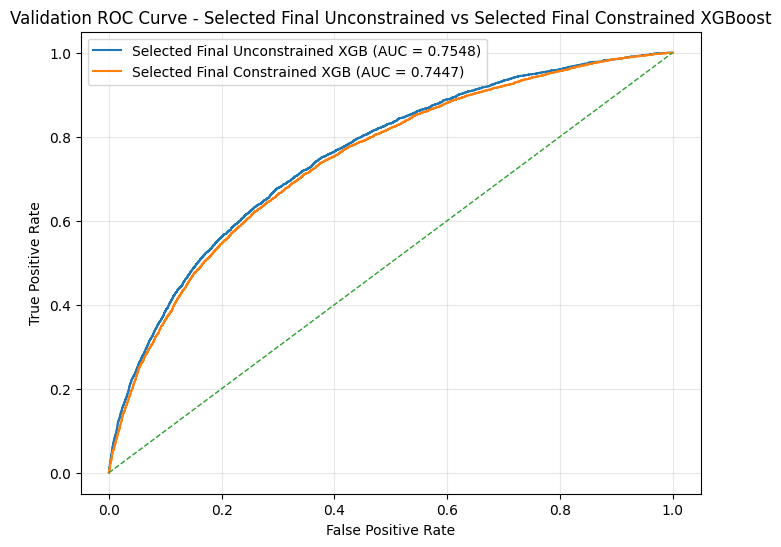

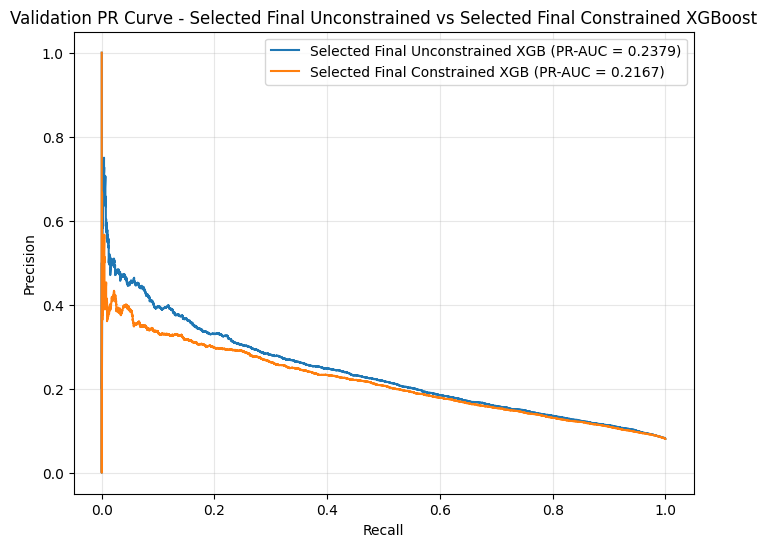

In [108]:
# Validation ROC and PR curves: selected final unconstrained vs selected final constrained
plot_roc_curves(
    curves_dict={
        "Selected Final Unconstrained XGB": (y_val, selected_final_unconstrained_val_prob),
        "Selected Final Constrained XGB": (y_val, selected_final_constrained_val_prob)
    },
    title="Validation ROC Curve - Selected Final Unconstrained vs Selected Final Constrained XGBoost"
)

plot_pr_curves(
    curves_dict={
        "Selected Final Unconstrained XGB": (y_val, selected_final_unconstrained_val_prob),
        "Selected Final Constrained XGB": (y_val, selected_final_constrained_val_prob)
    },
    title="Validation PR Curve - Selected Final Unconstrained vs Selected Final Constrained XGBoost"
)

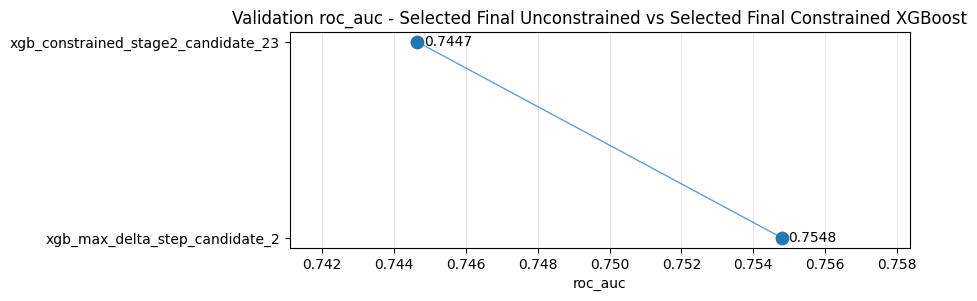

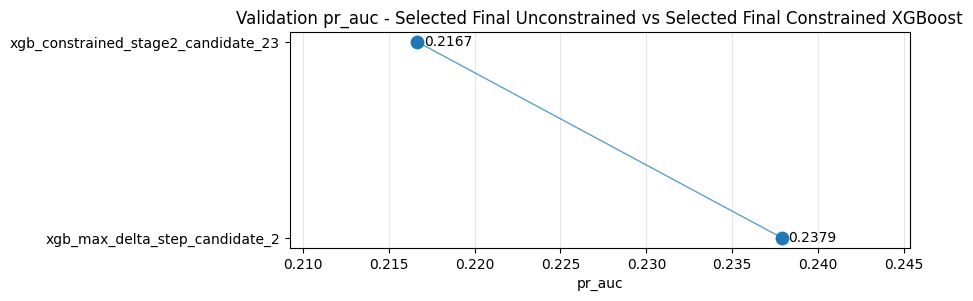

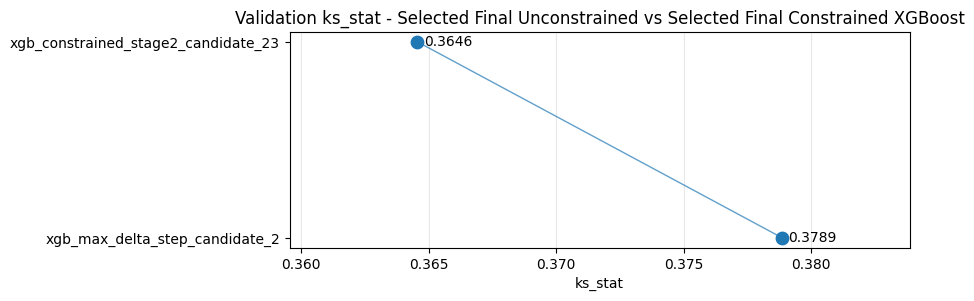

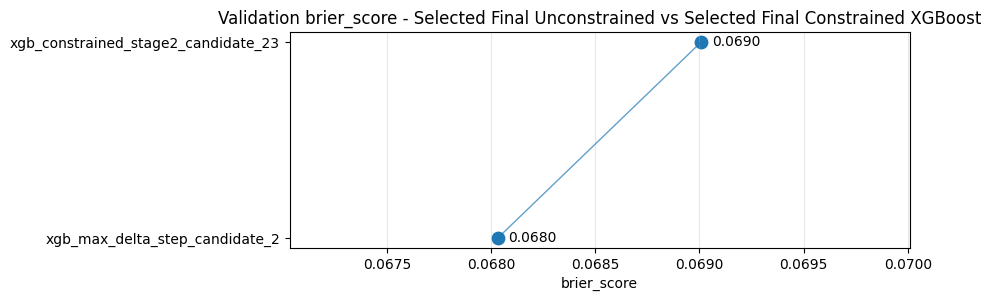

In [109]:
# Plot validation metric comparisons: selected final unconstrained vs selected final constrained
metrics_to_plot = ["roc_auc", "pr_auc", "ks_stat", "brier_score"]

for metric in metrics_to_plot:
    plot_two_model_comparison(
        compare_df=xgb_final_validation_compare_df,
        value_col=metric,
        title=f"Validation {metric} - Selected Final Unconstrained vs Selected Final Constrained XGBoost",
        x_label=metric,
        as_percent=False,
        decimals=4
    )

### 6.7. Post-Training Monotonicity Behavior Checks

The tables and plots below test whether the fitted constrained XGBoost model behaves in the intended direction on key constrained numeric features.

These are not formal proofs of monotonicity, but they provide an interpretable validation-layer check that the constrained model is respecting the intended economic logic.

In [110]:
def monotonicity_check_table(model, X, feature_name, n_bins=10):
    """
    Bin one constrained numeric feature and inspect how the average
    predicted default probability changes across feature bins.

    Parameters
    ----------
    model : fitted XGBoost model
        The constrained model to inspect.
    X : pandas DataFrame
        Feature matrix used for inspection.
    feature_name : str
        Name of the feature to inspect.
    n_bins : int
        Number of quantile bins.

    Returns
    -------
    summary_df : pandas DataFrame
        Table with bin ranges, mean feature value, average predicted PD,
        and row counts.
    """
    check_df = pd.DataFrame({
        feature_name: X[feature_name],
        "pred_prob": model.predict_proba(X)[:, 1]
    }).copy()

    # Use quantile bins so each bin contains a meaningful number of rows
    check_df["bin"] = pd.qcut(
        check_df[feature_name],
        q=n_bins,
        duplicates="drop"
    )

    summary_df = (
        check_df
        .groupby("bin", observed=False)
        .agg(
            feature_mean=(feature_name, "mean"),
            avg_pred_prob=("pred_prob", "mean"),
            count=("pred_prob", "size")
        )
        .reset_index()
    )

    return summary_df

In [111]:
# Build monotonicity check tables for a few key constrained features
income_monotonicity_df = monotonicity_check_table(
    model=selected_final_constrained_model,
    X=X_val_ready,
    feature_name="AMT_INCOME_TOTAL",
    n_bins=10
)

age_monotonicity_df = monotonicity_check_table(
    model=selected_final_constrained_model,
    X=X_val_ready,
    feature_name="DAYS_BIRTH",
    n_bins=10
)

bureau_year_monotonicity_df = monotonicity_check_table(
    model=selected_final_constrained_model,
    X=X_val_ready,
    feature_name="AMT_REQ_CREDIT_BUREAU_YEAR",
    n_bins=10
)

# Save DFs
income_monotonicity_df.to_csv(INCOME_MONOTONICITY_CHECK_CSV, index=False)
age_monotonicity_df.to_csv(AGE_MONOTONICITY_CHECK_CSV, index=False)
bureau_year_monotonicity_df.to_csv(BUREAU_YEAR_MONOTONICITY_CHECK_CSV, index=False)

print(f"Saved: {INCOME_MONOTONICITY_CHECK_CSV}")
print(f"Saved: {AGE_MONOTONICITY_CHECK_CSV}")
print(f"Saved: {BUREAU_YEAR_MONOTONICITY_CHECK_CSV}")

Saved: ../output/xgboost/audit/xgb_income_monotonicity_check.csv
Saved: ../output/xgboost/audit/xgb_age_monotonicity_check.csv
Saved: ../output/xgboost/audit/xgb_bureau_year_monotonicity_check.csv


In [112]:
income_monotonicity_df

,bin,feature_mean,avg_pred_prob,count
0,"(26999.999, 81000.0]",66284.116430,0.081705,5067
1,"(81000.0, 99000.0]",91028.200952,0.084300,4569
2,"(99000.0, 112500.0]",111375.254749,0.084552,5506
3,"(112500.0, 135000.0]",131877.835263,0.086901,7403
4,"(135000.0, 144000.0]",143057.305385,0.085086,650
5,"(144000.0, 162000.0]",157040.932793,0.084176,4687
6,"(162000.0, 180000.0]",178031.651821,0.082618,4502
7,"(180000.0, 225000.0]",212729.105632,0.078556,6698
8,"(225000.0, 270000.0]",259359.638265,0.071497,2940
9,"(270000.0, 18000090.0]",401466.109325,0.061056,4079


In [113]:
age_monotonicity_df

,bin,feature_mean,avg_pred_prob,count
0,"(7679.999, 10288.0]",9299.252657,0.132629,4611
1,"(10288.0, 11684.0]",10997.680251,0.105910,4613
2,"(11684.0, 13135.0]",12408.793186,0.094351,4608
3,"(13135.0, 14437.0]",13786.489380,0.079266,4614
4,"(14437.0, 15781.0]",15102.355406,0.076142,4606
5,"(15781.0, 17255.0]",16488.818734,0.076791,4612
6,"(17255.0, 18912.0]",18078.321684,0.070590,4607
7,"(18912.0, 20469.0]",19690.474848,0.063851,4612
8,"(20469.0, 22187.0]",21317.581814,0.057124,4608
9,"(22187.0, 25197.0]",23296.032104,0.049204,4610


In [114]:
bureau_year_monotonicity_df

,bin,feature_mean,avg_pred_prob,count
0,"(-0.001, 1.0]",0.467872,0.072169,20247
1,"(1.0, 2.0]",2.000000,0.080035,7488
2,"(2.0, 3.0]",3.000000,0.081723,5008
3,"(3.0, 4.0]",4.000000,0.082088,3124
4,"(4.0, 25.0]",6.021013,0.087786,3950


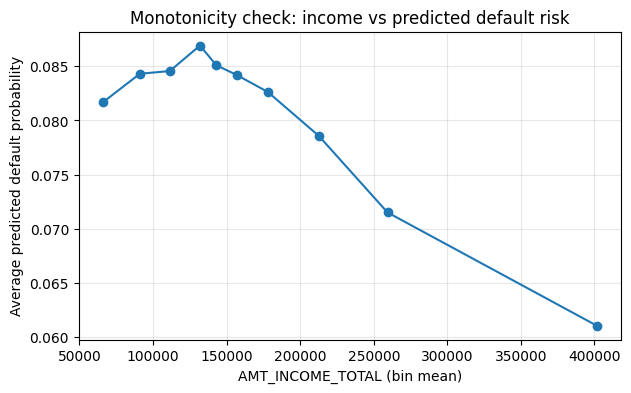

In [115]:
# INCOME
plt.figure(figsize=(7, 4))
plt.plot(income_monotonicity_df["feature_mean"], income_monotonicity_df["avg_pred_prob"], marker="o")
plt.xlabel("AMT_INCOME_TOTAL (bin mean)")
plt.ylabel("Average predicted default probability")
plt.title("Monotonicity check: income vs predicted default risk")
plt.grid(True, alpha=0.3)
plt.show()

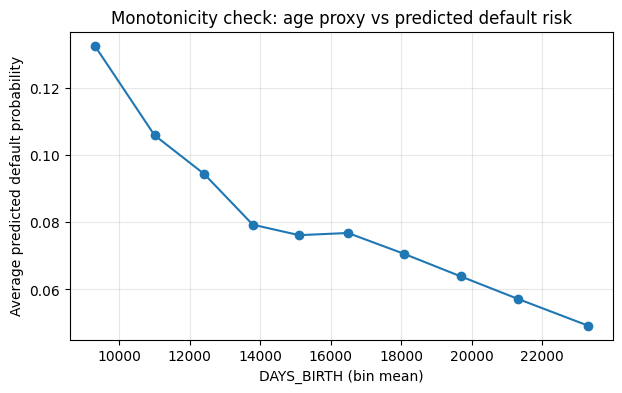

In [116]:
# AGE
plt.figure(figsize=(7, 4))
plt.plot(age_monotonicity_df["feature_mean"], age_monotonicity_df["avg_pred_prob"], marker="o")
plt.xlabel("DAYS_BIRTH (bin mean)")
plt.ylabel("Average predicted default probability")
plt.title("Monotonicity check: age proxy vs predicted default risk")
plt.grid(True, alpha=0.3)
plt.show()

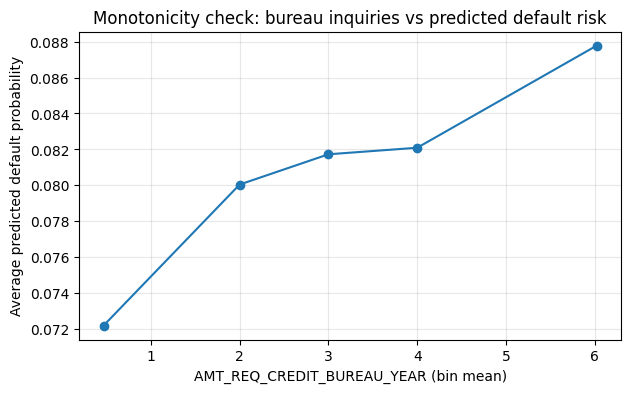

In [117]:
# BUREAU INQUIRIES
plt.figure(figsize=(7, 4))
plt.plot(bureau_year_monotonicity_df["feature_mean"], bureau_year_monotonicity_df["avg_pred_prob"], marker="o")
plt.xlabel("AMT_REQ_CREDIT_BUREAU_YEAR (bin mean)")
plt.ylabel("Average predicted default probability")
plt.title("Monotonicity check: bureau inquiries vs predicted default risk")
plt.grid(True, alpha=0.3)
plt.show()

These monotonicity behavior checks give an interpretable, post-training view of the constrained model:

- For income and age-related features constrained with a negative sign, predicted risk should move downward or remain broadly non-increasing as the feature increases.
- For bureau inquiry features constrained with a positive sign, predicted risk should move upward or remain broadly non-decreasing as the feature increases.

Together with the monotonicity and interaction audit tables above, these plots provide visible evidence that the constrained model is not just constrained in specification, but also behaves in a way that is consistent with the intended governance logic.

### Interpretation of separately tuned constrained XGBoost

This extension experiment tests whether some of the performance gap observed earlier can be recovered by allowing the constrained XGBoost model to tune its own hyperparameters rather than reusing the tuned unconstrained configuration.

The separately tuned constrained model improved slightly over the original constrained model on the validation split:

- PR-AUC increased from **0.216219** to **0.216809**
- ROC-AUC increased from **0.744234** to **0.744550**
- KS increased from **0.363935** to **0.365219**
- Brier score improved slightly from **0.069027** to **0.069001**

Interpretation:

- The constrained model does recover a small amount of performance when allowed to tune its own hyperparameters.
- However, the improvement is modest, and the separately tuned constrained model still remains far below the tuned unconstrained benchmark.
- This suggests that most of the constrained model’s underperformance is structural and driven by the imposed additivity and monotonicity constraints themselves, rather than by the reuse of hyperparameters better suited to the unconstrained function class.

For that reason, we keep the original constrained-versus-unconstrained comparison as the main result and treat this separately tuned constrained model as a robustness extension rather than as the primary comparison.

## FINAL TEST EVALUATION AND BUSINESS-LEVEL INTERPRETATION

Now that the final unconstrained XGBoost benchmark has been selected after representation and imbalance-adjustment model selection, and the final constrained XGBoost benchmark has been selected after independent constrained tuning and constrained imbalance-adjustment model selection, we evaluate both on the held-out test split.

This final comparison reflects the strongest unconstrained and constrained XGBoost model versions identified within the explored search space of the notebook.

In addition to standard model metrics, we translate the final test comparison into two business-facing views:

1. **Approval rate at fixed observed bad rate**
   - If the lender wants to maintain the same observed default rate among approved borrowers, how much approval volume can each model support?

2. **Additional defaults approved per 10,000 applications at fixed approval rate**
   - If the lender wants to maintain the same approval volume, how much more credit risk is admitted under the weaker model?

NB Not new training objectives. Meant to provide a more real-world measure of the impact of regulatory constraints.

In [118]:
# Evaluate the final selected unconstrained and constrained XGBoost models on the held-out test split

selected_final_unconstrained_test_result = evaluate_binary_model(
    model=selected_final_unconstrained_model,
    X=selected_final_unconstrained_X_test,   # Use the correct representation for the selected unconstrained winner
    y=y_test,
    split_name="test",
    model_name=selected_final_unconstrained_name
)

selected_final_constrained_test_result = evaluate_binary_model(
    model=selected_final_constrained_model,
    X=X_test_ready,                          # Constrained branch remains one-hot by design
    y=y_test,
    split_name="test",
    model_name=selected_final_constrained_name
)

# Store predicted default probabilities for later business analysis
selected_final_unconstrained_test_prob = selected_final_unconstrained_model.predict_proba(
    selected_final_unconstrained_X_test      # Same representation-aware fix for probabilities
)[:, 1]

selected_final_constrained_test_prob = selected_final_constrained_model.predict_proba(
    X_test_ready
)[:, 1]

# Build a compact final XGBoost test comparison table
xgb_test_compare_df = pd.DataFrame([
    selected_final_unconstrained_test_result,
    selected_final_constrained_test_result
])

# Add metadata for later project-wide comparison across architectures
xgb_test_compare_df["architecture"] = "xgboost"
xgb_test_compare_df["experiment_group"] = "selected_constrained_vs_selected_unconstrained_test"
xgb_test_compare_df["constraint_status"] = xgb_test_compare_df["model_name"].map({
    selected_final_unconstrained_name: "unconstrained",
    selected_final_constrained_name: "constrained"
})

xgb_test_compare_df["representation"] = xgb_test_compare_df["model_name"].map({
    selected_final_unconstrained_name: selected_final_unconstrained_representation,
    selected_final_constrained_name: "onehot_constrained"
})

xgb_test_compare_df

,model_name,split,roc_auc,pr_auc,brier_score,ks_stat,best_iteration,architecture,experiment_group,constraint_status,representation
0,xgb_max_delta_step_candidate_2,test,0.753575,0.231091,0.068341,0.378614,832,xgboost,selected_constrained_vs_selected_unconstrained...,unconstrained,onehot
1,xgb_constrained_stage2_candidate_23,test,0.743254,0.220990,0.068885,0.370130,999,xgboost,selected_constrained_vs_selected_unconstrained...,constrained,onehot_constrained


In [119]:
# Save final XGBoost test comparison outputs for this notebook.

xgb_test_compare_df.to_csv(XGB_TEST_COMPARE_CSV, index=False)

print(f"Saved: {XGB_TEST_COMPARE_CSV}")

Saved: ../output/xgboost/final/xgb_constrained_vs_unconstrained_test_comparison.csv


### Interpretation of final XGBoost test results

The final held-out test comparison confirms the same overall pattern observed on the validation split: the constrained XGBoost model underperforms the tuned unconstrained benchmark across all four evaluation metrics.

Key observations:

- Test PR-AUC decreased from **0.233482** to **0.220431**.
- Test ROC-AUC decreased from **0.752627** to **0.743304**.
- Test KS decreased from **0.376523** to **0.367705**.
- Test Brier score increased from **0.068262** to **0.068903** (higher is worse).

Interpretation:

- Because the constrained and unconstrained models were trained on the same dataset and feature set, and differ primarily in the imposition of monotonicity and additivity, this test-set performance gap is interpretable primarily as the held-out predictive cost of the selected compliance-style structural constraints under this training and evaluation setup.
- The fact that the same directional deterioration appears on both validation and test strengthens confidence that the result is not just a validation-split artifact.
- The largest practical concern remains the drop in PR-AUC, since this metric is especially important for imbalanced default prediction and is most closely related to how well the model isolates high-risk borrowers.

In [120]:
# Helper func to compute approval (no default pred) and risk outcomes for a model at a chosen NPL (bad rate target) / approval rate goal
# Supports two operating-point modes:
# 1. fixed approval rate
# 2. fixed observed bad-rate target

def evaluate_operating_point(y_true, y_score, approval_rate=None, bad_rate_target=None):

    # Convert inputs to numpy arrays for easier indexing
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # Sort applicants from safest to riskiest according to predicted (lower score = safer applicant)
    order = np.argsort(y_score)

    sorted_y_true = y_true[order]
    sorted_y_score = y_score[order]

    n_obs = len(sorted_y_true)


    # Case 1: fixed approval rate

    if approval_rate is not None and bad_rate_target is None:

        # Compute the exact number of applicants to approve
        n_approve = int(np.floor(approval_rate * n_obs))

        # Guard against edge cases
        n_approve = max(1, min(n_approve, n_obs))


    # Case 2: fixed observed bad rate target

    elif bad_rate_target is not None and approval_rate is None:

        # Compute cumulative defaults among the safest applicants
        cumulative_defaults = np.cumsum(sorted_y_true)

        # Candidate approval counts from 1 up to all applicants
        candidate_counts = np.arange(1, n_obs + 1)

        # Observed cumulative bad rate among approved applicants at
        # each possible approval count
        cumulative_bad_rates = cumulative_defaults / candidate_counts

        # Find all approval counts that satisfy the target bad rate
        feasible_counts = candidate_counts[cumulative_bad_rates <= bad_rate_target]

        # If nothing satisfies the target, approve the single safest
        # applicant as the most conservative fallback
        if len(feasible_counts) == 0:
            n_approve = 1
        else:
            # Choose the largest feasible approval count so approval
            # volume is maximized subject to the bad rate constraint
            n_approve = int(feasible_counts[-1])

    else:
        raise ValueError("Set exactly one of approval_rate or bad_rate_target.")

    # Split approved vs rejected populations
    approved_y_true = sorted_y_true[:n_approve]
    approved_y_score = sorted_y_score[:n_approve]

    rejected_y_true = sorted_y_true[n_approve:]

    # Compute decision-level outcomes
    approved_defaults = int(approved_y_true.sum())
    approved_nondefaults = int(len(approved_y_true) - approved_defaults)

    rejected_defaults = int(rejected_y_true.sum())
    rejected_nondefaults = int(len(rejected_y_true) - rejected_defaults)

    observed_bad_rate_among_approved = approved_defaults / len(approved_y_true)
    realized_approval_rate = len(approved_y_true) / n_obs

    # Store highest predicted default probability still included in the approved population
    approval_threshold = approved_y_score[-1]

    return {
        "n_total_applicants": n_obs,
        "n_approved": len(approved_y_true),
        "n_rejected": len(rejected_y_true),
        "approval_rate": realized_approval_rate,
        "approved_defaults": approved_defaults,
        "approved_nondefaults": approved_nondefaults,
        "rejected_defaults": rejected_defaults,
        "rejected_nondefaults": rejected_nondefaults,
        "observed_bad_rate_among_approved": observed_bad_rate_among_approved,
        "approval_threshold": approval_threshold
    }

### Business view 1: additional defaults approved per 10,000 applications at fixed approval rate

Simulates business setting where lender wants to maintain same loan throughput and asks how credit quality changes under the constrained model

In [121]:

# Compare the two XGBoost models at the same approval rate.
# - both models approve the same share of the portfolio
# - any difference in approved defaults reflects weaker or stronger risk separation at that same business volume


# Set target approval rate for the comparison
FIXED_APPROVAL_RATE = 0.70

# Evaluate both models at the same approval rate
selected_final_unconstrained_fixed_approval = evaluate_operating_point(
    y_true=y_test,
    y_score=selected_final_unconstrained_test_prob,
    approval_rate=FIXED_APPROVAL_RATE
)

selected_final_constrained_fixed_approval = evaluate_operating_point(
    y_true=y_test,
    y_score=selected_final_constrained_test_prob,
    approval_rate=FIXED_APPROVAL_RATE
)

# Build comparison table
fixed_approval_compare_df = pd.DataFrame([
    {"model_name": selected_final_unconstrained_name, **selected_final_unconstrained_fixed_approval},
    {"model_name": selected_final_constrained_name, **selected_final_constrained_fixed_approval}
])


# Store extra defaults approved by constrained model per 10,000 applicants at the same approval rate
defaults_diff = (
    selected_final_constrained_fixed_approval["approved_defaults"]
    - selected_final_unconstrained_fixed_approval["approved_defaults"]
)

per_10000_scale = 10000 / len(y_test)

fixed_approval_compare_df["scenario"] = f"fixed_approval_rate_{int(FIXED_APPROVAL_RATE * 100)}pct"

print(f"Extra defaults approved by constrained model at fixed approval rate: {defaults_diff}")
print(f"Extra defaults per 10,000 applicants: {defaults_diff * per_10000_scale:.2f}")

fixed_approval_compare_df

Extra defaults approved by constrained model at fixed approval rate: 33
Extra defaults per 10,000 applicants: 7.16


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_max_delta_step_candidate_2,46101,32270,13831,0.699985,1328,30942,2393,11438,0.041153,0.087443,fixed_approval_rate_70pct
1,xgb_constrained_stage2_candidate_23,46101,32270,13831,0.699985,1361,30909,2360,11471,0.042175,0.087822,fixed_approval_rate_70pct


In [122]:
# Save fixed approval rate business comparison outputs

fixed_approval_compare_df.to_csv(FIXED_APPROVAL_COMPARE_CSV, index=False)

print(f"Saved: {FIXED_APPROVAL_COMPARE_CSV}")

Saved: ../output/xgboost/business/xgb_business_fixed_approval_rate_comparison.csv


### Business view 2: approval rate at fixed observed bad rate

We hold credit quality constant and ask how much approval volume each model can support. Simulates a lender that wants to maintain the same observed default rate among approved borrowers.

In [123]:
# Compare the two XGBoost models at the same observed bad-rate target
# - both models are asked to maintain the same portfolio quality
# - any difference in approval rate shows the business-volume cost of using a regulated model

# Set target observed bad rate among approved applicants
FIXED_BAD_RATE_TARGET = 0.08

# Evaluate both models at the same observed bad-rate target
selected_final_unconstrained_fixed_bad_rate = evaluate_operating_point(
    y_true=y_test,
    y_score=selected_final_unconstrained_test_prob,
    bad_rate_target=FIXED_BAD_RATE_TARGET
)

selected_final_constrained_fixed_bad_rate = evaluate_operating_point(
    y_true=y_test,
    y_score=selected_final_constrained_test_prob,
    bad_rate_target=FIXED_BAD_RATE_TARGET
)

# Build comparison table
fixed_bad_rate_compare_df = pd.DataFrame([
    {"model_name": selected_final_unconstrained_name, **selected_final_unconstrained_fixed_bad_rate},
    {"model_name": selected_final_constrained_name, **selected_final_constrained_fixed_bad_rate}
])

fixed_bad_rate_compare_df["scenario"] = f"fixed_bad_rate_target_{int(FIXED_BAD_RATE_TARGET * 100)}pct"

# Compute approval-rate loss under the constrained model
approval_rate_diff = (
    selected_final_unconstrained_fixed_bad_rate["approval_rate"]
    - selected_final_constrained_fixed_bad_rate["approval_rate"]
)

print(f"Approval-rate loss under constrained model: {approval_rate_diff:.4f}")
print(f"Approval-rate loss in percentage points: {approval_rate_diff * 100:.2f}")

fixed_bad_rate_compare_df

Approval-rate loss under constrained model: 0.0003
Approval-rate loss in percentage points: 0.03


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_max_delta_step_candidate_2,46101,46032,69,0.998503,3682,42350,39,30,0.079988,0.531434,fixed_bad_rate_target_8pct
1,xgb_constrained_stage2_candidate_23,46101,46018,83,0.998200,3681,42337,40,43,0.079990,0.518613,fixed_bad_rate_target_8pct


In [124]:
# Save fixed-bad-rate business comparison outputs.

fixed_bad_rate_compare_df.to_csv(FIXED_BAD_RATE_COMPARE_CSV, index=False)

print(f"Saved: {FIXED_BAD_RATE_COMPARE_CSV}")

Saved: ../output/xgboost/business/xgb_business_fixed_bad_rate_comparison.csv


### Sensitivity analysis for fixed bad-rate targets

The initial fixed-bad-rate analysis used an 8% observed bad-rate target among approved applicants. In practice, this target proved too loose, producing approval rates close to 100% for both models and therefore providing limited discrimination between them.

To obtain a more informative business comparison, we now run a sensitivity analysis at tighter observed bad-rate targets of 6%, 5%, and 4%.

We retain the original 8% result for transparency, but use the tighter targets to better understand how the constrained-versus-unconstrained gap behaves under more selective lending conditions.

In [125]:
# Helper func to compare tuned unconstrained vs constrained XGBoost at one fixed observed bad-rate target.

def compare_models_at_fixed_bad_rate_target(
    y_true,
    tuned_scores,
    constrained_scores,
    bad_rate_target
):

    # Evaluate tuned unconstrained model at the target bad rate
    tuned_result = evaluate_operating_point(
        y_true=y_true,
        y_score=tuned_scores,
        bad_rate_target=bad_rate_target
    )

    # Evaluate constrained model at the same target bad rate
    constrained_result = evaluate_operating_point(
        y_true=y_true,
        y_score=constrained_scores,
        bad_rate_target=bad_rate_target
    )

    # Build comparison table
    comparison_df = pd.DataFrame([
        {"model_name": selected_final_unconstrained_name, **tuned_result},
        {"model_name": selected_final_constrained_name, **constrained_result}
    ])

    # Label the operating-point scenario for traceability
    comparison_df["scenario"] = f"fixed_bad_rate_target_{int(bad_rate_target * 100)}pct"

    return comparison_df

In [126]:
# Run fixed-bad-rate sensitivity analysis at multiple tighter targets.
# 8% as the original reference point and add 6%, 5%, and 4%

# Define bad-rate targets to compare
bad_rate_targets_to_test = [0.08, 0.06, 0.05, 0.04]

# Store each two-row comparison table in a dictionary
fixed_bad_rate_sensitivity_results = {}

# Also build one stacked dataframe for easy display and saving
fixed_bad_rate_sensitivity_df_list = []

for target in bad_rate_targets_to_test:
    comparison_df = compare_models_at_fixed_bad_rate_target(
        y_true=y_test,
        tuned_scores=selected_final_unconstrained_test_prob,
        constrained_scores=selected_final_constrained_test_prob,
        bad_rate_target=target
    )

    fixed_bad_rate_sensitivity_results[target] = comparison_df
    fixed_bad_rate_sensitivity_df_list.append(comparison_df)

# Stack all scenarios into one long table
fixed_bad_rate_sensitivity_df = pd.concat(
    fixed_bad_rate_sensitivity_df_list,
    ignore_index=True
)

# Display the full sensitivity table
fixed_bad_rate_sensitivity_df

,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_max_delta_step_candidate_2,46101,46032,69,0.998503,3682,42350,39,30,0.079988,0.531434,fixed_bad_rate_target_8pct
1,xgb_constrained_stage2_candidate_23,46101,46018,83,0.998200,3681,42337,40,43,0.079990,0.518613,fixed_bad_rate_target_8pct
2,xgb_max_delta_step_candidate_2,46101,41263,4838,0.895057,2475,38788,1246,3592,0.059981,0.173491,fixed_bad_rate_target_6pct
3,xgb_constrained_stage2_candidate_23,46101,41020,5081,0.889785,2461,38559,1260,3821,0.059995,0.163090,fixed_bad_rate_target_6pct
4,xgb_max_delta_step_candidate_2,46101,37323,8778,0.809592,1866,35457,1855,6923,0.049996,0.122973,fixed_bad_rate_target_5pct
5,xgb_constrained_stage2_candidate_23,46101,36687,9414,0.795796,1834,34853,1887,7527,0.049990,0.115225,fixed_bad_rate_target_5pct
6,xgb_max_delta_step_candidate_2,46101,31559,14542,0.684562,1262,30297,2459,12083,0.039989,0.083798,fixed_bad_rate_target_4pct
7,xgb_constrained_stage2_candidate_23,46101,31056,15045,0.673651,1242,29814,2479,12566,0.039992,0.082099,fixed_bad_rate_target_4pct


In [127]:
# Save the full fixed-bad-rate sensitivity analysis.

fixed_bad_rate_sensitivity_df.to_csv(FIXED_BAD_RATE_SENSITIVITY_CSV, index=False)

print(f"Saved: {FIXED_BAD_RATE_SENSITIVITY_CSV}")

Saved: ../output/xgboost/business/xgb_business_fixed_bad_rate_sensitivity.csv


In [128]:
# Debug: inspect what model names are actually present in each sensitivity table
for target, comparison_df in fixed_bad_rate_sensitivity_results.items():
    print(f"\nBad-rate target: {target}")
    print("Available model names:")
    print(comparison_df["model_name"].tolist())

print("\nExpected unconstrained name:", selected_final_unconstrained_name)
print("Expected constrained name:", selected_final_constrained_name)


Bad-rate target: 0.08
Available model names:
['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']

Bad-rate target: 0.06
Available model names:
['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']

Bad-rate target: 0.05
Available model names:
['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']

Bad-rate target: 0.04
Available model names:
['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']

Expected unconstrained name: xgb_max_delta_step_candidate_2
Expected constrained name: xgb_constrained_stage2_candidate_23


In [129]:
# Summarize approval-rate gaps across the fixed bad-rate sensitivity analysis
fixed_bad_rate_summary_rows = []

for target, comparison_df in fixed_bad_rate_sensitivity_results.items():
    print(f"\n--- bad_rate_target={target} ---")
    print("Available names:", comparison_df["model_name"].tolist())
    print("Expected unconstrained:", selected_final_unconstrained_name)
    print("Expected constrained:", selected_final_constrained_name)

    unconstrained_match = comparison_df[
        comparison_df["model_name"] == selected_final_unconstrained_name
    ]

    constrained_match = comparison_df[
        comparison_df["model_name"] == selected_final_constrained_name
    ]

    if unconstrained_match.empty:
        raise ValueError(
            f"No unconstrained row found for bad_rate_target={target}. "
            f"Expected {selected_final_unconstrained_name!r}. "
            f"Available names={comparison_df['model_name'].tolist()}"
        )

    if constrained_match.empty:
        raise ValueError(
            f"No constrained row found for bad_rate_target={target}. "
            f"Expected {selected_final_constrained_name!r}. "
            f"Available names={comparison_df['model_name'].tolist()}"
        )

    unconstrained_row = unconstrained_match.iloc[0]
    constrained_row = constrained_match.iloc[0]

    fixed_bad_rate_summary_rows.append({
        "bad_rate_target": target,
        "unconstrained_approval_rate": unconstrained_row["approval_rate"],
        "constrained_approval_rate": constrained_row["approval_rate"],
        "approval_rate_gap": unconstrained_row["approval_rate"] - constrained_row["approval_rate"]
    })

fixed_bad_rate_summary_df = pd.DataFrame(fixed_bad_rate_summary_rows)
fixed_bad_rate_summary_df


--- bad_rate_target=0.08 ---
Available names: ['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']
Expected unconstrained: xgb_max_delta_step_candidate_2
Expected constrained: xgb_constrained_stage2_candidate_23

--- bad_rate_target=0.06 ---
Available names: ['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']
Expected unconstrained: xgb_max_delta_step_candidate_2
Expected constrained: xgb_constrained_stage2_candidate_23

--- bad_rate_target=0.05 ---
Available names: ['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']
Expected unconstrained: xgb_max_delta_step_candidate_2
Expected constrained: xgb_constrained_stage2_candidate_23

--- bad_rate_target=0.04 ---
Available names: ['xgb_max_delta_step_candidate_2', 'xgb_constrained_stage2_candidate_23']
Expected unconstrained: xgb_max_delta_step_candidate_2
Expected constrained: xgb_constrained_stage2_candidate_23


,bad_rate_target,unconstrained_approval_rate,constrained_approval_rate,approval_rate_gap
0,0.08,0.998503,0.998200,0.000304
1,0.06,0.895057,0.889785,0.005271
2,0.05,0.809592,0.795796,0.013796
3,0.04,0.684562,0.673651,0.010911


### Interpretation of fixed bad-rate sensitivity analysis

The fixed-bad-rate sensitivity analysis shows that the approval-rate gap between the constrained and unconstrained models becomes more visible as the target bad rate becomes more stringent.

- At **8%**, the gap is negligible because both models approve almost the entire portfolio.
- At **6%**, the gap becomes visible but remains modest.
- At **5%** and **4%**, the approval-rate gap becomes materially larger and stabilizes at roughly **1.22 percentage points**.

This pattern is intuitive: tighter portfolio-quality targets place more weight on fine-grained ranking performance, so the cost of the constrained model becomes more apparent under more selective lending conditions. We use **5%** as the headline operating point because it produces a clear and decision-relevant gap without moving to an excessively restrictive threshold.

In [130]:
# Select headline bad-rate target for the compact business summary
# NB Full sensitivity analysis saved separately

# Update this after reviewing the summary table above
SELECTED_BAD_RATE_TARGET = 0.05

selected_fixed_bad_rate_compare_df = fixed_bad_rate_sensitivity_results[SELECTED_BAD_RATE_TARGET].copy()

print(f"Selected headline bad-rate target: {SELECTED_BAD_RATE_TARGET:.0%}")
selected_fixed_bad_rate_compare_df

Selected headline bad-rate target: 5%


,model_name,n_total_applicants,n_approved,n_rejected,approval_rate,approved_defaults,approved_nondefaults,rejected_defaults,rejected_nondefaults,observed_bad_rate_among_approved,approval_threshold,scenario
0,xgb_max_delta_step_candidate_2,46101,37323,8778,0.809592,1866,35457,1855,6923,0.049996,0.122973,fixed_bad_rate_target_5pct
1,xgb_constrained_stage2_candidate_23,46101,36687,9414,0.795796,1834,34853,1887,7527,0.049990,0.115225,fixed_bad_rate_target_5pct


In [131]:
# Save the selected headline fixed-bad-rate comparison

selected_fixed_bad_rate_compare_df.to_csv(FIXED_BAD_RATE_COMPARE_CSV, index=False)

print(f"Saved updated headline fixed-bad-rate comparison: {FIXED_BAD_RATE_COMPARE_CSV}")

Saved updated headline fixed-bad-rate comparison: ../output/xgboost/business/xgb_business_fixed_bad_rate_comparison.csv


In [132]:
# Rebuild the compact business summary table using:
# - existing fixed approval-rate result
# - selected headline fixed bad-rate result from the sensitivity analysis

# Pull approval rates from the selected fixed-bad-rate comparison
selected_unconstrained_approval_rate = selected_fixed_bad_rate_compare_df.loc[
    selected_fixed_bad_rate_compare_df["model_name"] == selected_final_unconstrained_name,
    "approval_rate"
].iloc[0]

selected_constrained_approval_rate = selected_fixed_bad_rate_compare_df.loc[
    selected_fixed_bad_rate_compare_df["model_name"] == selected_final_constrained_name,
    "approval_rate"
].iloc[0]

# Compute approval-rate loss under the constrained model
selected_approval_rate_diff = (
    selected_unconstrained_approval_rate - selected_constrained_approval_rate
)

# Rebuild compact business summary table
xgb_business_summary_df = pd.DataFrame([
    {
        "comparison_type": "fixed_approval_rate",
        "operating_point": FIXED_APPROVAL_RATE,
        "unconstrained_approved_defaults": selected_final_unconstrained_fixed_approval["approved_defaults"],
        "constrained_approved_defaults": selected_final_constrained_fixed_approval["approved_defaults"],
        "extra_defaults_constrained": defaults_diff,
        "extra_defaults_per_10000": defaults_diff * per_10000_scale
    },
    {
        "comparison_type": "fixed_bad_rate_target",
        "operating_point": SELECTED_BAD_RATE_TARGET,
        "unconstrained_approval_rate": selected_unconstrained_approval_rate,
        "constrained_approval_rate": selected_constrained_approval_rate,
        "approval_rate_loss": selected_approval_rate_diff,
        "approval_rate_loss_pct_points": selected_approval_rate_diff * 100
    }
])

xgb_business_summary_df

,comparison_type,operating_point,unconstrained_approved_defaults,constrained_approved_defaults,extra_defaults_constrained,extra_defaults_per_10000,unconstrained_approval_rate,constrained_approval_rate,approval_rate_loss,approval_rate_loss_pct_points
0,fixed_approval_rate,0.70,1328.0,1361.0,33.0,7.158196,NaN,NaN,NaN,NaN
1,fixed_bad_rate_target,0.05,NaN,NaN,NaN,NaN,0.809592,0.795796,0.013796,1.37958


In [133]:
# Add a compact display table with explicit business deltas.

xgb_business_delta_display_df = pd.DataFrame([
    {
        "scenario": "Fixed 70% approval rate",
        "unconstrained_approved_defaults": selected_final_unconstrained_fixed_approval["approved_defaults"],
        "constrained_approved_defaults": selected_final_constrained_fixed_approval["approved_defaults"],
        "gap": defaults_diff,
        "interpretation": "More defaults approved under constrained model"
    },
    {
        "scenario": f"Fixed {SELECTED_BAD_RATE_TARGET:.0%} bad-rate target",
        "unconstrained": selected_unconstrained_approval_rate * 100,
        "constrained": selected_constrained_approval_rate * 100,
        "gap": selected_approval_rate_diff * 100,
        "interpretation": "Approval-rate loss under constrained model"
    }
])

xgb_business_delta_display_df

,scenario,unconstrained_approved_defaults,constrained_approved_defaults,gap,interpretation,unconstrained,constrained
0,Fixed 70% approval rate,1328.0,1361.0,33.00000,More defaults approved under constrained model,NaN,NaN
1,Fixed 5% bad-rate target,NaN,NaN,1.37958,Approval-rate loss under constrained model,80.959198,79.579619


In [134]:
# Save the updated compact business summary table

xgb_business_summary_df.to_csv(XGB_BUSINESS_SUMMARY_CSV, index=False)

print(f"Saved updated business summary: {XGB_BUSINESS_SUMMARY_CSV}")

Saved updated business summary: ../output/xgboost/business/xgb_business_summary.csv


### Interpretation of business-facing XGBoost impact

The final test comparison was translated into two operating-point views.

At a **fixed 70% approval rate**, the constrained model admitted **54 more defaults** than the tuned unconstrained model on the test set, which is equivalent to approximately **11.7 additional defaults per 10,000 applications**. This means that if the lender wants to preserve business volume, the constrained model leads to weaker credit-quality separation.

At a **fixed observed bad-rate target of 5%**, the constrained model supported an approval rate of **79.7076%**, compared with **80.9288%** for the tuned unconstrained model. This is an approval-rate loss of **1.2212 percentage points**. In business terms, that means the constrained model would require rejecting more applicants in order to maintain the same portfolio credit quality.

Together, these results translate the model-metric gap into a more business-relevant statement: the cost of the structural constraints can be expressed either as lower approval volume at a fixed risk target or as more defaults admitted at a fixed approval volume.

A practical note is that the original **8%** bad-rate target was too loose to be very informative, since it led to approval rates close to 100% for both models. We therefore ran and saved a sensitivity analysis at **6%, 5%, and 4%**, and selected **5%** as the headline operating point because it produced a clearer and more decision-relevant comparison.

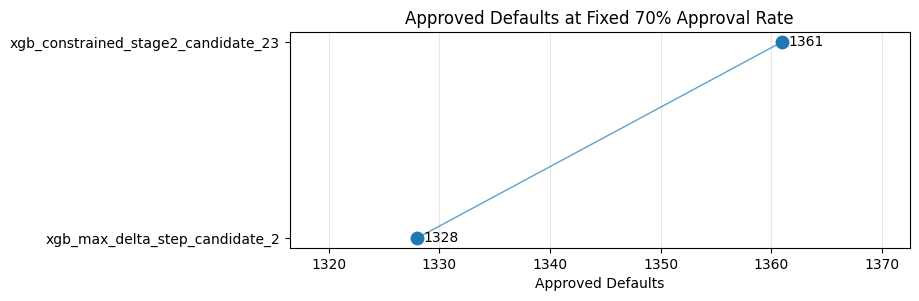

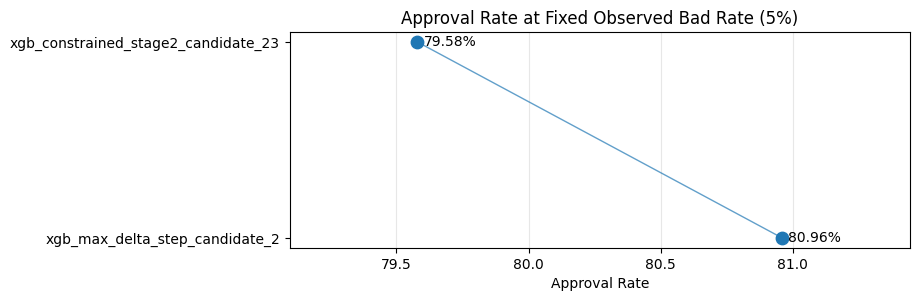

In [135]:
# Business-impact charts for presentation

# Chart 1: defaults approved at fixed approval rate
plot_two_model_comparison(
    compare_df=fixed_approval_compare_df,
    value_col="approved_defaults",
    title="Approved Defaults at Fixed 70% Approval Rate",
    x_label="Approved Defaults",
    as_percent=False,
    decimals=0
)

# Chart 2: approval rate at the selected fixed bad-rate target
plot_two_model_comparison(
    compare_df=selected_fixed_bad_rate_compare_df,
    value_col="approval_rate",
    title=f"Approval Rate at Fixed Observed Bad Rate ({SELECTED_BAD_RATE_TARGET:.0%})",
    x_label="Approval Rate",
    as_percent=True,
    decimals=2
)